# 🛒 Dự Báo Doanh Thu Cửa Hàng Rossmann

**Rossmann** là một trong những chuỗi bán lẻ dược mỹ phẩm lớn nhất tại châu Âu, sở hữu hơn 3.000 cửa hàng tại nhiều quốc gia. Với quy mô lớn và hoạt động liên tục, việc dự báo doanh thu hằng ngày của từng cửa hàng là vô cùng quan trọng nhằm tối ưu hóa nguồn lực, quản lý tồn kho, lập kế hoạch nhân sự và cải thiện hiệu quả kinh doanh.

Trong dự án này, nhóm sử dụng **Rossmann Store Sales** – một bộ dữ liệu nổi tiếng được công bố trên nền tảng Kaggle. Dataset cập nhật đến tháng 7 năm 2015 bao gồm thông tin lịch sử doanh thu theo ngày của 1.115 cửa hàng, cùng với các đặc trưng liên quan như loại cửa hàng, chương trình khuyến mãi, thông tin đối thủ cạnh tranh, ngày nghỉ lễ, và một số biến mô tả đặc điểm hoạt động của từng store.

### 🎯 Mục tiêu bài toán
Xây dựng mô hình **Machine Learning** dự báo doanh thu (**Sales**) cho mỗi cửa hàng trong tương lai, từ đó hỗ trợ Rossmann đưa ra các quyết định vận hành chính xác và hiệu quả hơn.

### 🔍 Phạm vi nghiên cứu
* **Hiểu dữ liệu**: Cấu trúc, ý nghĩa các biến.
* **Khám phá đặc trưng (EDA)**: Phân tích đơn biến, đa biến.
* **Phân tích sâu**: Tìm kiếm insight từ dữ liệu.
* **Mô hình hóa**: Xây dựng và so sánh các mô hình
* **Đánh giá**: Sử dụng các chỉ số phù hợp để đo lường hiệu quả.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
from cycler import cycler
import matplotlib.ticker as ticker

**Loading Data**
---


In [2]:
# Load the datasets
store = pd.read_csv("../data/store.csv")
train = pd.read_csv("../data/train.csv")

C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\1906948925.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


**Data Understanding**
---


> Chúng ta có 2 bộ dữ liệu chính là store.csv và test.csv, hãy cùng đi tìm hiểu dữ liệu trong từng bộ dữ liệu


### Đầu tiên là `store.csv`


In [3]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


1. Dữ liệu gồm 1115 dòng với 10 cột

2. Các numerical features bao gồm: `CompetitionDistance`, `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`, `Promo2`, `Promo2SinceWeek`,   `Promo2SinceYear`

3. Các features có kiểu object bao gồm: `StoreType`, `Assortment`, `PromoInterval`

### Kiểm tra missing value


In [5]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

1. Dữ liệu bị missing khá nhiều

2. Các biến liên quan đến đối thủ đều có missing value, tuy nhiên biến CompetitionDistance chỉ có 3 missing value có thể là do các cửa hàng đó thực sự không có cửa hàng đối thủ nào ở gần, còn các biến CompetitionOpenSinceMonth và CompetitionOpenSinceYear có cùng số missing value là 354 lý do có thể là vì không thu thập được thông tin của đối thủ nên để tiện cho phần phân tích sau chúng ta sẽ coi như các cửa hàng này không có đối thủ cạnh tranh hoặc đối thủ cạnh tranh ở quá xa

3. Các biến liên quan đến promo2 đều cùng có rất nhiều missing value là 544 trên tổng số 1115 dòng dữ liệu, trong khi biến promo2 thì không có missing value nào

### Kiểm tra duplicate data


In [6]:
store.duplicated().sum()

0

Không có dữ liệu trùng lặp


### Thống kê cơ bản về store


In [7]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


1. Không có giá trị âm trong bộ dữ liệu trong toàn bộ dữ liệu cho thấy dữ liệu khá logic

2. Biến CompetitionDistance có mean = 5404 gấp hơn 2 lần so với median = 2325, cho thấy dữ liệu bị lệch phải nặng và có biến động khá lớn khi std = 7663 lớn hơn mean

3. Biến Promo2 chỉ nhận giá trị 0 và 1

### Tiếp theo là `train.csv`


In [8]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


- Dữ liệu khá lớn gồm 1017209 dòng với 9 cột
- Các numerical features bao gồm: `Sales`, `Customers`, `Store`, `DayOfWeek`, `Open`, `Promo`, `SchoolHoliday`
- Các features có kiểu object bao gồm: `Date`, `StateHoliday`

### Kiểm tra missing value


In [10]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Dữ liệu khá sạch, không có missing value nào


### Kiểm tra duplicate data


In [11]:
train.duplicated().sum()

0

Dữ liệu không bị trùng lặp


### Thống kê cơ bản về train


In [12]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


1. Quan sát không thấy xuất hiện giá trị âm trong bộ dữ liệu

2. Trung bình 1 ngày mỗi cửa hàng có doanh thu khoảng 5773 dollars với 633 khách hàng

3. Có nhưng giá trị 0 ở biến `Sales` và `Customers`, điều này là hợp lý vì có thể có những ngày cửa hàng đóng cửa hoặc không có khách hàng nào đến mua sắm

4. Biến `Open` có mean = 0.83 nghĩa là các cửa hàng mở cửa khoảng 83% số ngày trong năm từ đó suy ra có khoảng 17% số ngày cửa hàng đóng cửa (tương ứng với Chủ nhật và các ngày lễ lớn).

5. Biến `Promo` có mean = 0.381. Điều này cho thấy chuỗi cửa hàng chạy các chương trình khuyến mãi ngắn hạn khá thường xuyên, chiếm khoảng 38% tổng số ngày kinh doanh.

6. Các biến `Sales` và `Customers` có độ lệch phải khá lớn khi mean > median, điều này cho thấy có một số ngày doanh số và lượng khách hàng rất cao so với các ngày còn lại, làm tăng giá trị trung bình của chúng.

7. Các biến `Open`, `Promo` và `SchoolHoliday` chỉ nhận giá trị 0 và 1

In [13]:
# Chuyển cột 'Date' sang kiểu datetime
train['Date'] = pd.to_datetime(train['Date'])

In [14]:
# Kiểm tra khoảng thời gian của dữ liệu train
print(f"Ngày bắt đầu: {train['Date'].min()}")
print(f"Ngày kết thúc: {train['Date'].max()}")
print(f"Khoảng thời gian: {(train['Date'].max() - train['Date'].min()).days+1} ngày")

Ngày bắt đầu: 2013-01-01 00:00:00
Ngày kết thúc: 2015-07-31 00:00:00
Khoảng thời gian: 942 ngày


_Dữ liệu kéo dài trong <b>942</b> ngày từ 2013-01-01 đến 2015-07-31 tức là hơn 2 năm rưỡi_


Tiếp theo chúng ta sẽ kiểm tra xem dữ liệu có bị lỗi trùng ngày hay thiếu ngày không

In [15]:
# Xem trong khoảng thời gian từ ngày đầu tiên đến ngày cuối cùng có bị thiếu ngày không
date_range = pd.date_range(start=train['Date'].min(), end=train['Date'].max())
missing_dates = date_range.difference(train['Date'])
print(f"Số ngày bị thiếu: {len(missing_dates)}")

Số ngày bị thiếu: 0


In [16]:
# Kiểm tra xem dữ liệu ngày của các cửa hàng có liên tục và đầy đủ không hay bị lặp lại
store_date_counts = train.groupby('Store')['Date'].nunique()
duplicate_store_dates = store_date_counts[store_date_counts < (train['Date'].max() - train['Date'].min()).days + 1]
print(f"Số cửa hàng có dữ liệu ngày không đầy đủ: {len(duplicate_store_dates)}")

Số cửa hàng có dữ liệu ngày không đầy đủ: 181


In [17]:
# Kiểm tra xem các cửa hàng có dữ liệu ngày bị thiếu đó trong khoảng thời gian nào
for store_id in duplicate_store_dates.index:
    store_dates = train[train['Store'] == store_id]['Date']
    missing_store_dates = date_range.difference(store_dates)
    if not missing_store_dates.empty:
        print(f"Cửa hàng {store_id} thiếu dữ liệu từ ngày {missing_store_dates.min().date()} đến ngày {missing_store_dates.max().date()}")
# Kiểm tra xem tất cả các cửa hàng có ngày bị thiếu có chung trong một khoảng thời gian cụ thể không
common_missing_dates = None
for store_id in duplicate_store_dates.index:
    store_dates = train[train['Store'] == store_id]['Date']
    missing_store_dates = date_range.difference(store_dates)
    if common_missing_dates is None:
        common_missing_dates = set(missing_store_dates)
    else:
        common_missing_dates = common_missing_dates.intersection(set(missing_store_dates))
if common_missing_dates:
    print(f"Tất cả các cửa hàng có dữ liệu ngày không đầy đủ đều thiếu các ngày: {common_missing_dates.tolist()}")
else:
    print("Không có cửa hàng nào có dữ liệu ngày không đầy đủ thiếu cùng một khoảng thời gian.")

Cửa hàng 13 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 20 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 22 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 32 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 36 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 41 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 46 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 51 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 52 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 58 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 72 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 76 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 81 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 89 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 99 thiếu dữ liệu từ ngày 2014-07-01 đến ngày 2014-12-31
Cửa hàng 100 thiếu dữ liệ

Quan sát output cho thấy có vẻ như có 1 số lượng khá lớn các cửa hàng mở cửa và đóng cửa trong cùng 1 khoảng thời gian nhưng lại trả về kết quả không phải toàn bộ cửa hàng đến thiếu dữ liệu trong cùng khoảng thời gian đó

=> Có thể có 1 số ít cửa hàng bị thiếu dữ liệu ngày khác so với phần lớn còn lại? Vậy cùng thử kiểm tra giả sử xem có cửa hàng nào bị thiếu dữ liệu vào ngày đầu tiên (2014-07-01) mà phần lớn các cửa hàng còn lại bị thiếu không

In [18]:
# Kiểm tra xem có bao nhiêu cửa hàng bị thiếu dữ liệu trong ngày 2014-07-01
missing_on_july_1 = []
for store_id in duplicate_store_dates.index:
    store_dates = train[train['Store'] == store_id]['Date']
    if pd.to_datetime('2014-07-01') not in store_dates.values:
        missing_on_july_1.append(store_id)
print(f"Tổng số cửa hàng bị thiếu dữ liệu trong ngày 2014-07-01: {len(missing_on_july_1)}")

Tổng số cửa hàng bị thiếu dữ liệu trong ngày 2014-07-01: 180


Aha! Vậy là có 180 trên 181 cửa hàng bị thiếu dữ liệu cùng thiếu dữ liệu vào ngày 2014-07-01, chỉ có 1 cửa hàng không bị thiếu dữ liệu vào ngày này.

Cùng đi tìm xem cừa hàng đó là cửa hàng nào

In [19]:
# Kiêm tra xem trong danh sách các cửa hàng bị thiếu dữ liệu thì cừa hàng cụ thể nào không bị thiếu dữ liệu vào ngay 2014-07-01
for store_id in duplicate_store_dates.index:
    store_dates = train[train['Store'] == store_id]['Date']
    if pd.to_datetime('2014-07-01') in store_dates.values:
        print(f"Cửa hàng {store_id} KHÔNG bị thiếu dữ liệu vào ngày 2014-07-01")



Cửa hàng 988 KHÔNG bị thiếu dữ liệu vào ngày 2014-07-01


In [20]:
# Kiểm tra các ngày bị thiếu của cửa hàng 988
store_988_dates = train[train['Store'] == 988]['Date']
missing_988_dates = date_range.difference(store_988_dates)
print(f"Cửa hàng 988 thiếu các ngày: {missing_988_dates.tolist()}")

Cửa hàng 988 thiếu các ngày: [Timestamp('2013-01-01 00:00:00')]


Vậy là chúng ta đã xác định được kẻ lạc loài trong bầy rồi, cửa hàng 988 chính là cửa hàng duy nhất có dữ liệu ngày bị thiếu các với toàn bộ cửa hàng còn lại và cửa hàng 988 này cũng chỉ thiếu dữ liệu duy nhất 1 ngày là ngày đầu tiên của tập dữ liệu (2013-01-01)

In [21]:
# Kiểm tra xem tất cả các cửa hàng có dữ liệu ngày bị thiếu có chung trong một khoảng thời gian cụ thể không
common_missing_dates = None
duplicate_store_dates_copy = duplicate_store_dates.copy()
# Loại bỏ cửa hàng 988 ra khỏi duplicate_store_dates_copy
duplicate_store_dates_copy = duplicate_store_dates_copy.drop(988, errors='ignore')

for store_id in duplicate_store_dates_copy.index:
    store_dates = train[train['Store'] == store_id]['Date']
    missing_store_dates = date_range.difference(store_dates)
    if common_missing_dates is None:
        common_missing_dates = set(missing_store_dates)
    else:
        common_missing_dates = common_missing_dates.intersection(set(missing_store_dates))

if common_missing_dates:
    # Sắp xếp các ngày thiếu để dễ đọc
    sorted_dates = sorted(list(common_missing_dates))
    print(f"Có {len(sorted_dates)} ngày mà tất cả {len(duplicate_store_dates_copy)} cửa hàng đều thiếu dữ liệu")
    print(f"Khoảng thời gian: từ {sorted_dates[0].date()} đến {sorted_dates[-1].date()}")
    print(f"Đây là khoảng thời gian liên tục: {(sorted_dates[-1] - sorted_dates[0]).days + 1 == len(sorted_dates)}")
else:
    print("Không có ngày nào mà tất cả các cửa hàng có dữ liệu thiếu đều chung.")

Có 184 ngày mà tất cả 180 cửa hàng đều thiếu dữ liệu
Khoảng thời gian: từ 2014-07-01 đến 2014-12-31
Đây là khoảng thời gian liên tục: True


In [22]:
# Kiểm tra xem có bao nhiêu cửa hàng nào mà dữ liệu date bị lặp lại nhiều lần không
dem1 = 0
for store_id in train['Store'].unique():
    store_dates = train[train['Store'] == store_id]['Date']
    if store_dates.duplicated().any():
        print(f"Cửa hàng {store_id} có dữ liệu ngày bị lặp lại.")
    else:
        dem1 += 1
print(f"Tổng số cửa hàng không có dữ liệu ngày bị lặp lại: {dem1}")

Tổng số cửa hàng không có dữ liệu ngày bị lặp lại: 1115


Vậy chúng ta có thể rút ra được 1 số kết luận như sau:
1. Có 181 cửa hàng dữ bị thiếu ngày trong tổng số 1115 cửa hàng
2. Trong đó có 180 cửa hàng bị thiếu dữ liệu trong cùng 1 khoảng thời gian tầm nửa năm từ 2014-07-01 đến 2014-12-31
3. Có 1 cửa hàng số 988 là bị thiếu 1 ngày duy nhất là ngày đầu tiên của dữ liệu 2013-01-01
4. Dữ liệu không có cửa hàng nào bị lặp lại ngày cả


Kiểm tra xem các cửa hàng bị thiếu dữ liệu ngày đó thuộc loại cửa hàng nào và assortment nào

In [23]:
# Phân loại các cửa hàng có dữ liệu ngày bị thiếu đó thuộc loại StoreType và Assortment nào
incomplete_store_info = store[store['Store'].isin(duplicate_store_dates.index)][['Store', 'StoreType', 'Assortment']]
storetype_counts = incomplete_store_info['StoreType'].value_counts()
assortment_counts = incomplete_store_info['Assortment'].value_counts()
print("Số lượng cửa hàng theo từng loại StoreType:", storetype_counts)
print("Số lượng cửa hàng theo từng loại Assortment:", assortment_counts)

Số lượng cửa hàng theo từng loại StoreType: StoreType
a    85
d    81
c    14
b     1
Name: count, dtype: int64
Số lượng cửa hàng theo từng loại Assortment: Assortment
a    116
c     64
b      1
Name: count, dtype: int64


In [24]:
total_storetype_counts = store['StoreType'].value_counts()
total_assortment_counts = store['Assortment'].value_counts()
print("Tổng số cửa hàng theo từng loại StoreType:", total_storetype_counts)
print("Tổng số cửa hàng theo từng loại Assortment:", total_assortment_counts)

Tổng số cửa hàng theo từng loại StoreType: StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64
Tổng số cửa hàng theo từng loại Assortment: Assortment
a    593
c    513
b      9
Name: count, dtype: int64


Có thể thấy các cửa hàng bị thiếu dữ liệu ngày được phân bố khá đều giữa các loại StoreType và Assortment so với tổng thể toàn bộ cửa hàng mà không có parttern đặc biệt nào cả điều này có thể do khi chia dữ liệu thành train và test thì các cửa hàng bị thiếu dữ liệu ngày đó được phân bổ ngẫu nhiên vào cả 2 tập dữ liệu 

**Explore Data Analysis (EDA)**
---


In [25]:
# 1. ĐỊNH NGHĨA BỘ MÀU (ROSSMANN PALETTE)
# ---------------------------------------------------------
# Định nghĩa danh sách màu theo thứ tự ưu tiên
ROSSMANN_COLORS = [
    "#1B9E77", # 0: Teal đậm (Cơ sở/Xu hướng chính)
    "#D95F02", # 1: Cam mạnh (Nhấn mạnh/Cạnh tranh)
    "#7570B3", # 2: Tím đậm (Bổ sung/Trung tính)
    "#E7298A"  # 3: Hồng đậm (Điểm nhấn/Khác biệt)
]

# Ánh xạ tên để dễ gọi khi cần dùng lẻ (tùy chọn)
COLOR_MAP = {
    'base': "#1B9E77",
    'highlight': "#D95F02",
    'neutral': "#7570B3",
    'accent': "#E7298A"
}

# ---------------------------------------------------------
# 2. THIẾT LẬP STYLE CHUNG (GLOBAL CONFIG)
# ---------------------------------------------------------
def set_project_style():
    """
    Thiết lập style mặc định cho toàn bộ dự án Rossmann:
    - Palette: 4 màu chuẩn.
    - Grid: Tắt.
    - Spines: Tắt trên và phải.
    """
    # Set palette cho Seaborn
    sns.set_palette(sns.color_palette(ROSSMANN_COLORS))

    # Cập nhật rcParams cho Matplotlib
    plt.rcParams.update({
        # Màu mặc định cho các đường vẽ (line plot)
        'axes.prop_cycle': cycler(color=ROSSMANN_COLORS),
        
        # Tắt lưới (Gridlines)
        'axes.grid': False,
        
        # Tắt viền (Spines) trên và phải
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': True,
        'axes.spines.bottom': True,
        
        # Font và kích thước (tùy chỉnh thêm nếu cần)
        'font.family': 'sans-serif',
        'figure.figsize': (10, 6)
    })

# Kích hoạt style ngay lập tức
set_project_style()

### <b>Phân tích đơn biến</b>


#### Bộ dữ liệu `train.csv`


In [26]:
# Create a copy of the train dataframe for further analysis
df_train = train.copy()


In [27]:
# Xử lí sơ bộ dữ liệu train.csv để phục vụ cho việc phân tích
# Bước 1: Chuyển hết về chuỗi (string) để trộn '0' và 0 lại với nhau
df_train['StateHoliday'] = df_train['StateHoliday'].astype(str)
# Bước 2: Chuyển sang Category
df_train['StateHoliday'] = df_train['StateHoliday'].astype('category')
# 

In [28]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  category      
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(7)
memory usage: 63.1 MB


In [29]:
df_train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


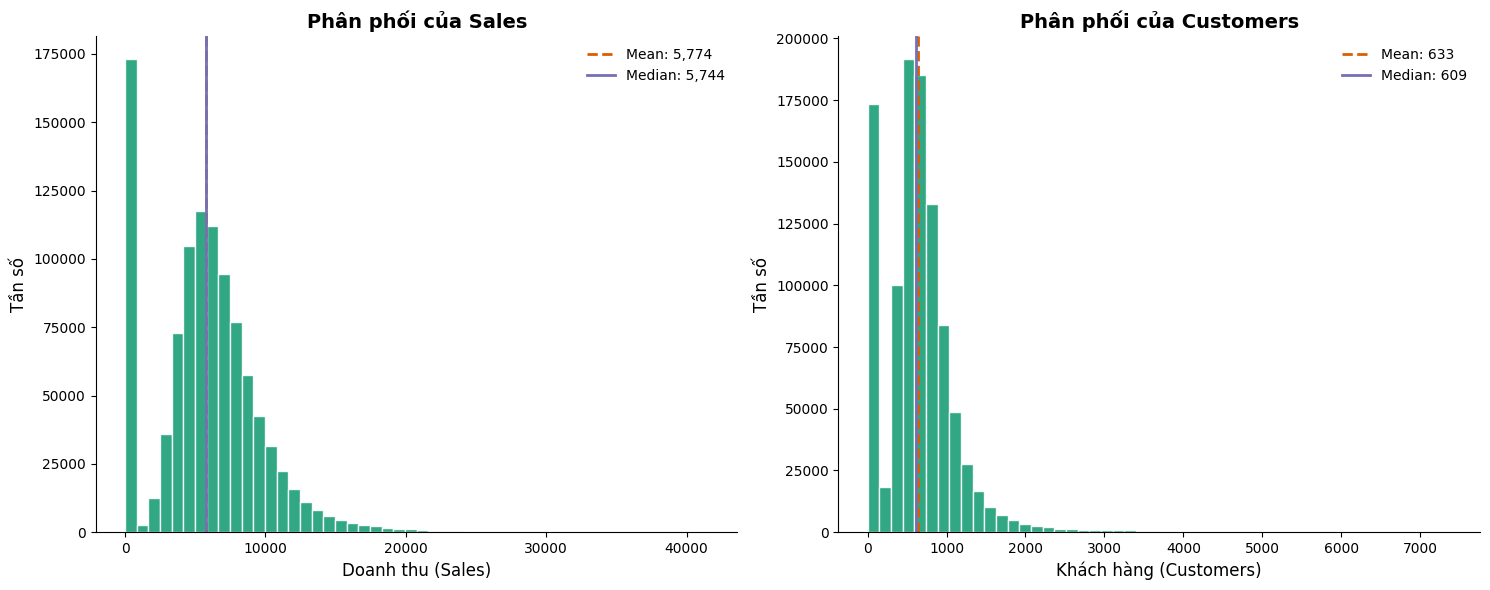

In [30]:
# Vẽ biểu đồ phân phối cho Sales và Customers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- BIỂU ĐỒ 1: SALES ---
ax = axes[0]

# 1. Vẽ Histogram: Dùng màu Base (#1B9E77)
# edgecolor='white' tạo khoảng hở hiện đại giữa các bar
ax.hist(df_train['Sales'], bins=50, 
        color=ROSSMANN_COLORS[0], edgecolor='white', alpha=0.9)

# 2. Thống kê
mean_sales = df_train['Sales'].mean()
median_sales = df_train['Sales'].median()

# Mean: Màu Cam (#D95F02) để nhấn mạnh
ax.axvline(mean_sales, color=ROSSMANN_COLORS[1], linestyle='--', linewidth=2, 
           label=f'Mean: {mean_sales:,.0f}')

# Median: Màu Tím (#7570B3) để bổ trợ/so sánh
ax.axvline(median_sales, color=ROSSMANN_COLORS[2], linestyle='-', linewidth=2, 
           label=f'Median: {median_sales:,.0f}')

# Title & Labels
ax.set_title('Phân phối của Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Doanh thu (Sales)', fontsize=12)
ax.set_ylabel('Tần số', fontsize=12)


# --- BIỂU ĐỒ 2: CUSTOMERS ---
ax = axes[1]

# 1. Vẽ Histogram: Dùng màu Base (#1B9E77)
ax.hist(df_train['Customers'], bins=50, 
        color=ROSSMANN_COLORS[0], edgecolor='white', alpha=0.9)

# 2. Thống kê
mean_customers = df_train['Customers'].mean()
median_customers = df_train['Customers'].median()

# Mean: Màu Cam
ax.axvline(mean_customers, color=ROSSMANN_COLORS[1], linestyle='--', linewidth=2, 
           label=f'Mean: {mean_customers:,.0f}')

# Median: Màu Tím
ax.axvline(median_customers, color=ROSSMANN_COLORS[2], linestyle='-', linewidth=2, 
           label=f'Median: {median_customers:,.0f}')

# Title & Labels
ax.set_title('Phân phối của Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('Khách hàng (Customers)', fontsize=12)
ax.set_ylabel('Tần số', fontsize=12)


# --- FORMATTING CHUNG ---
# (Global Config đã xử lý phần lớn, chỉ cần tinh chỉnh Legend và Spines cụ thể nếu cần)
for ax in axes:
    # Legend đơn giản, bỏ khung
    ax.legend(frameon=False)
    
    # Đảm bảo tắt Grid và Spines theo quy tắc (dù global đã set nhưng safety check)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Giữ trục trái và dưới hiện rõ
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()

In [31]:
df_train[df_train['Sales']==0].shape[0]

172871

In [32]:
df_train[df_train['Customers']==0].shape[0]

172869

In [33]:
df_train[df_train['Open']==0].shape[0]

172817

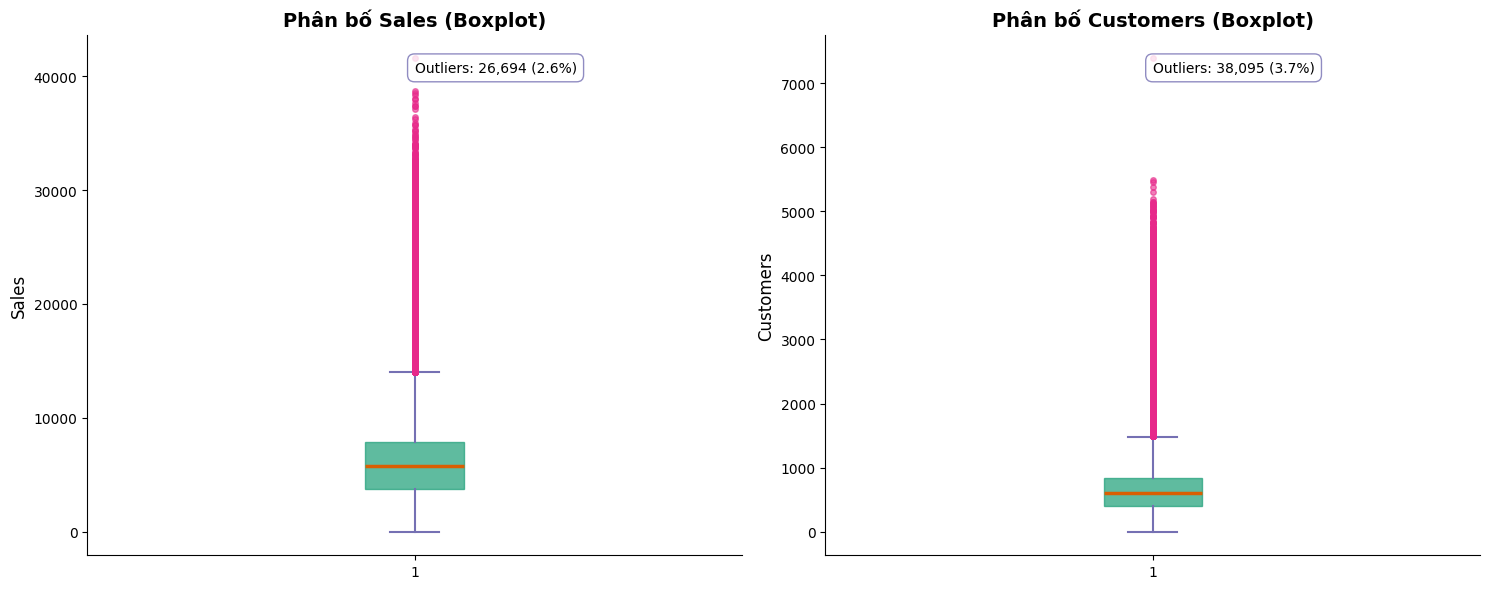

In [34]:
# Boxplot cho Sales và Customers
numerical_cols_train_boxplot = ['Sales', 'Customers']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, col in enumerate(numerical_cols_train_boxplot):
    # Lọc dữ liệu
    data = df_train[col]
    
    # --- VẼ BOXPLOT ---
    # Sử dụng dict để map màu theo Design System
    box = axes[idx].boxplot(
        data, 
        vert=True, 
        patch_artist=True,
        # Box body: Màu Base (Teal)
        boxprops=dict(facecolor=ROSSMANN_COLORS[0], color=ROSSMANN_COLORS[0], alpha=0.7),
        # Median: Màu Highlight (Cam) để nổi bật trên nền xanh
        medianprops=dict(color=ROSSMANN_COLORS[1], linewidth=2.5),
        # Whiskers/Caps: Màu Neutral (Tím) làm khung
        whiskerprops=dict(color=ROSSMANN_COLORS[2], linewidth=1.5),
        capprops=dict(color=ROSSMANN_COLORS[2], linewidth=1.5),
        # Outliers: Màu Accent (Hồng) để cảnh báo hành vi khác biệt
        flierprops=dict(marker='o', markerfacecolor=ROSSMANN_COLORS[3], 
                        markeredgecolor=ROSSMANN_COLORS[3], markersize=4, alpha=0.6)
    )
    
    # --- FORMATTING TEXT & TITLE ---
    axes[idx].set_title(f'Phân bố {col} (Boxplot)', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=12)
    
    # --- TÍNH TOÁN OUTLIERS ---
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    # --- THÊM CHÚ THÍCH OUTLIERS ---
    # Thay đổi style box text cho tinh tế hơn (nền trắng, viền Tím nhạt)
    axes[idx].text(
        0.5, 0.95, 
        f'Outliers: {len(outliers):,} ({len(outliers)/len(data)*100:.1f}%)',
        transform=axes[idx].transAxes, 
        fontsize=10, 
        verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=ROSSMANN_COLORS[2], alpha=0.8)
    )
    
    # --- CLEAN CHART (Safety check dù đã có Global Config) ---
    axes[idx].grid(False)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    # Giữ trục trái/dưới màu mặc định (hoặc xám đen) để dễ nhìn
    axes[idx].spines['left'].set_visible(True)
    axes[idx].spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()

1. Cả 2 biến `Sales` và `Customers` đều có thể coi là 2 biến mục tiêu của dự án này, dựa trên phân phối ta thấy chúng có hình dạng rất tương đồng với nhau

2. Dữ liệu của cả 2 biến có dấu hiệu lệch phải khá rõ rệt. Điều này cho thấy trong hầu hết các ngày, doanh số bán hàng và lượng khách hàng đến cửa hàng thường ở mức thấp đến trung bình, trong khi chỉ có một số ít ngày đạt doanh số và lượng khách hàng rất cao.

3. Phần outlier quan sát được ở cả 2 biến lần lượt chiếm 3.6% và 4.8% tổng dữ liệu, cho thấy có một số ngày đặc biệt mà doanh số và lượng khách hàng tăng vọt, có thể do các sự kiện đặc biệt, khuyến mãi lớn hoặc các dịp lễ hội.

4. Có một số lượng lớn ngày doanh số bán hàng và lượng khách hàng bằng 0, điều này có thể do cửa hàng đóng cửa vào những ngày đó (ví dụ như Chủ nhật hoặc các ngày lễ lớn).

In [35]:
# Chỉ lấy các dòng mà cửa hàng mở cửa (Open == 1)
df_train_full = df_train.copy()
df_train = df_train[df_train['Open'] == 1]

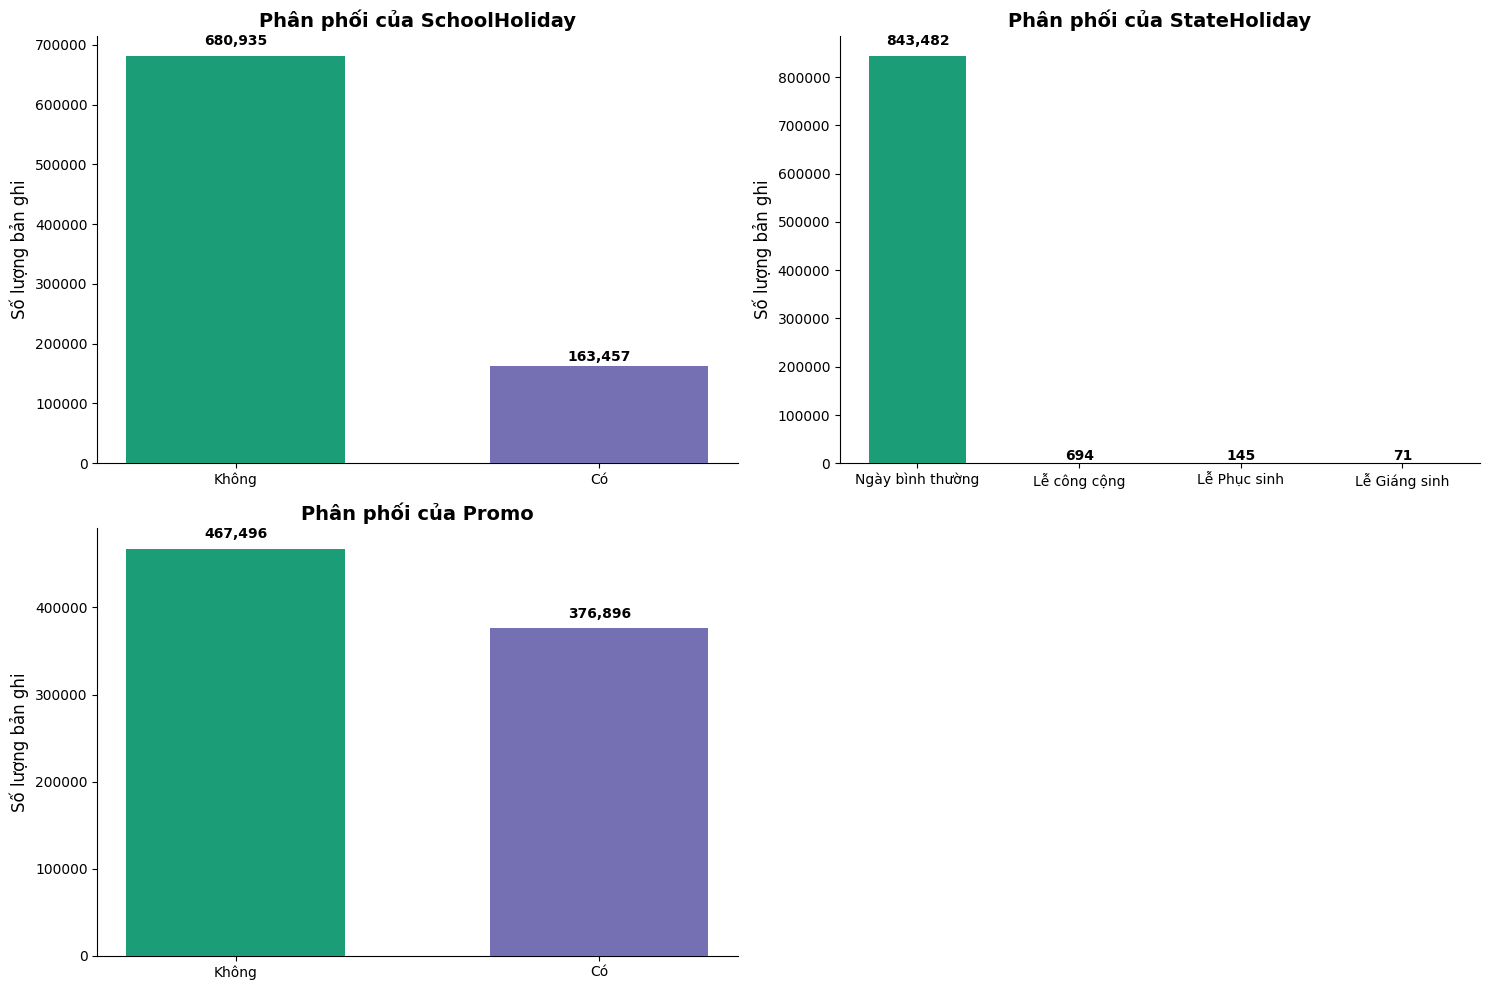

In [39]:
# Vẽ countplot cho các biến nhị phân và categorical trong df_train
# Ngưỡng: Nếu giá trị < 15% Max -> Tô Đỏ (cảnh báo thấp bất thường hoặc chênh lệch lớn)
LOW_THRESHOLD_RATIO = 0.15 

binary_mapping = {0: 'Không', 1: 'Có'}
state_holiday_mapping = {
    0: 'Ngày bình thường', '0': 'Ngày bình thường',
    'a': 'Lễ công cộng', 'b': 'Lễ Phục sinh', 'c': 'Lễ Giáng sinh'
}

binary_categorical_cols = ['SchoolHoliday', 'StateHoliday', 'Promo']

# --- KHỞI TẠO FIGURE ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(binary_categorical_cols):
    ax = axes[idx]
    
    # Đếm giá trị
    value_counts = df_train[col].value_counts().sort_index()
    
    # --- LOGIC MÀU SẮC ROSSMANN ---
    max_val = value_counts.max()
    limit_val = max_val * LOW_THRESHOLD_RATIO
    
    colors = []
    for v in value_counts.values:
        if v == max_val:
            # Màu Base (Teal): Đại diện cho nhóm phổ biến/bình thường
            colors.append(ROSSMANN_COLORS[0])
        elif v < limit_val:
            # Màu Accent (Hồng): Cảnh báo nhóm thiểu số/đặc biệt (Imbalanced)
            colors.append(ROSSMANN_COLORS[3])
        else:
            # Màu Neutral (Tím): Các nhóm trung gian
            colors.append(ROSSMANN_COLORS[2])
    
    # --- VẼ BIỂU ĐỒ ---
    # zorder=3 để bar nằm đè lên các yếu tố khác nếu có
    ax.bar(range(len(value_counts)), value_counts.values, 
           color=colors, width=0.6, zorder=3)
    
    # --- XỬ LÝ TRỤC X (MAPPING) ---
    ax.set_xticks(range(len(value_counts)))
    
    labels_display = []
    for x in value_counts.index:
        if col == 'StateHoliday':
            labels_display.append(state_holiday_mapping.get(x, str(x)))
        else:
            labels_display.append(binary_mapping.get(x, str(x)))
            
    ax.set_xticklabels(labels_display, ha='center')

    # --- FORMATTING ---
    ax.set_title(f'Phân phối của {col}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Số lượng bản ghi', fontsize=12)
    
    # Làm sạch biểu đồ (theo Global Config + Custom tinh chỉnh)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # --- DATA LABELS ---
    for i, v in enumerate(value_counts.values):
        # Offset động thông minh như code cũ
        offset = v * 0.02 if v > 0 else 10 
        ax.text(i, v + offset, f'{v:,}', 
                ha='center', va='bottom', fontweight='bold', 
                fontsize=10) # Màu chữ mặc định là đen cho dễ đọc

# Ẩn subplot thừa
if len(binary_categorical_cols) < 4:
    fig.delaxes(axes[3])

plt.tight_layout()
plt.show()


1. Cửa hàng có tỉ lệ mở cửa rất cao, điều này hợp lí vì các cửa hàng Rossmann thường mở cửa hầu hết các ngày trong tuần, chỉ đóng cửa vào những ngày lễ lớn hoặc Chủ nhật.

2. Tần suất chạy các chương trình khuyến mãi ngắn hạn (`Promo`) khá thường xuyên, chiếm khoảng 38% tổng số ngày kinh doanh.

3. Số ngày nghỉ học (`SchoolHoliday`) chiếm khoảng 22% tổng số ngày, điều này có thể ảnh hưởng đến lượng khách hàng, đặc biệt là các gia đình có con em đi học.

4. Dữ liệu của biến `StateHoliday` mất cân bằng rất nghiêm trọng khi đa số các ngày không phải là ngày lễ (giá trị '0'), trong khi các ngày lễ xuất hiện rất ít, đặc biệt là các ngày lễ loại b và c, còn loại a thì phổ biến hơn nhưng vẫn chiếm tỉ lệ rất nhỏ so với tổng số ngày.

#### Bộ dữ liệu `store.csv`


In [40]:
# Create a copy of the store dataframe for further analysis
df_store = store.copy()

In [41]:
# Xử lí sơ bộ dữ liệu store.csv để phục vụ cho việc phân tích
df_store['StoreType'] = df_store['StoreType'].astype('category')
# Định nghĩa thứ tự: a (nhỏ nhất) -> b -> c (lớn nhất)
assortment_order = CategoricalDtype(categories=['a', 'b', 'c'], ordered=True)
# Ép kiểu và áp dụng thứ tự
df_store['Assortment'] = df_store['Assortment'].astype(assortment_order)



In [42]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Store                      1115 non-null   int64   
 1   StoreType                  1115 non-null   category
 2   Assortment                 1115 non-null   category
 3   CompetitionDistance        1112 non-null   float64 
 4   CompetitionOpenSinceMonth  761 non-null    float64 
 5   CompetitionOpenSinceYear   761 non-null    float64 
 6   Promo2                     1115 non-null   int64   
 7   Promo2SinceWeek            571 non-null    float64 
 8   Promo2SinceYear            571 non-null    float64 
 9   PromoInterval              571 non-null    object  
dtypes: category(2), float64(5), int64(2), object(1)
memory usage: 72.3+ KB


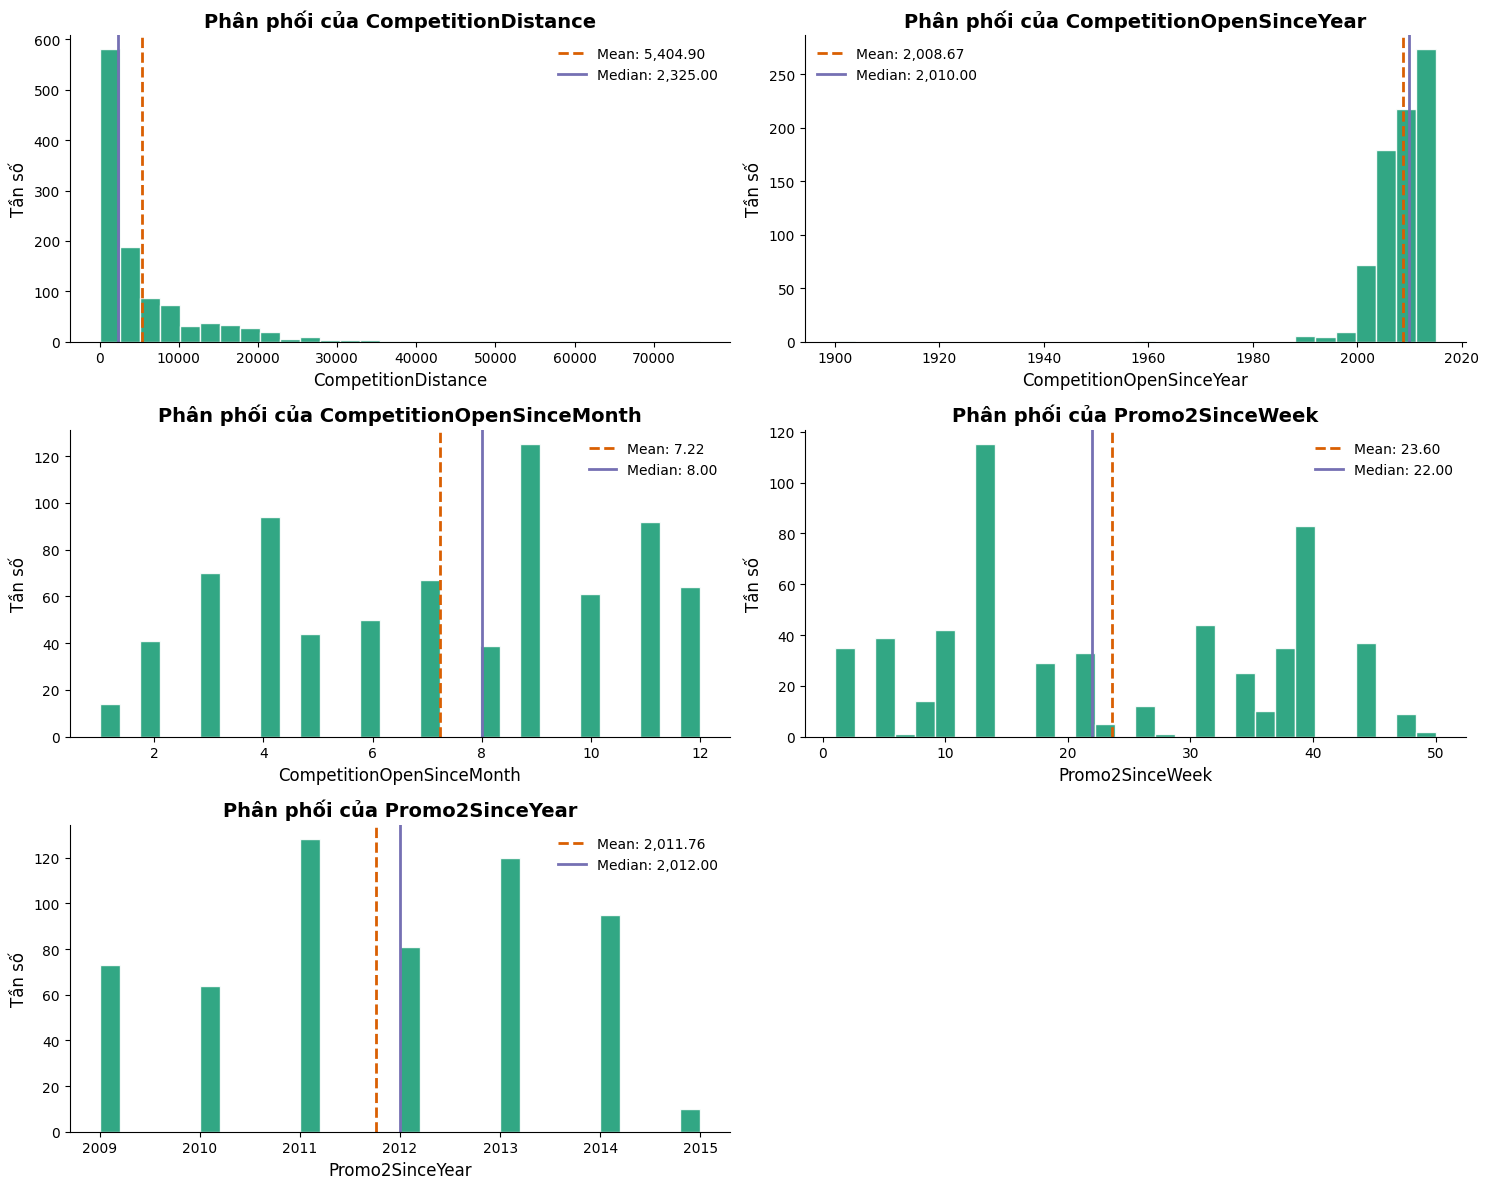

In [43]:
# Vẽ biểu đồ phân phối (Histogram) cho các biến numerical trong df_store
numerical_cols = ['CompetitionDistance', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 
                  'Promo2SinceWeek', 'Promo2SinceYear']

# Khởi tạo Figure
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    
    # Lọc bỏ giá trị NaN để vẽ
    data = df_store[col].dropna()
    
    # --- VẼ HISTOGRAM ---
    # Dùng màu Base (Teal) + viền trắng hiện đại
    ax.hist(data, bins=30, 
            color=ROSSMANN_COLORS[0], edgecolor='white', alpha=0.9)
    
    # --- THỐNG KÊ ---
    mean_val = data.mean()
    median_val = data.median()
    
    # Mean: Màu Cam (#D95F02) - Nổi bật
    ax.axvline(mean_val, color=ROSSMANN_COLORS[1], linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:,.2f}')
    
    # Median: Màu Tím (#7570B3) - Đối trọng/Trung tính
    ax.axvline(median_val, color=ROSSMANN_COLORS[2], linestyle='-', linewidth=2, 
               label=f'Median: {median_val:,.2f}')
    
    # --- FORMATTING ---
    ax.set_title(f'Phân phối của {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Tần số', fontsize=12)
    
    # Legend đơn giản
    ax.legend(frameon=False)
    
    # Làm sạch biểu đồ (Clean Chart)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# Ẩn subplot thừa (vị trí cuối cùng - index 5)
if len(numerical_cols) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

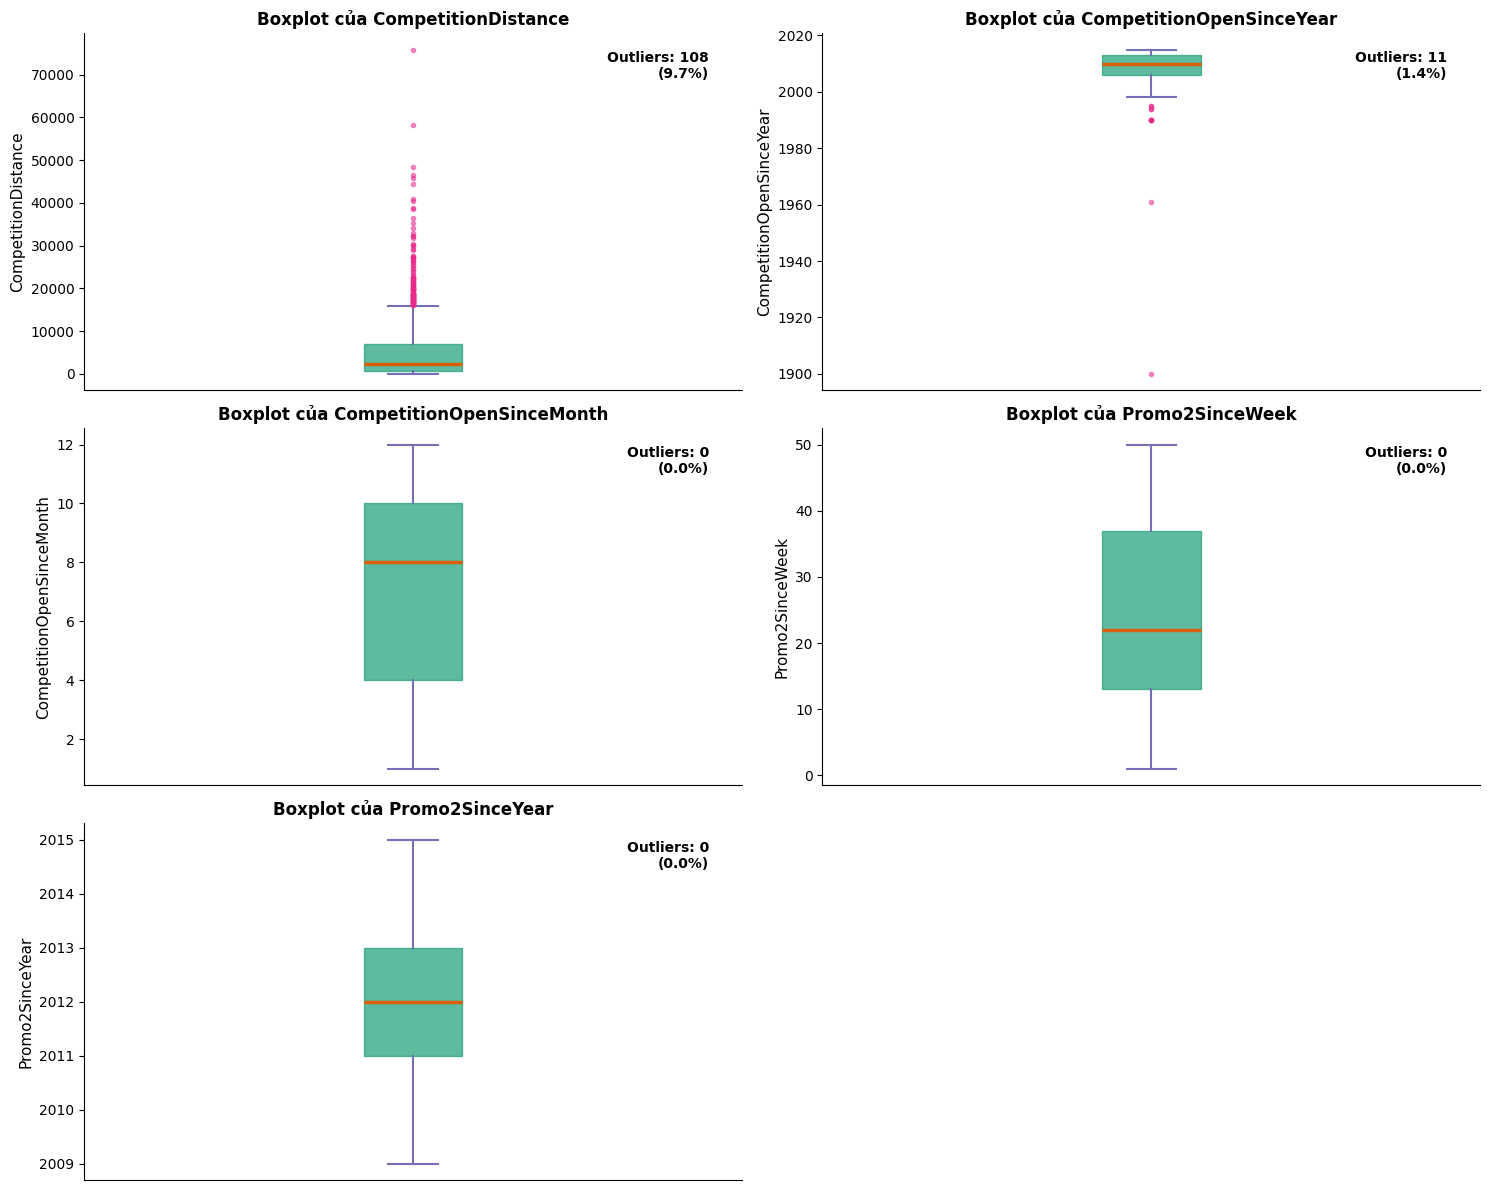

In [44]:
# Danh sách biến
numerical_cols_boxplot = ['CompetitionDistance', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth',
                          'Promo2SinceWeek', 'Promo2SinceYear']

# Khởi tạo Figure
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols_boxplot):
    ax = axes[idx]
    
    # Lọc bỏ giá trị NaN
    data = df_store[col].dropna()
    
    # --- VẼ BOXPLOT ---
    # flierprops: Cấu hình Outliers (Màu Hồng, style đám mây)
    flierprops = dict(
        marker='o', 
        markerfacecolor=ROSSMANN_COLORS[3], # Hồng
        markeredgecolor=ROSSMANN_COLORS[3], # Viền hồng (để chấm trông mềm hơn)
        markersize=3, 
        alpha=0.5,
        linestyle='none'
    )
    
    # boxprops: Cấu hình hộp (Màu Teal)
    boxprops = dict(facecolor=ROSSMANN_COLORS[0], color=ROSSMANN_COLORS[0], linewidth=1, alpha=0.7)
    
    # medianprops: Đường trung vị (Màu Cam - Highlight)
    medianprops = dict(color=ROSSMANN_COLORS[1], linewidth=2.5)
    
    # whiskerprops & capprops: (Màu Tím - Neutral)
    whiskerprops = dict(color=ROSSMANN_COLORS[2], linewidth=1.5)
    capprops = dict(color=ROSSMANN_COLORS[2], linewidth=1.5)
    
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=boxprops,
               medianprops=medianprops,
               whiskerprops=whiskerprops,
               capprops=capprops,
               flierprops=flierprops)
    
    # --- FORMATTING ---
    ax.set_title(f'Boxplot của {col}', fontsize=12, fontweight='bold')
    ax.set_xticks([]) # Bỏ tick trục x
    ax.set_ylabel(col, fontsize=11)
    
    # Làm sạch biểu đồ
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # --- TÍNH TOÁN & HIỂN THỊ TEXT OUTLIERS ---
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_count = len(data[(data < lower_bound) | (data > upper_bound)])
    
    # Hiển thị text sạch (góc phải trên)
    ax.text(0.95, 0.95, 
            f'Outliers: {outliers_count}\n({outliers_count/len(data)*100:.1f}%)',
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='top', horizontalalignment='right', fontweight='bold',
            color='black') # Dùng màu đen hoặc Tím đậm để dễ đọc text

# Ẩn subplot thừa
for i in range(len(numerical_cols_boxplot), 6):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

1. Biến `CompetitionDistance`: Biểu đồ dồn cục cực lớn ở phía bên trái (khoảng cách ngắn) và kéo cái đuôi dài tít tắp về phía bên phải cho thấy có rất nhiều cửa hàng Rossmann có đối thủ cạnh tranh ở rất gần (thường < 1km hoặc < 3km). Mặc dù không xét đến missing value nhưng ta vẫn thấy outlier khá nhiều, đây là các cửa hàng rất xa so với các dữ liệu khác. Điều này phản ánh chiến lược chọn địa điểm của Rossmann là đánh vào các khu đông dân cư, trung tâm sầm uất.

2. Biến `CompetitionOpenSinceYear`: Đa số dữ liệu dồn vào khoảng năm 2000 - 2015 bên cạnh đó vẫn có một vài giá trị rất nhỏ nằm tít phía xa bên trái (năm 1900, 1961...). Xuất hiện 9 giá trị outlier trong đó có các giá trị như là 1900 và 1960 có vẻ như không hợp lý lắm vì đã quá lâu đời.

3. Biến `CompetitionOpenSinceMonth`: Dữ liệu phân phối khá đều các tháng, không quá chênh lệch, không có outlier.
4. Biến `Promo2SinceWeek`: Cao điểm ở khoảng tuần 13 có thể là do Rossmann có chương trình khuyến mãi thường xuyên vào tuần này, các tuần còn lại phân bố khá đồng đều, không có outlier.
5. Biến `Promo2SinceYear`: Dữ liệu phân phối khá đều các năm, không quá chênh lệch, không có outlier. Năm 2015 quan sát được có vẻ thấp hơn các năm còn lại có thể là do dữ liệu thu thập mới chỉ đến tháng 7 chưa hết năm 2015.


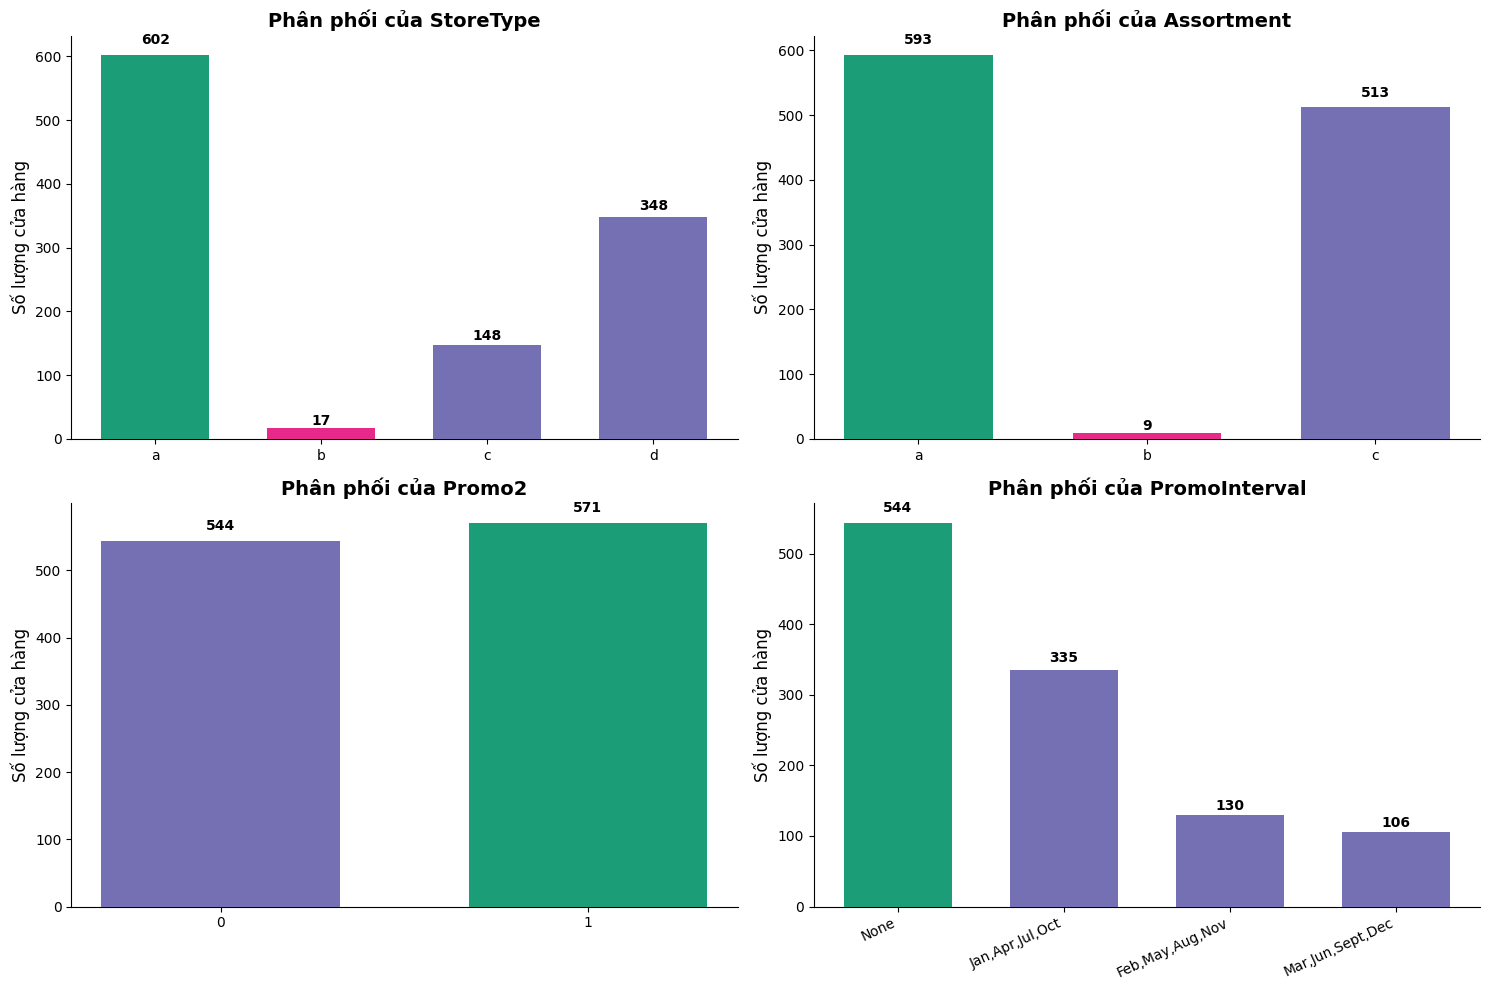

In [45]:
# Vẽ countplot cho các biến categorical và biến nhị phân còn lại trong df_store
# Cấu hình ngưỡng: Nếu giá trị < 15% của giá trị lớn nhất -> Coi là hiếm/lệch -> Tô Hồng
LOW_THRESHOLD_RATIO = 0.15 

categorical_cols = ['StoreType', 'Assortment', 'Promo2', 'PromoInterval']

# Mapping cho dễ đọc (Tùy chọn, nếu không cần có thể bỏ qua)
# assortment_map = {'a': 'Basic', 'b': 'Extra', 'c': 'Extended'}
# store_type_map = {'a': 'Type A', 'b': 'Type B', 'c': 'Type C', 'd': 'Type D'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]

    # 1. Xử lý dữ liệu
    if col == 'PromoInterval':
        # Thay thế NaN bằng 'None' (Không tham gia)
        value_counts = df_store[col].fillna('None').value_counts()
    else:
        value_counts = df_store[col].value_counts().sort_index()

    # 2. Logic màu sắc Rossmann
    max_val = value_counts.max()
    limit_val = max_val * LOW_THRESHOLD_RATIO 
    
    colors = []
    for v in value_counts.values:
        if v == max_val:
            colors.append(ROSSMANN_COLORS[0]) # Teal (Base): Nhóm phổ biến nhất
        elif v < limit_val:
            colors.append(ROSSMANN_COLORS[3]) # Hồng (Accent): Nhóm thiểu số/Hiếm gặp
        else:
            colors.append(ROSSMANN_COLORS[2]) # Tím (Neutral): Nhóm trung gian

    # 3. Vẽ biểu đồ
    ax.bar(range(len(value_counts)), value_counts.values, 
           color=colors, width=0.65, zorder=3)
    
    # 4. Căn chỉnh nhãn trục X
    ax.set_xticks(range(len(value_counts)))
    
    if col == 'PromoInterval':
        # Xoay nhãn cho PromoInterval vì tên dài
        ax.set_xticklabels(value_counts.index, rotation=25, ha='right')
    else:
        # Giữ nguyên cho các biến ngắn
        ax.set_xticklabels(value_counts.index, rotation=0, ha='center')

    # 5. Formatting
    ax.set_title(f'Phân phối của {col}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Số lượng cửa hàng', fontsize=12)
    
    # Clean Chart
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # 6. Data Labels
    for i, v in enumerate(value_counts.values):
        offset = v * 0.02 if v > 0 else 5
        ax.text(i, v + offset, f'{v:,}', 
                ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [46]:
# Đếm số loại cửa hàng loại b đồng thời có assortment b
count_b_storetype_assortment_b = df_store[(df_store['StoreType'] == 'b') & (df_store['Assortment'] == 'b')].shape[0]
count_b_storetype_assortment_b

9

1. Dữ liệu rất mất cân bằng khi ở cả 2 biến `StoreType` và `Assortment` dữ liệu về giá trị b rất ít so với các giá trị còn lại và chỉ chiếm khoảng 1%.

2. Biến `Promo2` phân phối rất đều số lượng cửa hàng áp dụng `Promo2` và không áp dụng xấp xỉ nhau.

3. Biến `PromoInterval` có rất nhiều dữ liệu thiếu, có thể là do các cửa hàng không tham gia chương trình khuyến mãi dài hạn này. Trong số các cửa hàng có thông tin về khoảng thời gian khuyến mãi, các khoảng thời gian phổ biến nhất là "Jan, Apr, Jul, Oct" và "Feb, May, Aug, Nov".

4. Tất cả `Assortment b` đều là `StoreType b`

#### Kết luận phân tích đơn biến


<b> 1. Các biến liên quan đến đối thủ </b>
- Phần lớn các cửa hàng có đối thủ nằm ở khoảng cách rất gần (dưới 1–3 km) nhưng vẫn còn outlier khá nhiều, đây là các cửa hàng rất xa so với các dữ liệu khác, thể hiện rõ chiến lược tập trung và mở rộng tại các khu dân cư đông đúc, trung tâm thương mại.

- Các giá trị outlier như năm 1900, 1961 trong `CompetitionOpenSinceYear` trông có vẻ không thực tế vì khá lâu đời rồi.

<b> 2. Các biến liên quan đến promotion </b>
- Tần suất chạy `Promo` (khuyến mãi ngắn hạn) chiếm đến 38% ngày hoạt động, chứng tỏ promotion là chiến lược kinh doanh chủ lực của Rossmann.

- Khoảng một nửa cửa hàng tham gia `Promo2`,

- Biến `PromoInterval` có rất nhiều dữ liệu thiếu, có thể là do các cửa hàng không tham gia chương trình khuyến mãi dài hạn này. Trong số các cửa hàng có thông tin về khoảng thời gian khuyến mãi, các khoảng thời gian phổ biến nhất là "Jan, Apr, Jul, Oct" và "Feb, May, Aug, Nov".

<b> 3. Vấn đề mất cân bằng dữ liệu </b>
- Các loại `StoreType` và `Assortment` có giá trị hiếm (loại b) chiếm chưa tới 1% thể sự mất cân bằng dữ liệu rất mạnh

- Biến `StateHoliday` cực kỳ mất cân bằng khi hầu hết các ngày không phải lễ, khiến các giá trị a, b, c có thể đóng góp thông tin nhưng cần kỹ thuật xử lý để mô hình hiểu được.

### <b>Phân tích 2 biến</b>

#### Phân tích

In [47]:
# Gộp dữ liệu train và store để phân tích mối quan hệ giữa các biến và drop các ngày cửa hàng đóng cửa có
df_merged_full = pd.merge(df_train_full, df_store, on='Store', how='inner')
df_merged = pd.merge(df_train, df_store, on='Store', how='inner')


In [48]:
df_merged_full.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [49]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[ns]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  category      
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  category      
 10  Assortment                 844392 non-null  category      
 11  CompetitionDistance        842206 non-null  float64 

In [50]:
# Biến Date thành index
df_merged.set_index('Date', inplace=True)
# Trích xuất các đặc trưng thời gian từ cột Date
df_merged['Year'] = df_merged.index.year
df_merged['Month'] = df_merged.index.month
df_merged['Day'] = df_merged.index.day
df_merged['WeekOfYear'] = df_merged.index.isocalendar().week

# Thêm biến SalePerCustomer
df_merged['SalePerCustomer'] = df_merged['Sales']/df_merged['Customers']

#Tương tự với df_merged_full
df_merged_full.set_index('Date', inplace=True)
df_merged_full['Year'] = df_merged_full.index.year
df_merged_full['Month'] = df_merged_full.index.month
df_merged_full['Day'] = df_merged_full.index.day
df_merged_full['WeekOfYear'] = df_merged_full.index.isocalendar().week
df_merged_full['SalePerCustomer'] = df_merged_full['Sales']/df_merged_full['Customers']


In [51]:
df_merged.isnull().sum()

Store                             0
DayOfWeek                         0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
Year                              0
Month                             0
Day                               0
WeekOfYear                        0
SalePerCustomer                  52
dtype: int64

> Các nhóm biến có liên quan đến biến `Promo2` và các nhốm biến liên quan đến biến `Competition` đều có số lượng missing value khá lớn, trong khi các biến còn lại không có missing value nào. Do đó chúng ta sẽ tìm hiểu xem lý do tại sao các biến này lại có nhiều missing value như vậy.


In [52]:
df_merged[df_merged['CompetitionDistance'].isnull()].head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-31,291,5,10052,973,1,1,0,1,d,a,...,NaN,0,NaN,NaN,NaN,2015,7,31,31,10.330935
2015-07-31,622,5,6306,540,1,1,0,1,a,c,...,NaN,0,NaN,NaN,NaN,2015,7,31,31,11.677778
2015-07-31,879,5,6000,466,1,1,0,0,d,a,...,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov",2015,7,31,31,12.875536
2015-07-30,291,4,9030,883,1,1,0,1,d,a,...,NaN,0,NaN,NaN,NaN,2015,7,30,31,10.226501
2015-07-30,622,4,5412,406,1,1,0,1,a,c,...,NaN,0,NaN,NaN,NaN,2015,7,30,31,13.330049


In [53]:
df_merged[df_merged['CompetitionOpenSinceMonth'].isnull()].head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-31,12,5,8959,962,1,1,0,1,a,c,...,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,9.312890
2015-07-31,13,5,8821,568,1,1,0,0,d,a,...,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov",2015,7,31,31,15.529930
2015-07-31,16,5,10231,979,1,1,0,1,a,c,...,NaN,0,NaN,NaN,NaN,2015,7,31,31,10.450460
2015-07-31,19,5,8234,718,1,1,0,1,a,c,...,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec",2015,7,31,31,11.467967
2015-07-31,22,5,6566,633,1,1,0,0,a,a,...,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct",2015,7,31,31,10.372828


In [54]:
df_merged[df_merged['CompetitionOpenSinceYear'].isnull()].head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-31,12,5,8959,962,1,1,0,1,a,c,...,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,9.312890
2015-07-31,13,5,8821,568,1,1,0,0,d,a,...,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov",2015,7,31,31,15.529930
2015-07-31,16,5,10231,979,1,1,0,1,a,c,...,NaN,0,NaN,NaN,NaN,2015,7,31,31,10.450460
2015-07-31,19,5,8234,718,1,1,0,1,a,c,...,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec",2015,7,31,31,11.467967
2015-07-31,22,5,6566,633,1,1,0,0,a,a,...,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct",2015,7,31,31,10.372828


Quan sát thấy khi biến `CompetitionDistance` có missing value thì các biến `CompetitionOpenSinceMonth` và `CompetitionOpenSinceYear` cũng đều có missing value tương ứng. Điều này cho thấy các cửa hàng không có đối thủ cạnh tranh gần thì cũng không có thông tin về thời gian mở cửa của đối thủ.
Tuy nhiên khi biến `CompetitionOpenSinceMonth` và `CompetitionOpenSinceYear` có missing value thì biến `CompetitionDistance` không nhất thiết phải missing value. Điều này có thể do thông tin thực sự bị thiếu do không thu thập được dữ liệu từ các cửa hàng đối thủ cạnh tranh.

_Có lẽ cũng tương tự đối với các biến liên quan đến Promo2, khi biến Promo2 có giá trị 0 thì các biến Promo2SinceWeek và Promo2SinceYear sẽ có missing value vì cửa hàng không tham gia chương trình khuyến mãi dài hạn này ?_


In [55]:
df_merged[df_merged['Promo2'] == 0][['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']].isnull().sum()

Promo2SinceWeek    423307
Promo2SinceYear    423307
PromoInterval      423307
dtype: int64

Số lượng missing value của các biến liên quan đến `Promo2` khi biến `Promo2 = 0` thực sự bằng số lượng missing value của các biến này trong toàn bộ dữ liệu, vì vậy giả thuyết trên là đúng.

_Biến `SalePerCustomer` có 52 missing value, có thể là do dữ liệu các ngày không có khách hàng (`Customers = 0`) dẫn đến việc không thể tính toán được doanh thu trên mỗi khách hàng?_


In [56]:
print(f"Số lượng ngày có Customers = 0: {(df_merged['Customers'] == 0).sum()}")

Số lượng ngày có Customers = 0: 52


Số lượng ngày có `Customers = 0` đúng bằng số lượng missing value của biến `SalePerCustomer` vì vậy điều đó là đúng.

_Tiếp đến chúng ta sẽ xem doanh thu của các cửa hàng theo thời gian_


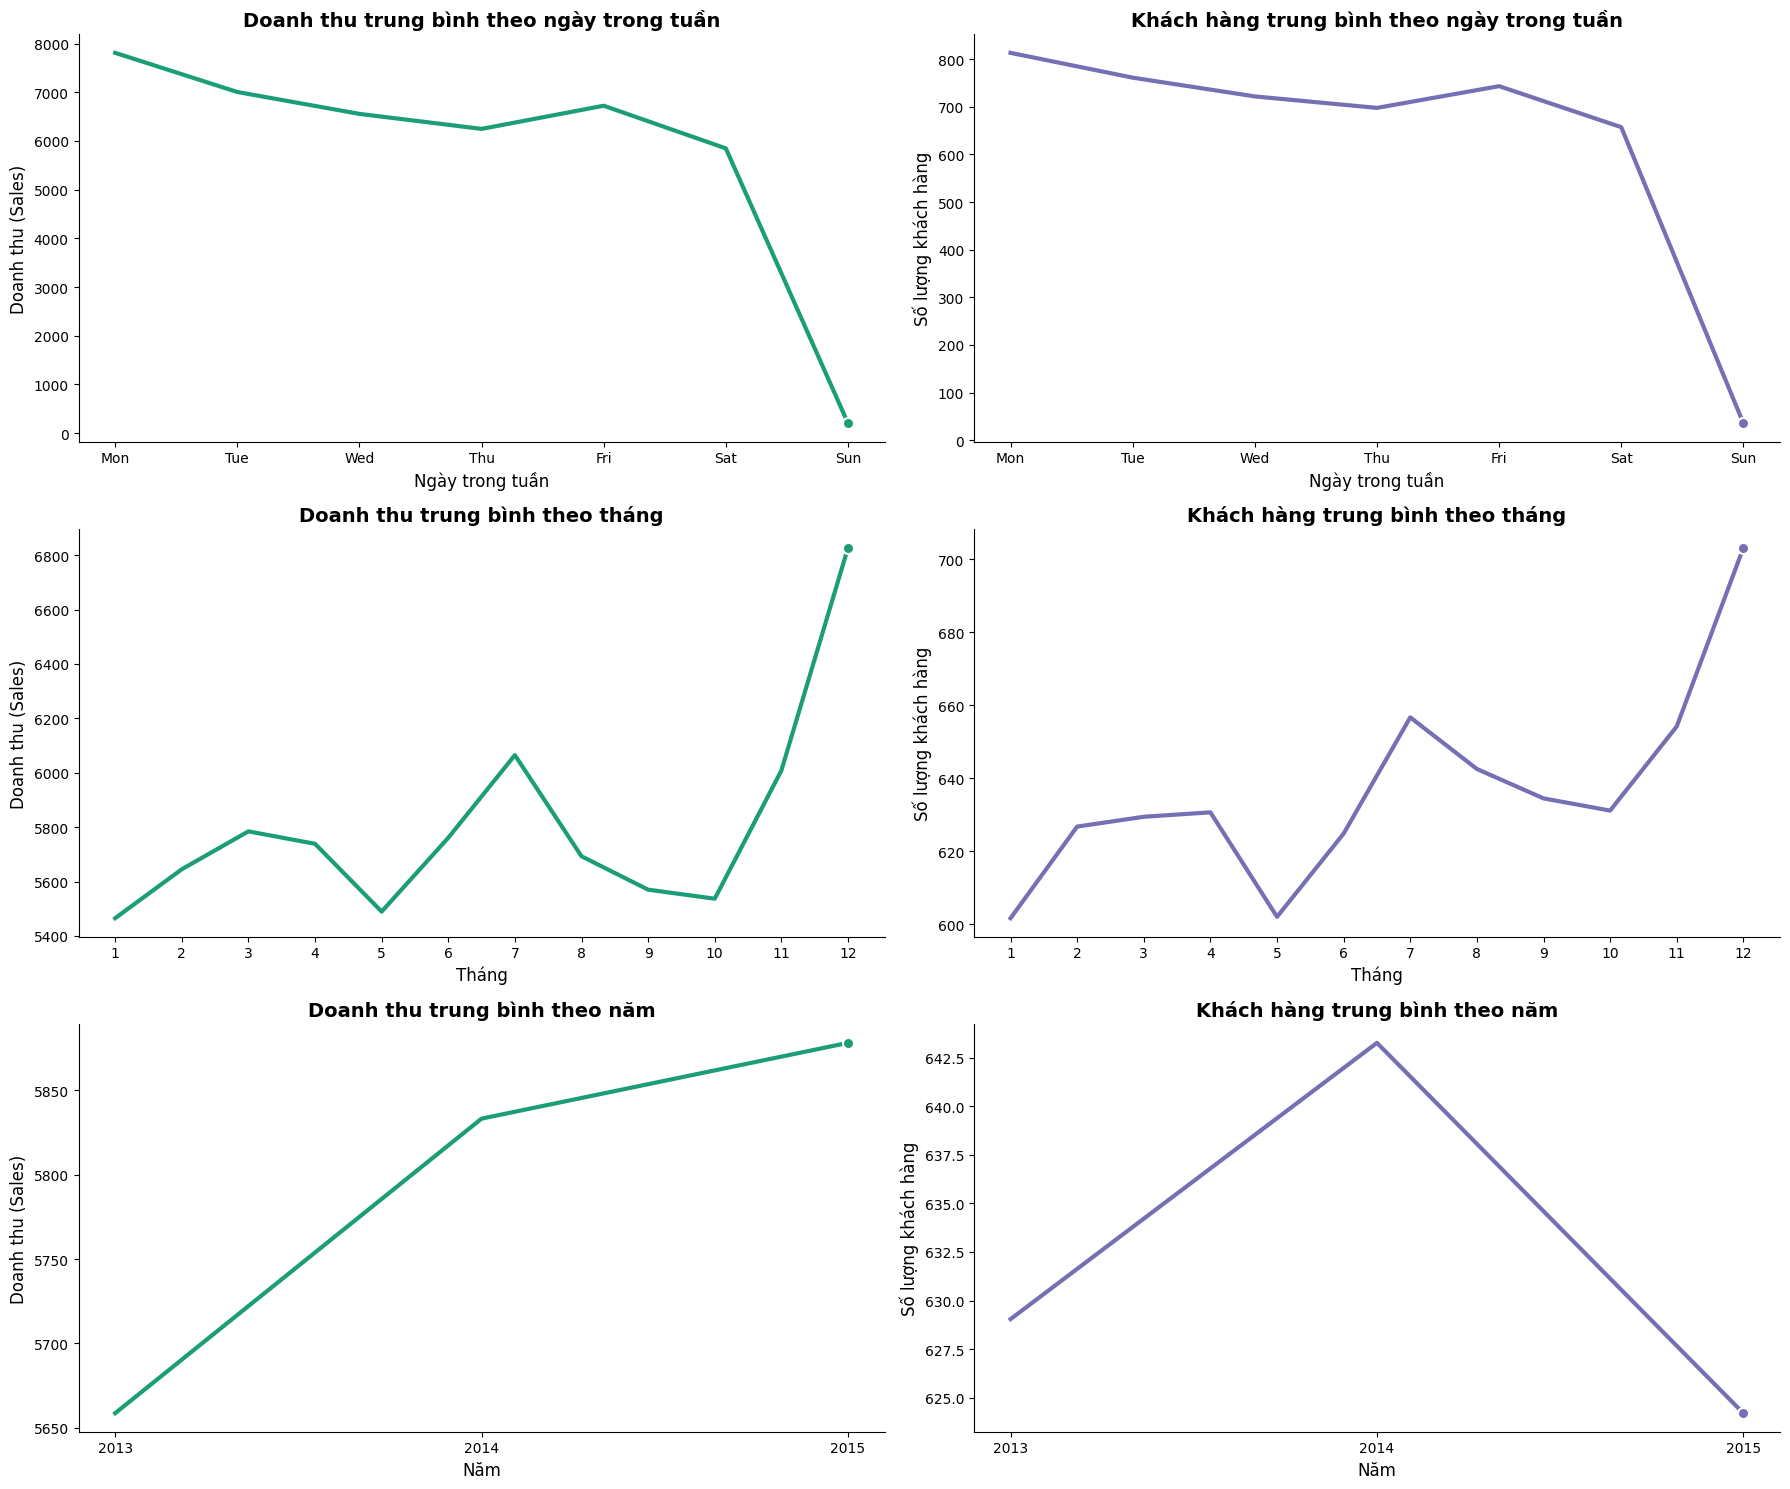

In [57]:
# Vẽ biểu đồ doanh thu và số lượng khách hàng theo ngày, tháng, năm
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# --- HÀM HỖ TRỢ VẼ LINE CHUẨN ROSSMANN (Chỉ marker cuối) ---
def plot_rossmann_line(ax, data, color, title, xlabel, ylabel, xticks=None, xticklabels=None):
    x = data.index
    y = data.values
    
    # 1. Vẽ đường (Không có marker)
    ax.plot(x, y, color=color, linewidth=3, zorder=2)
    
    # 2. Chỉ vẽ Marker ở điểm cuối cùng
    # (Dùng x.values[-1] để tránh lỗi index nếu x không phải dạng số nguyên liên tục)
    last_x = x[-1] if hasattr(x, '__getitem__') else list(x)[-1]
    last_y = y[-1] if hasattr(y, '__getitem__') else list(y)[-1]
    
    ax.plot(last_x, last_y, marker='o', markersize=8, 
            color=color, markeredgecolor='white', markeredgewidth=1.5, zorder=3)
    
    # 3. Formatting Text
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # 4. Xử lý trục X (nếu có yêu cầu đặc biệt)
    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels)
        
    # 5. Clean Chart (Theo quy tắc Global + Custom)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# ==========================================
# 1. THEO NGÀY TRONG TUẦN (DayOfWeek)
# ==========================================
# Sales -> Màu Base (Teal)
daily_sales = df_merged_full.groupby('DayOfWeek')['Sales'].mean()
plot_rossmann_line(
    axes[0, 0], daily_sales, ROSSMANN_COLORS[0],
    'Doanh thu trung bình theo ngày trong tuần', 'Ngày trong tuần', 'Doanh thu (Sales)',
    xticks=range(1, 8),
    xticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

# Customers -> Màu Neutral (Tím)
daily_customers = df_merged_full.groupby('DayOfWeek')['Customers'].mean()
plot_rossmann_line(
    axes[0, 1], daily_customers, ROSSMANN_COLORS[2],
    'Khách hàng trung bình theo ngày trong tuần', 'Ngày trong tuần', 'Số lượng khách hàng',
    xticks=range(1, 8),
    xticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

# ==========================================
# 2. THEO THÁNG (Month)
# ==========================================
# Sales -> Teal
monthly_sales = df_merged_full.groupby('Month')['Sales'].mean()
plot_rossmann_line(
    axes[1, 0], monthly_sales, ROSSMANN_COLORS[0],
    'Doanh thu trung bình theo tháng', 'Tháng', 'Doanh thu (Sales)',
    xticks=range(1, 13)
)

# Customers -> Tím
monthly_customers = df_merged_full.groupby('Month')['Customers'].mean()
plot_rossmann_line(
    axes[1, 1], monthly_customers, ROSSMANN_COLORS[2],
    'Khách hàng trung bình theo tháng', 'Tháng', 'Số lượng khách hàng',
    xticks=range(1, 13)
)

# ==========================================
# 3. THEO NĂM (Year)
# ==========================================
# Sales -> Teal
yearly_sales = df_merged_full.groupby('Year')['Sales'].mean()
plot_rossmann_line(
    axes[2, 0], yearly_sales, ROSSMANN_COLORS[0],
    'Doanh thu trung bình theo năm', 'Năm', 'Doanh thu (Sales)',
    xticks=yearly_sales.index
)

# Customers -> Tím
yearly_customers = df_merged_full.groupby('Year')['Customers'].mean()
plot_rossmann_line(
    axes[2, 1], yearly_customers, ROSSMANN_COLORS[2],
    'Khách hàng trung bình theo năm', 'Năm', 'Số lượng khách hàng',
    xticks=yearly_customers.index
)

plt.tight_layout()
plt.show()

In [58]:
yearly_summary = df_merged.groupby('Year').agg({
    'Sales': ['mean', 'sum'],
    'Customers': ['mean', 'sum'],
    'SalePerCustomer': 'mean'
}).reset_index()
yearly_summary


Year        Sales               Customers            SalePerCustomer
                mean         sum        mean        sum            mean
0  2013  6814.392025  2302876084  757.537292  256004425        9.366255
1  2014  7025.404201  2180804896  774.728739  240488971        9.432351
2  2015  7088.126648  1389499643  752.674864  147548359        9.810185

1. Có sự tượng đồng rõ rệt trong biểu đồ doanh thu và lượng khách trung bình theo các ngày trong tuần và theo tháng, điều này vô cùng hợp lí vì lượng khách hàng đến cửa hàng sẽ ảnh hưởng trực tiếp đến doanh thu bán hàng.

2. Doanh thu và lượng khách hàng trung bình theo năm có chút không hợp lý khi doanh thu trung bình ở năm 2015 tăng so với các năm trước còn lượng khách hàng trung bình thì lại giảm mặc dù dữ liệu năm 2015 chỉ đến tháng 7, tuy nhiên có thể lý giải 1 phần thông qua `SalePerCustomer` trung bình hàng năm cho thấy vào năm 2015 trung bình mỗi khách hàng mua hàng với giá trị 9.81 dollars cao hơn so với các năm trước (năm 2013 là 9.43 dollars và năm 2014 là 9.36 dollars), từ đó dẫn đến doanh thu trung bình tăng mặc dù lượng khách hàng giảm. 

3. Doanh thu và lượng khách hàng trung bình có sự sụt giảm nghiêm trọng ở các ngày chủ nhật và vào tháng 1 và tháng 5 hàng năm, ngược lại tăng mạnh vào các ngày đầu tuần và vào các tháng cuối năm như tháng 11 và tháng 12. Đây có thể là 1 đặc điểm về tính mùa vụ của cửa hàng Rossmann cần được khai thác sâu hơn.

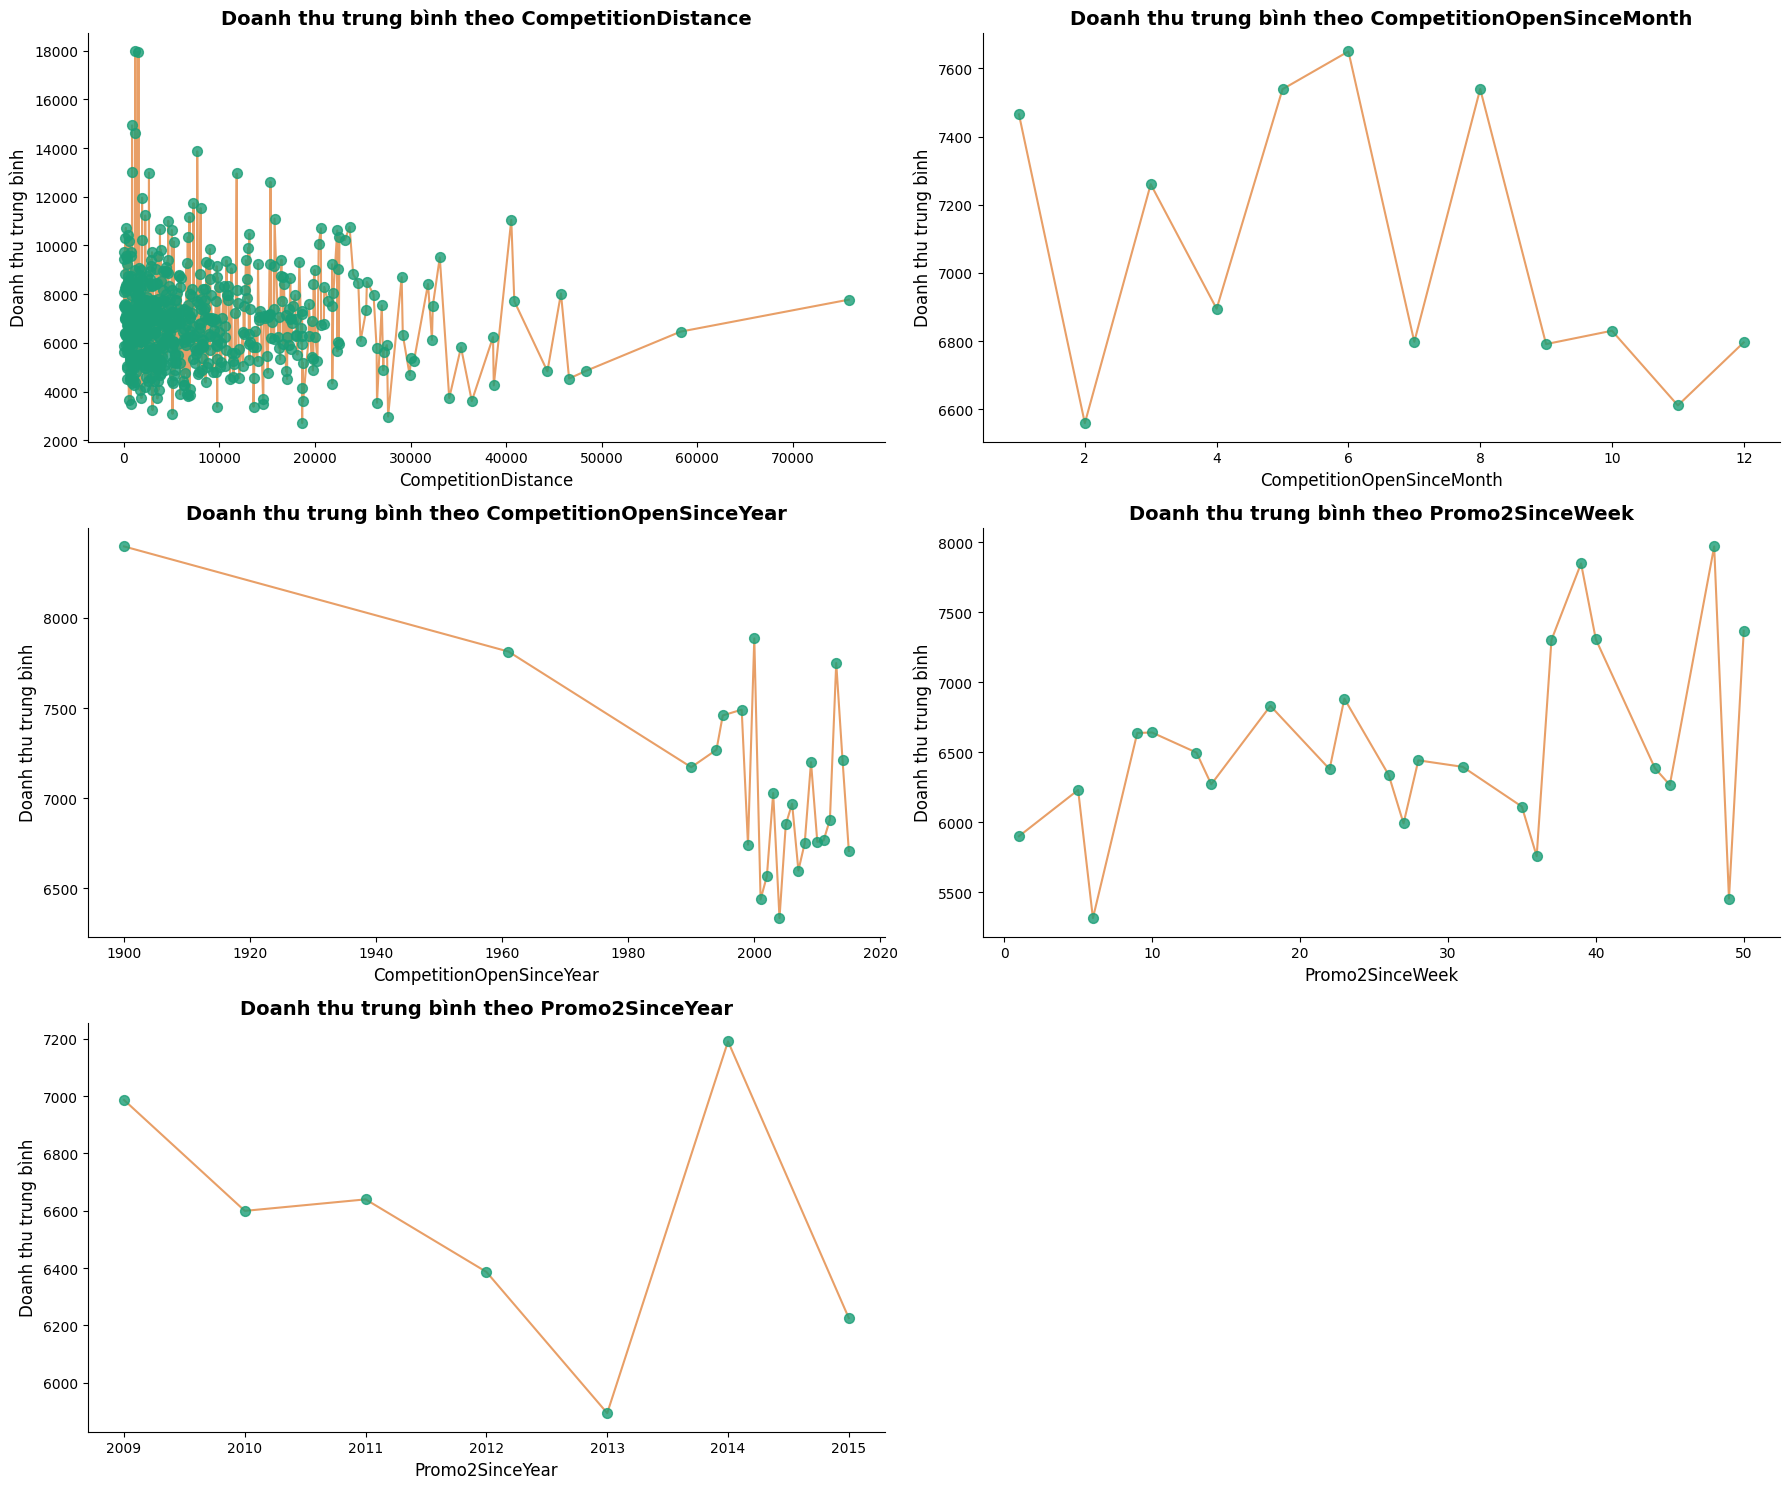

In [59]:
# Danh sách biến
numerical_vars = ['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
                  'Promo2SinceWeek', 'Promo2SinceYear']

# Khởi tạo Figure
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(numerical_vars):
    ax = axes[idx]
    
    # Lọc dữ liệu > 0 để tránh nhiễu từ những ngày đóng cửa
    df_plot = df_merged[df_merged['Sales'] > 0][[var, 'Sales']].copy()

    # Kiểm tra dữ liệu rỗng
    if df_plot.empty or df_plot[var].nunique() == 0:
        ax.set_visible(False)
        continue

    # Tính doanh thu trung bình (Groupby mặc định sẽ sort theo var -> vẽ line không bị rối)
    grouped = df_plot.groupby(var)['Sales'].mean().reset_index()

    # --- VẼ BIỂU ĐỒ ---
    # 1. Scatter: Màu Base (Teal)
    ax.scatter(grouped[var], grouped['Sales'], 
               alpha=0.8, s=50, color=ROSSMANN_COLORS[0], zorder=2)
    
    # 2. Line connecting: Màu Highlight (Cam)
    # Dùng màu cam để người xem thấy rõ xu hướng biến động giữa các điểm
    ax.plot(grouped[var], grouped['Sales'], 
            alpha=0.6, color=ROSSMANN_COLORS[1], linewidth=1.5, zorder=1)

    # --- FORMATTING ---
    ax.set_title(f'Doanh thu trung bình theo {var}', fontsize=14, fontweight='bold')
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('Doanh thu trung bình', fontsize=12)
    
    # Clean Chart (Bỏ Grid & Spines)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# Ẩn subplot thừa (vị trí cuối cùng index 5)
if len(numerical_vars) < 6:
    for i in range(len(numerical_vars), 6):
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [60]:
# Xem df_merged khi StateHoliday là d
df_merged[df_merged['StateHoliday']=='c']

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-26,85,5,9741,1161,1,0,c,1,b,a,...,2011.0,0,NaN,NaN,NaN,2014,12,26,52,8.390181
2014-12-26,259,5,17597,2544,1,0,c,1,b,b,...,NaN,0,NaN,NaN,NaN,2014,12,26,52,6.917060
2014-12-26,262,5,32169,4468,1,0,c,1,b,a,...,2013.0,0,NaN,NaN,NaN,2014,12,26,52,7.199866
2014-12-26,274,5,7818,1412,1,0,c,1,b,b,...,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct",2014,12,26,52,5.536827
2014-12-26,299,5,1800,190,1,0,c,1,d,c,...,2012.0,0,NaN,NaN,NaN,2014,12,26,52,9.473684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-25,733,3,12223,2335,1,0,c,1,b,b,...,1999.0,0,NaN,NaN,NaN,2013,12,25,52,5.234690
2013-12-25,769,3,10033,2055,1,0,c,1,b,b,...,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,12,25,52,4.882238
2013-12-25,948,3,7138,1320,1,0,c,1,b,b,...,NaN,0,NaN,NaN,NaN,2013,12,25,52,5.407576


1. Doanh thu trung bình với các biến theo tuần không thấy được xu hướng rõ ràng nào

2. Doanh thu trung bình khi áp dụng `promo2` biến thiên khá linh hoạt, điểm nhấn là doanh thu trung bình vào năm 2013 là thấp nhất nhưng lại cao nhất vào năm 2014, cho thấy chiến lược khuyến mãi dài hạn thực sự tác động lớn đến doanh thu của cửa hàng nhưng cần phân tích sâu hơn để rút ra kết luận chính xác.

C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\1356027500.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sales = df_merged.groupby(temp_series)['Sales'].mean().sort_values(ascending=False)
C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\1356027500.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sales = df_merged.groupby(temp_series)['Sales'].mean().sort_values(ascending=False)
C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\1356027500.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain

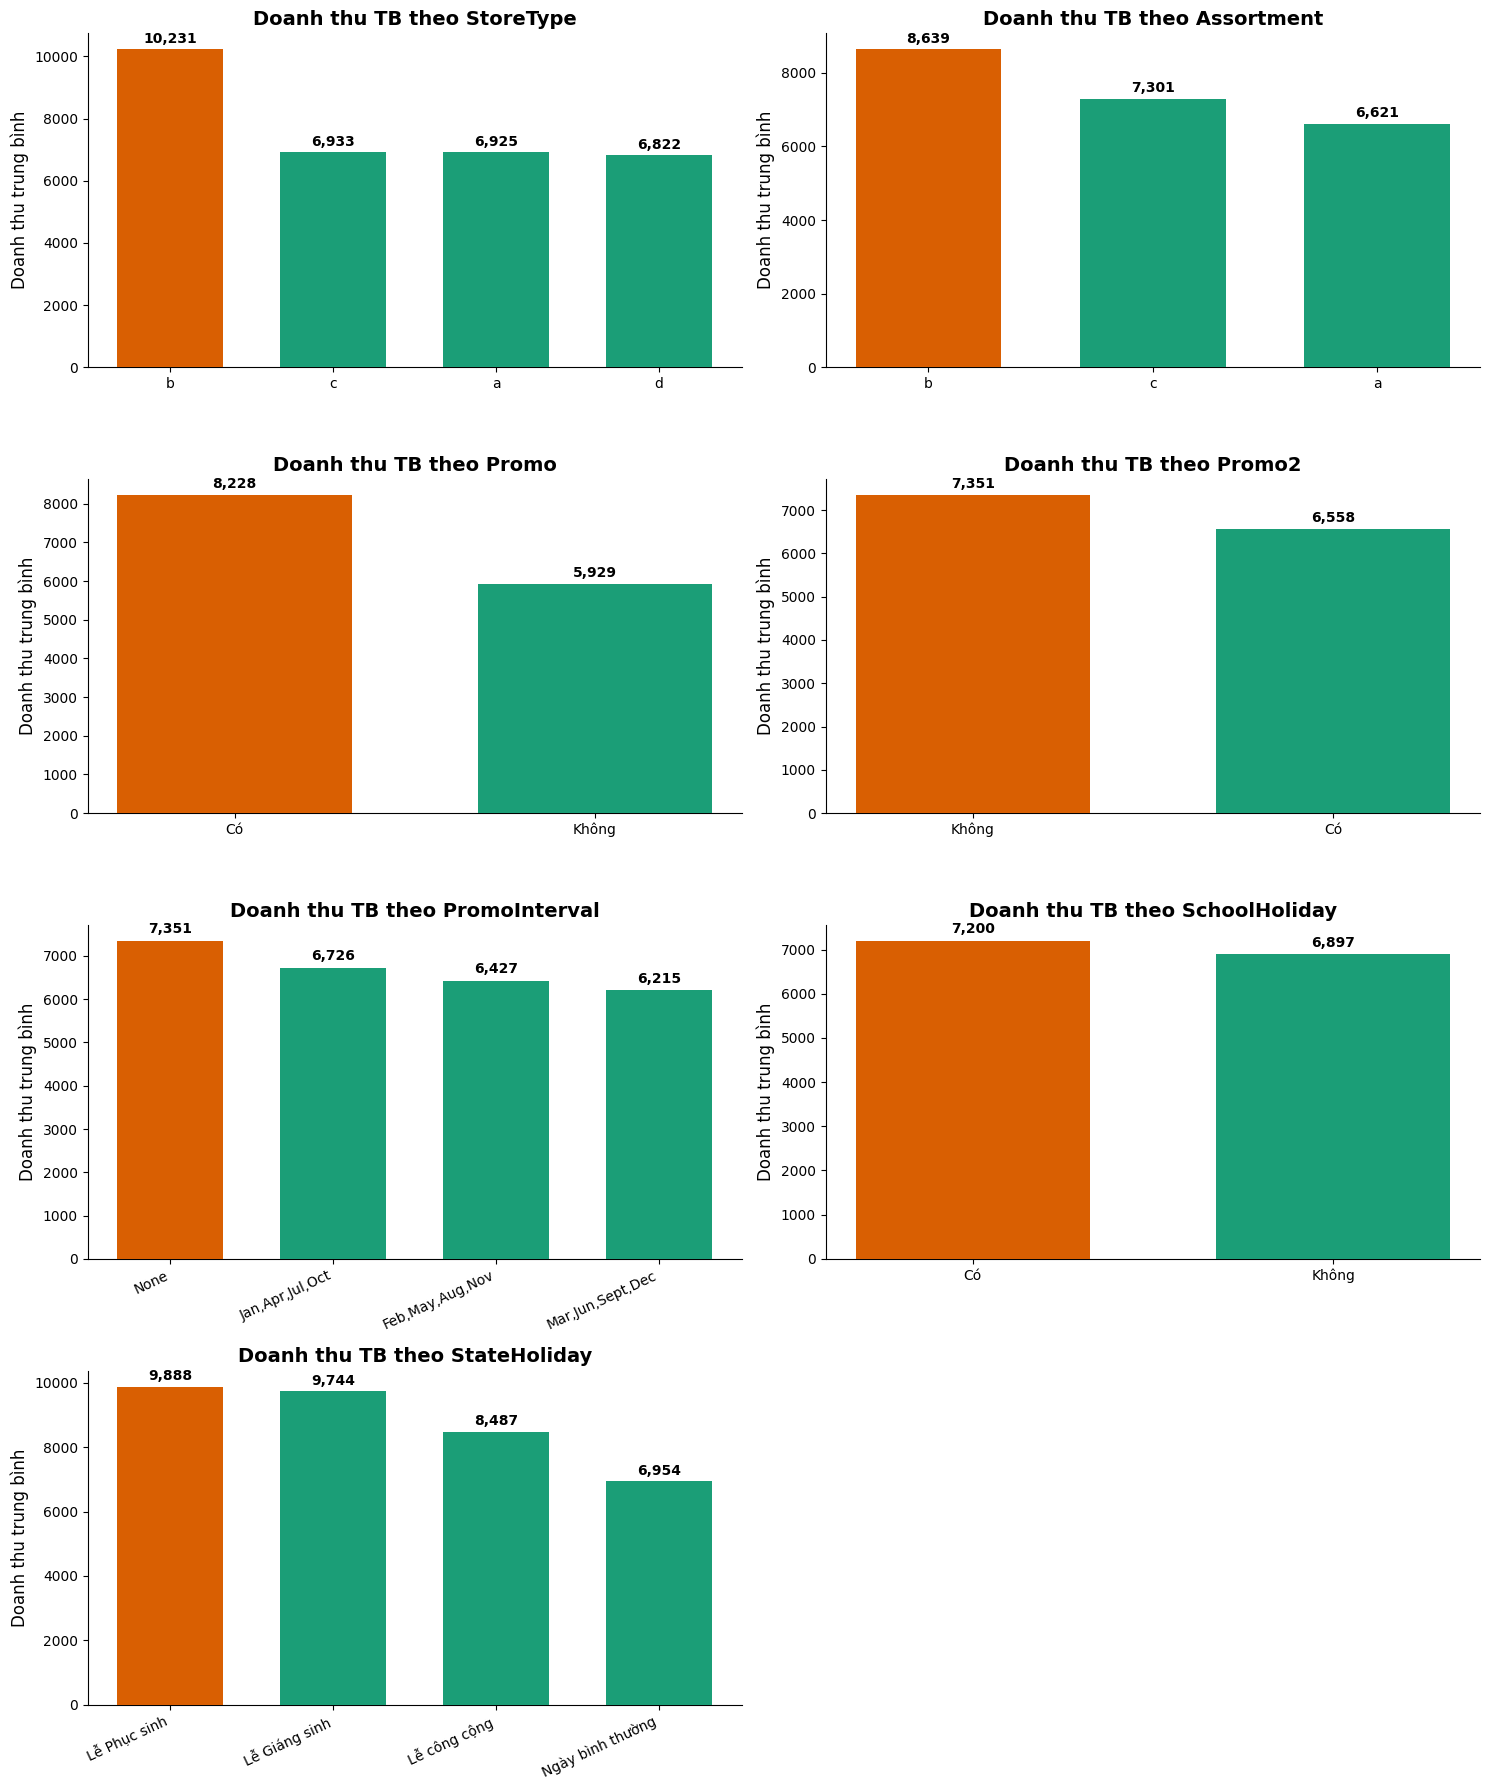

In [61]:
# 1. Định nghĩa Mapping
binary_mapping = {0: 'Không', 1: 'Có'}
state_holiday_mapping = {
    0: 'Ngày bình thường', '0': 'Ngày bình thường',
    'a': 'Lễ công cộng', 'b': 'Lễ Phục sinh', 'c': 'Lễ Giáng sinh'
}

categorical_vars = ['StoreType', 'Assortment', 'Promo', 'Promo2', 'PromoInterval', 'SchoolHoliday', 'StateHoliday']

# 2. Tạo subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.ravel()

# --- CẤU HÌNH NGƯỠNG CẢNH BÁO ---
# Nếu doanh thu trung bình < 25% so với nhóm dẫn đầu -> Tô Hồng (Cảnh báo hiệu suất thấp)
LOW_THRESHOLD_RATIO = 0.25 

for idx, var in enumerate(categorical_vars):
    ax = axes[idx]
    
    # 3. Xử lý dữ liệu
    if var == 'PromoInterval':
        temp_series = df_merged[var].fillna('None')
    else:
        temp_series = df_merged[var]
        
    # Tính doanh thu trung bình và sắp xếp giảm dần để dễ nhìn Top/Bottom
    avg_sales = df_merged.groupby(temp_series)['Sales'].mean().sort_values(ascending=False)
    
    # 4. Logic màu sắc Rossmann (High Performance vs Low Performance)
    max_val = avg_sales.max()
    limit_val = max_val * LOW_THRESHOLD_RATIO
    
    colors = []
    for v in avg_sales.values:
        if v == max_val:
            # Ngôi sao doanh thu -> Cam (#D95F02)
            colors.append(ROSSMANN_COLORS[1]) 
        elif v < limit_val:
            # Hiệu suất kém/Cảnh báo -> Hồng (#E7298A)
            colors.append(ROSSMANN_COLORS[3]) 
        else:
            # Mức trung bình/Ổn định -> Teal (#1B9E77)
            colors.append(ROSSMANN_COLORS[0]) 
    
    # 5. Vẽ Barplot
    ax.bar(range(len(avg_sales)), avg_sales.values, 
           color=colors, width=0.65, zorder=3)
    
    # 6. Xử lý Nhãn trục X
    ax.set_xticks(range(len(avg_sales)))
    
    labels_display = []
    for x in avg_sales.index:
        if var in ['Promo', 'Promo2', 'SchoolHoliday']:
            label = binary_mapping.get(x, str(x))
        elif var == 'StateHoliday':
            label = state_holiday_mapping.get(x, str(x))
        else:
            label = str(x)
        labels_display.append(label)
        
    # Xoay nhãn nếu cần thiết
    if var in ['PromoInterval', 'StateHoliday']:
        ax.set_xticklabels(labels_display, rotation=25, ha='right')
    else:
        ax.set_xticklabels(labels_display, rotation=0, ha='center')

    # 7. Formatting
    ax.set_title(f'Doanh thu TB theo {var}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Doanh thu trung bình', fontsize=12)
    
    # Clean Chart (Bỏ Grid & Spines)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

    # 8. Data Labels
    for i, v in enumerate(avg_sales.values):
        ax.text(i, v + 100, f'{v:,.0f}', 
                ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

# Xóa subplot thừa (vị trí thứ 8 - index 7)
if len(categorical_vars) < 8:
    fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

In [62]:
# Thống kê số lượng cửa hàng mỗi loại, số lượng assortment mỗi loại, và state holiday mỗi loại
store_type_counts = df_store['StoreType'].value_counts()
assortment_counts = df_store['Assortment'].value_counts()
holiday_counts = df_train['StateHoliday'].value_counts()
store_type_counts, assortment_counts, holiday_counts


(StoreType
 a    602
 d    348
 c    148
 b     17
 Name: count, dtype: int64,
 Assortment
 a    593
 c    513
 b      9
 Name: count, dtype: int64,
 StateHoliday
 0    843482
 a       694
 b       145
 c        71
 Name: count, dtype: int64)

1. `StoreType b` có doanh thu trung bình cao nhất so với các loại khác, tuy nhiên loại cửa hàng này chỉ chiếm tỉ lệ rất nhỏ trong tổng số cửa hàng (khoảng 1%) nên cần phân tích thêm để rút ra kết luận chính xác.

2. Cũng tương tự đối với loại `assortment b`, mặc dù có doanh thu trung bình cao nhất nhưng chỉ chiếm tỉ lệ rất nhỏ (khoảng 1%).

3. Trung bình doanh thu và các ngày lễ khá lớn vượt trội so với các ngày không phải lễ hội, nhất là các ngày lễ giáng sinh và lễ phục sinh, tuy nhiên số lượng ngày lễ so với tổng số ngày lại rất nhỏ.

4. Doanh thu khi cửa hàng áp dụng `promo` cao hơn rõ rệt rõ với khi không áp dụng, cho thấy các chương trình khuyến mãi ngắn hạn thực sự có tác động tích cực đến doanh thu của cửa hàng. Tuy nhiên biểu đồ `promo2` cho thấy điều ngược lại, điều này chưa thuyết phục lắm cần phân tích sâu hơn để rút ra kết luận chính xác.

5. Các biến còn lại có doanh thu khá đồng đều giữa các giá trị.

#### Kết luận phân tích 2 biến


<b> 1. Các biến liên quan đến đối thủ </b>
- Các cửa hàng không có thông tin về khoảng cách đối thủ (`CompetitionDistance`) thì cũng đồng thời thiếu thông tin năm và tháng đối thủ mở cửa là hợp lý. Tuy nhiên, khi chỉ thiếu `CompetitionOpenSinceMonth/Year` mà `CompetitionDistance` vẫn có → điều này phản ánh dữ liệu cạnh tranh bị thiếu một phần do không thu thập được thời điểm mở cửa của đối thủ

- Các cửa hàng nằm gần đối thủ lại có doanh thu cao hơn.

<b> 2. Các biến liên quan đến promotion </b>
- Khi `Promo2 = 0`, toàn bộ các biến `Promo2SinceWeek` và `Promo2SinceYear` đều bị missing

- `Promo` (khuyến mãi ngắn hạn) làm tăng doanh thu rất rõ rệt.

- `Promo2` chưa xác định rõ được ảnh hưởng khi có lúc mang lại hiệu quả cao có lúc mang lại hiệu quả thấp.

<b> 3. Insight về doanh thu và khách hàng theo yếu tố thời gian, mùa vụ </b>
- Doanh thu và lượng khách hàng thể hiện mối quan hệ tương đồng rất rõ ràng, điều này hoàn toàn hợp lý vì khách hàng là yếu tố quyết định trực tiếp doanh thu.

- Năm 2015 có doanh thu trung bình tăng nhưng lượng khách trung bình giảm do ít khách hơn nhưng giá trị đơn hàng trung bình cao hơn.

- Doanh thu giảm mạnh vào chủ nhật và tháng 1 và tháng 5.

- Doanh thu tăng cao vào đầu tuần Các tháng cuối năm.


- Doanh thu trung bình ở các ngày lễ lớn hơn so với doanh thu trung bình của các ngày bình thường, đặc biệt là vào lễ phục sinh và giấng sinh.

<b> 4. Doanh thu theo các loại cửa hàng </b>
- `StoreType b` và `Assortment b` có doanh thu cao nhất nhưng cả hai nhóm này chỉ chiếm ~1% dữ liệu.

### <b>Phân tích đa biến</b>

#### Xem xét mối quan hệ của doanh thu theo thời gian theo `StoreType`


C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\719136512.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_data.groupby([x_col, 'StoreType'])[y_col].mean().reset_index()
C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\719136512.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_data.groupby([x_col, 'StoreType'])[y_col].mean().reset_index()
C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\719136512.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observ

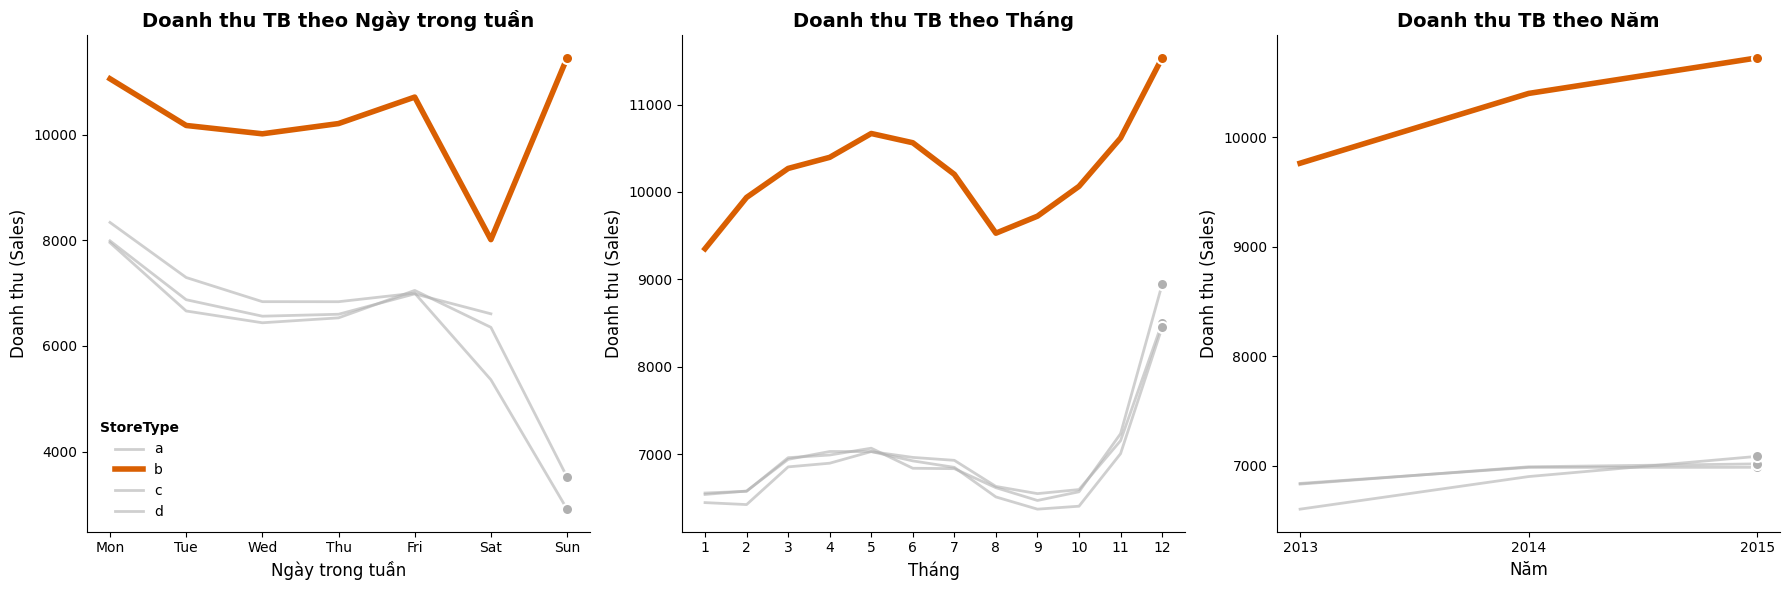

In [63]:
# Vẽ 3 lineplot cho từng StoreType để xem doanh thu theo ngày trong tuần, tháng, năm

# 1. Định nghĩa Palette theo chiến lược "Highlight"
# 'b': Cam (Highlight) - Vì đây là nhóm hiệu suất cao nhất
# Các nhóm khác: Xám nhạt - Để làm nền
custom_palette = {
    'a': '#B0B0B0',         # Xám trung tính
    'b': ROSSMANN_COLORS[1], # CAM (#D95F02) - Highlight
    'c': '#B0B0B0', 
    'd': '#B0B0B0'
}

# Khởi tạo figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- HÀM HỖ TRỢ VẼ LINE PLOT TÙY CHỈNH ---
def plot_storetype_lines(ax, df_data, x_col, y_col, title, xlabel, ylabel, xticks=None, xticklabels=None):
    # Tính toán dữ liệu trung bình
    grouped = df_data.groupby([x_col, 'StoreType'])[y_col].mean().reset_index()
    
    # Lấy danh sách StoreType và sắp xếp để vẽ 'b' sau cùng (nằm đè lên trên)
    store_types = sorted(df_data['StoreType'].unique())
    if 'b' in store_types:
        store_types.remove('b')
        store_types.append('b') # Đưa 'b' xuống cuối danh sách vẽ
        
    for s_type in store_types:
        subset = grouped[grouped['StoreType'] == s_type]
        
        # Cấu hình riêng cho 'b' và nhóm còn lại
        if s_type == 'b':
            color = custom_palette['b']
            width = 4       # Đường to hơn
            zorder = 10     # Nằm lớp trên cùng
            alpha = 1.0
        else:
            color = custom_palette.get(s_type, '#B0B0B0')
            width = 2       # Đường nhỏ hơn
            zorder = 1      # Nằm lớp dưới
            alpha = 0.6
            
        # 1. Vẽ đường (Line)
        ax.plot(subset[x_col], subset[y_col], 
                color=color, linewidth=width, alpha=alpha, zorder=zorder, label=s_type)
        
        # 2. Vẽ Marker ở điểm cuối cùng
        last_x = subset[x_col].iloc[-1]
        last_y = subset[y_col].iloc[-1]
        
        ax.plot(last_x, last_y, marker='o', markersize=8, 
                color=color, markeredgecolor='white', markeredgewidth=1.5, zorder=zorder+1)

    # --- FORMATTING ---
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Xử lý trục X
    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels)
        
    # Legend thủ công (để đảm bảo đúng màu)
    # Chỉ hiện Legend ở biểu đồ đầu tiên cho đỡ rối
    if ax == axes[0]:
        handles, labels = ax.get_legend_handles_labels()
        # Sắp xếp lại legend theo thứ tự a, b, c, d
        order_dict = {label: handle for handle, label in zip(handles, labels)}
        sorted_labels = sorted(order_dict.keys())
        sorted_handles = [order_dict[l] for l in sorted_labels]
        
        legend = ax.legend(sorted_handles, sorted_labels, frameon=False, title='StoreType')
        plt.setp(legend.get_title(), fontweight='bold')

    # Clean Chart
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)


# --- 1. Lineplot theo DayOfWeek ---
plot_storetype_lines(
    axes[0], df_merged, 'DayOfWeek', 'Sales',
    'Doanh thu TB theo Ngày trong tuần', 'Ngày trong tuần', 'Doanh thu (Sales)',
    xticks=range(1, 8),
    xticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

# --- 2. Lineplot theo Month ---
plot_storetype_lines(
    axes[1], df_merged, 'Month', 'Sales',
    'Doanh thu TB theo Tháng', 'Tháng', 'Doanh thu (Sales)',
    xticks=range(1, 13)
)

# --- 3. Lineplot theo Year ---
plot_storetype_lines(
    axes[2], df_merged, 'Year', 'Sales',
    'Doanh thu TB theo Năm', 'Năm', 'Doanh thu (Sales)'
)
# Đảm bảo trục năm là số nguyên
axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

1. Các cửa hàng thường tăng doanh thu rất mạnh vào cuối năm khoảng tháng 11 và 12, đối với các ngày trong tuần các `StoreType a,c,d` đều sụt giảm doanh thu trầm trọng vào ngày chủ nhật còn `StoreType b` lại tăng doanh thu vào ngày chủ nhật nhưng lại sụt giảm sâu vào ngày thứ 7

2. `StoreType b` có doanh thu trung bình luôn luôn cao nhất theo thời gian, tuy nhiên dữ liệu về các loại cửa hàng bị mất cân đối nghiêm trọng khi số cửa hàng `StoreType b` chỉ chiếm khoảng 1% tổng số cửa hàng.

C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\1858007903.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_data.groupby([x_col, 'StoreType'])[y_col].mean().reset_index()
C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\1858007903.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_data.groupby([x_col, 'StoreType'])[y_col].mean().reset_index()
C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\1858007903.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

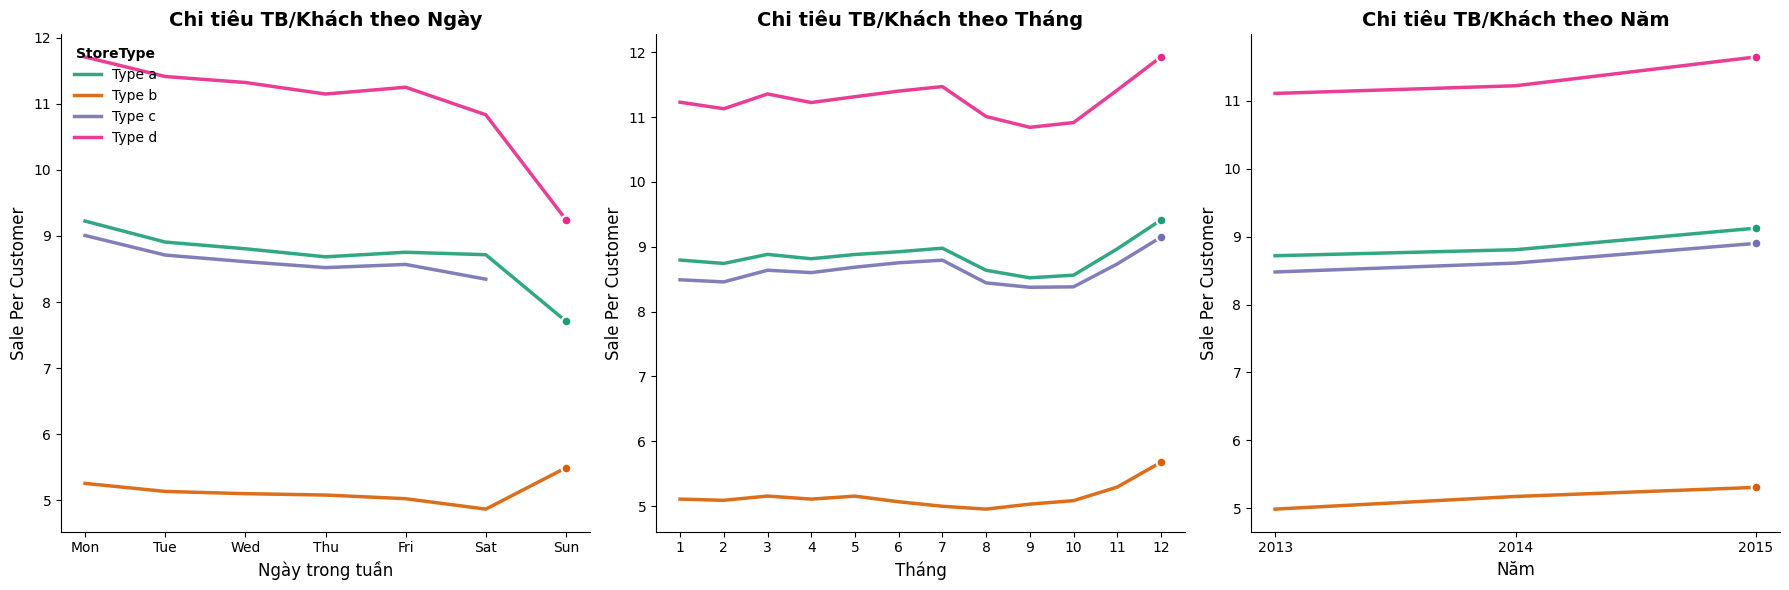

In [64]:
# Vẽ 3 lineplot cho từng StoreType để xem doanh thu theo ngày trong tuần, tháng, năm
# 1. Định nghĩa Mapping màu sắc riêng biệt cho từng StoreType
# Đảm bảo mỗi loại có 1 màu khác nhau trong bộ Palette chuẩn
store_type_colors = {
    'a': ROSSMANN_COLORS[0], # Teal
    'b': ROSSMANN_COLORS[1], # Cam
    'c': ROSSMANN_COLORS[2], # Tím
    'd': ROSSMANN_COLORS[3]  # Hồng
}

# Khởi tạo figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- HÀM VẼ LINEPLOT BÌNH ĐẲNG (EQUAL STYLE) ---
def plot_multiline_equal(ax, df_data, x_col, y_col, title, xlabel, ylabel, xticks=None, xticklabels=None):
    # Tính trung bình
    grouped = df_data.groupby([x_col, 'StoreType'])[y_col].mean().reset_index()
    
    unique_types = sorted(df_data['StoreType'].unique())
        
    for s_type in unique_types:
        subset = grouped[grouped['StoreType'] == s_type]
        
        # Lấy màu theo mapping
        color = store_type_colors.get(s_type, 'grey')
            
        # 1. Vẽ đường (Line) - Không marker, độ đậm như nhau
        ax.plot(subset[x_col], subset[y_col], 
                color=color, linewidth=2.5, alpha=0.9, label=f'Type {s_type}')
        
        # 2. Vẽ Marker ở điểm cuối cùng
        last_x = subset[x_col].iloc[-1]
        last_y = subset[y_col].iloc[-1]
        
        ax.plot(last_x, last_y, marker='o', markersize=7, 
                color=color, markeredgecolor='white', markeredgewidth=1.5)

    # --- FORMATTING ---
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Xử lý trục X
    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels)
        
    # Legend: Hiện rõ cả 4 loại
    if ax == axes[0]:
        legend = ax.legend(frameon=False, title='StoreType', loc='upper left')
        plt.setp(legend.get_title(), fontweight='bold')
        # Chỉnh màu chữ legend nếu cần (mặc định matplotlib đã tự lo phần này)

    # Clean Chart
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# --- 1. DayOfWeek ---
plot_multiline_equal(
    axes[0], df_merged, 'DayOfWeek', 'SalePerCustomer',
    'Chi tiêu TB/Khách theo Ngày', 
    'Ngày trong tuần', 'Sale Per Customer',
    xticks=range(1, 8),
    xticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

# --- 2. Month ---
plot_multiline_equal(
    axes[1], df_merged, 'Month', 'SalePerCustomer',
    'Chi tiêu TB/Khách theo Tháng', 
    'Tháng', 'Sale Per Customer',
    xticks=range(1, 13)
)

# --- 3. Year ---
plot_multiline_equal(
    axes[2], df_merged, 'Year', 'SalePerCustomer',
    'Chi tiêu TB/Khách theo Năm', 
    'Năm', 'Sale Per Customer'
)
axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

_Xét theo doanh thu trên từng khách hàng thì `StoreType b` lại thấp nhất mặc dù ở trên rất cao, cửa hàng `StoreType d` cao nhất. Có lẽ do số lượng khách hàng của các loại cửa hàng??_


In [65]:
# Lọc dữ liệu: chỉ lấy những ngày mở cửa và có doanh thu > 0
df_open = df_merged[(df_merged['Open'] == 1) & (df_merged['Sales'] > 0)].copy()

# Tính cột SalePerCustomer (Doanh thu trên mỗi khách)
df_open['SalePerCustomer'] = df_open['Sales'] / df_open['Customers']

# Gom nhóm theo StoreType và tính toán các chỉ số
stats = (
    df_open.groupby('StoreType', observed=False).agg({
        'Store': 'nunique',
        'Sales': 'mean',
        'Customers': 'mean',
        'SalePerCustomer': 'mean'
    })
    .round(2)
    .rename(columns={
        'Store': 'Số lượng Store',
        'Sales': 'Doanh thu TB/ngày',
        'Customers': 'Số khách TB/ngày',
        'SalePerCustomer': 'Giá trị đơn TB/khách'
    })
)
stats

,Số lượng Store,Doanh thu TB/ngày,Số khách TB/ngày,Giá trị đơn TB/khách
StoreType,,,,
a,602,6925.70,795.42,8.85
b,17,10233.38,2022.21,5.13
c,148,6933.13,815.54,8.63
d,348,6822.30,606.35,11.28


1. Thật sự vậy, cửa hàng `StoreType b` đúng là có số lượng khách trung bình ngày doanh thu trung bình ngày nhiều nhất nhưng số lượng store lại ít nhất nên tổng doanh thu sẽ ít nhất nhưng performance rất tốt, đây là loại cửa hàng hiếm vì số lượng store ít và khách hàng vào mua đông nhưng mua với giá trị ít

2. Cửa hàng `StoreType d` ngược lại có doanh thu và số khách trung bình ngày ít nhất nhưng sale per customer lại vượt trội nhất, đây là loại cửa hàng có lẽ là bán hàng hóa có giá trị cao nhất nên mới ít khách và sale per customer cao

3. Cửa hàng `StoreType a` và `StoreType c` khá giống nhau có lẽ đều bán các loại hàng tiêu dùng phổ biến

#### Xem xét mối quan hệ giữa doanh thu và biến `promotion` theo thời gian và theo loại cửa hàng


C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\3839489952.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = sales_positive.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack().reindex(index=store_types)


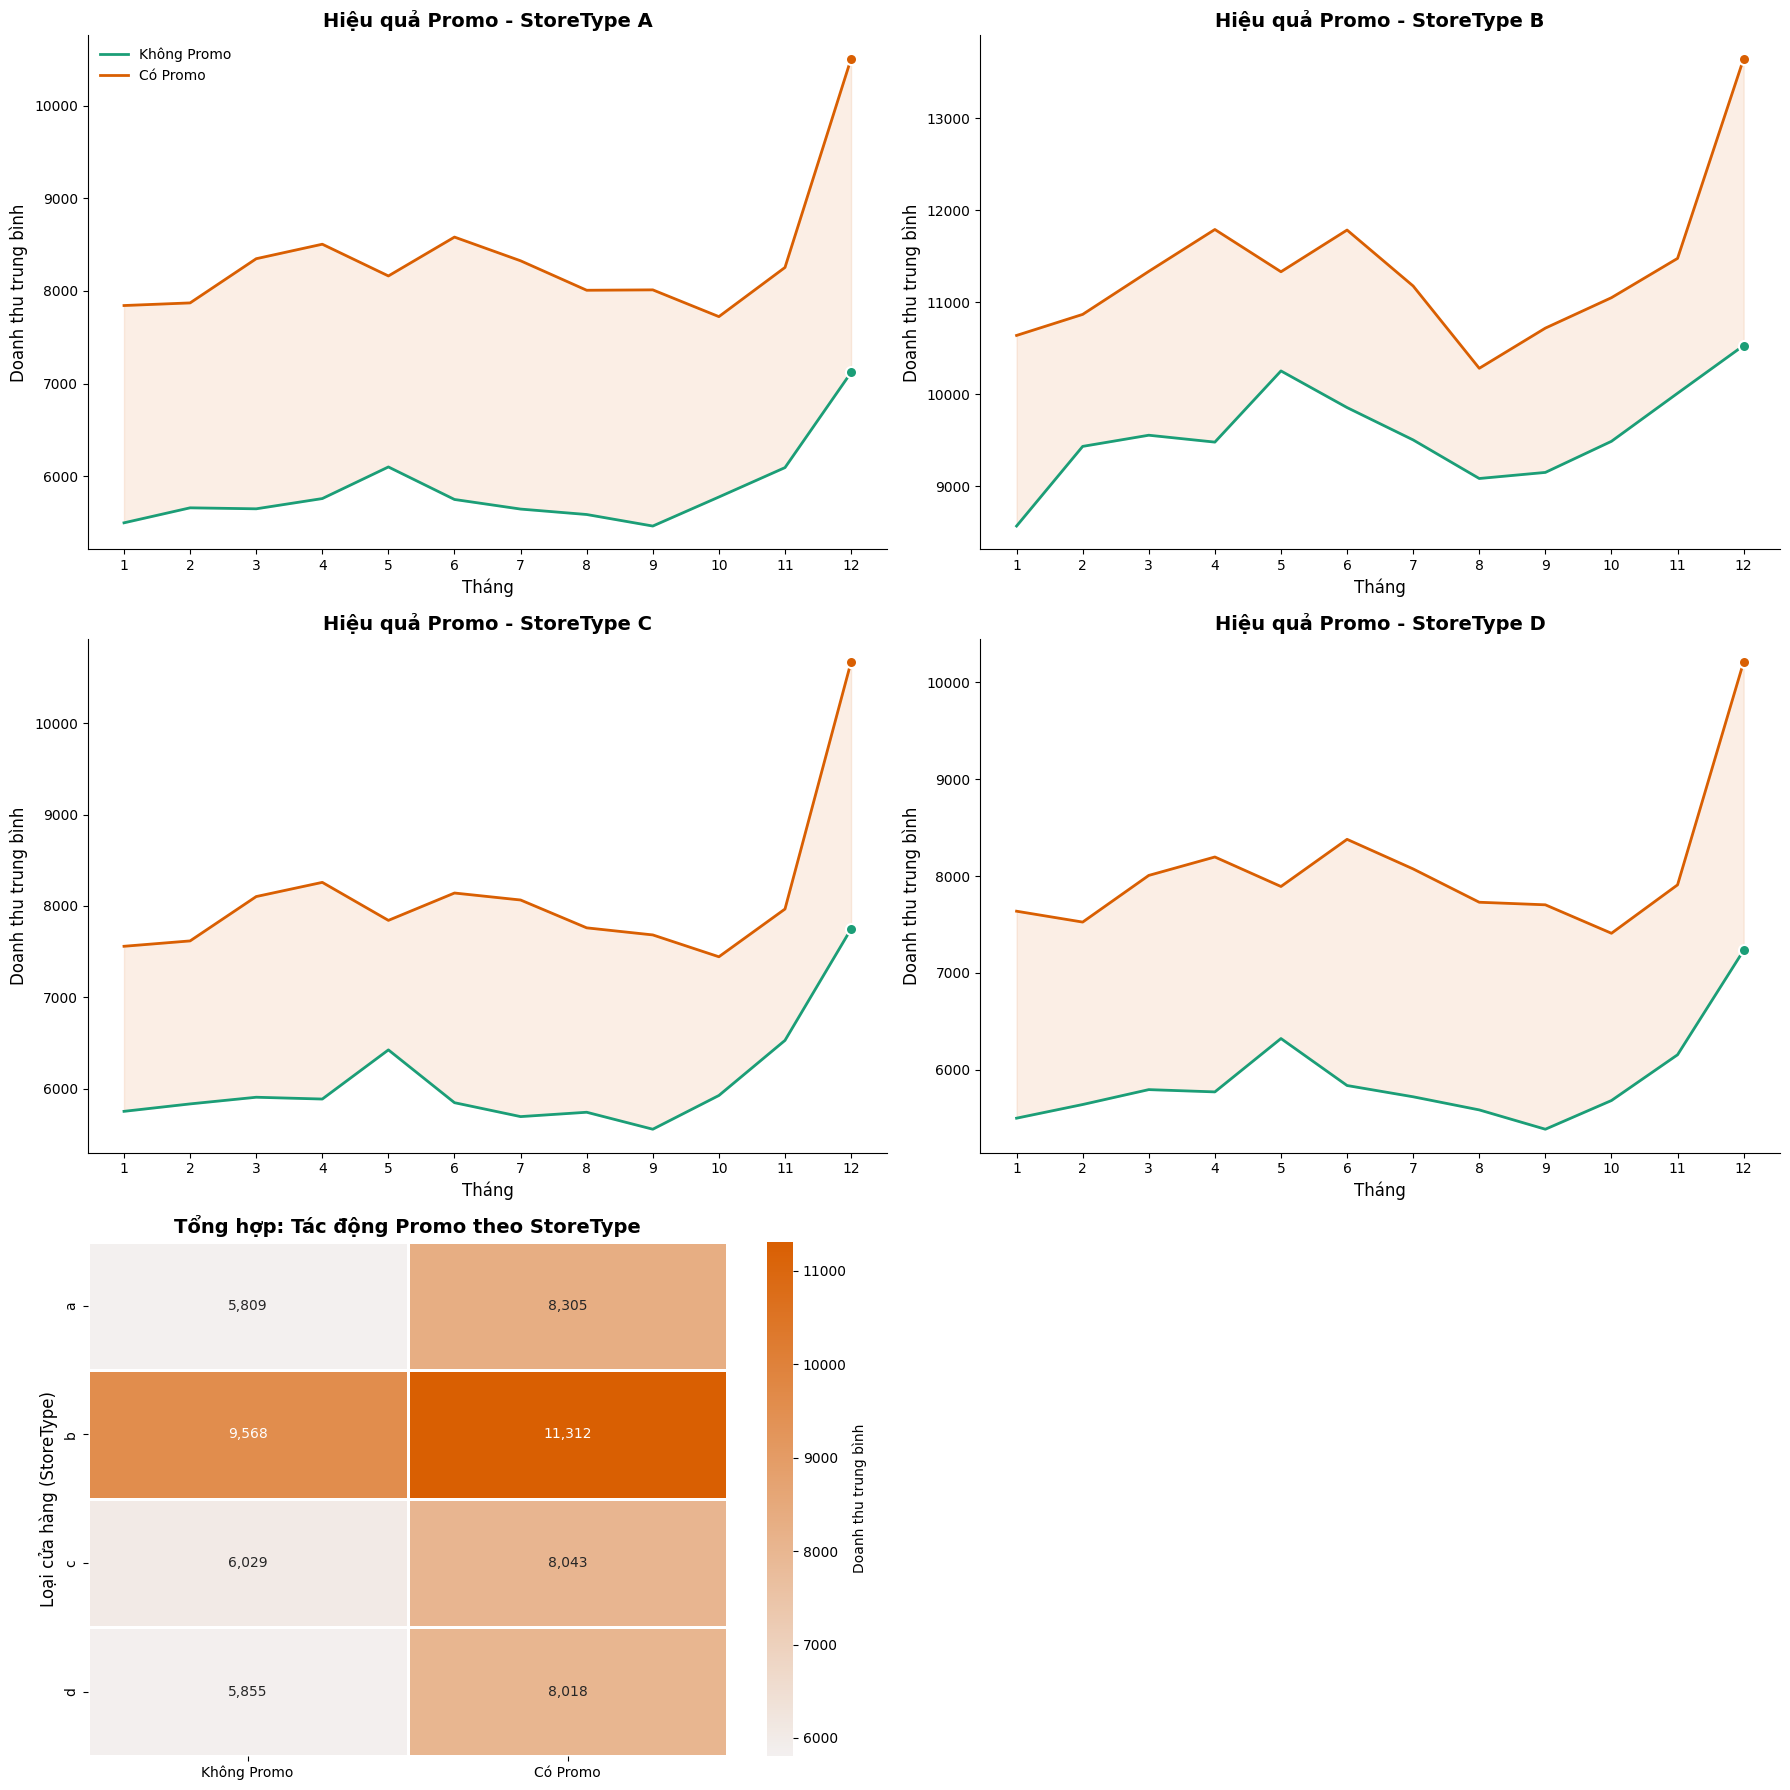

In [66]:
# Cấu hình màu sắc
color_no_promo = ROSSMANN_COLORS[0] # Teal: Cơ sở
color_promo = ROSSMANN_COLORS[1]    # Cam: Kích cầu/Nổi bật

store_types = ['a', 'b', 'c', 'd']
sales_positive = df_merged[df_merged['Sales'] > 0]

# Khởi tạo figure
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.ravel()

# --- 1. VẼ 4 BIỂU ĐỒ ĐƯỜNG (LINE CHARTS) ---
for idx, store_type in enumerate(store_types):
    ax = axes[idx]
    
    # Lọc dữ liệu
    df_store_type = sales_positive[sales_positive['StoreType'] == store_type]
    
    if df_store_type.empty:
        ax.set_visible(False)
        continue
    
    # Tính toán
    monthly_no = df_store_type[df_store_type['Promo'] == 0].groupby('Month')['Sales'].mean()
    monthly_yes = df_store_type[df_store_type['Promo'] == 1].groupby('Month')['Sales'].mean()
    
    # Đảm bảo index khớp nhau để vẽ fill_between
    common_index = monthly_no.index.intersection(monthly_yes.index)
    monthly_no = monthly_no.loc[common_index]
    monthly_yes = monthly_yes.loc[common_index]
    
    # --- VẼ LINE NO PROMO (TEAL) ---
    ax.plot(monthly_no.index, monthly_no.values, 
            color=color_no_promo, linewidth=2, label='Không Promo')
    # Marker điểm cuối
    ax.plot(monthly_no.index[-1], monthly_no.values[-1], 
            marker='o', markersize=8, color=color_no_promo, markeredgecolor='white', markeredgewidth=1.5)
            
    # --- VẼ LINE WITH PROMO (CAM) ---
    ax.plot(monthly_yes.index, monthly_yes.values, 
            color=color_promo, linewidth=2, label='Có Promo')
    # Marker điểm cuối
    ax.plot(monthly_yes.index[-1], monthly_yes.values[-1], 
            marker='o', markersize=8, color=color_promo, markeredgecolor='white', markeredgewidth=1.5)
            
    # --- TÔ VÙNG CHÊNH LỆCH (VISUALIZE THE LIFT) ---
    ax.fill_between(monthly_yes.index, monthly_no.values, monthly_yes.values, 
                    color=color_promo, alpha=0.1) # Màu cam nhạt
    
    # --- FORMATTING ---
    ax.set_title(f'Hiệu quả Promo - StoreType {store_type.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tháng', fontsize=12)
    ax.set_ylabel('Doanh thu trung bình', fontsize=12)
    ax.set_xticks(range(1, 13))
    
    # Clean Chart
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # Legend chỉ hiện ở biểu đồ đầu tiên
    if idx == 0:
        ax.legend(frameon=False, loc='upper left')


# --- 2. VẼ HEATMAP TỔNG HỢP ---
heatmap_ax = axes[4]
heatmap_data = sales_positive.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack().reindex(index=store_types)

# Đổi tên cột cho dễ hiểu
heatmap_data.columns = ['Không Promo', 'Có Promo']

# Dùng sns.light_palette để tạo gradient màu Cam đồng bộ với line chart
sns.heatmap(heatmap_data, annot=True, fmt=',.0f', 
            cmap=sns.light_palette(color_promo, as_cmap=True), # Gradient Cam
            cbar_kws={'label': 'Doanh thu trung bình'}, 
            linewidths=1, linecolor='white', # Viền trắng cho sạch
            ax=heatmap_ax)

heatmap_ax.set_title('Tổng hợp: Tác động Promo theo StoreType', fontsize=14, fontweight='bold')
heatmap_ax.set_ylabel('Loại cửa hàng (StoreType)', fontsize=12)
heatmap_ax.set_xlabel('') # Bỏ label trục X cho gọn

# Ẩn subplot thừa
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_16156\4184975597.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = sales_positive.groupby(['StoreType', 'Promo2'])['Sales'].mean().unstack().reindex(index=store_types)


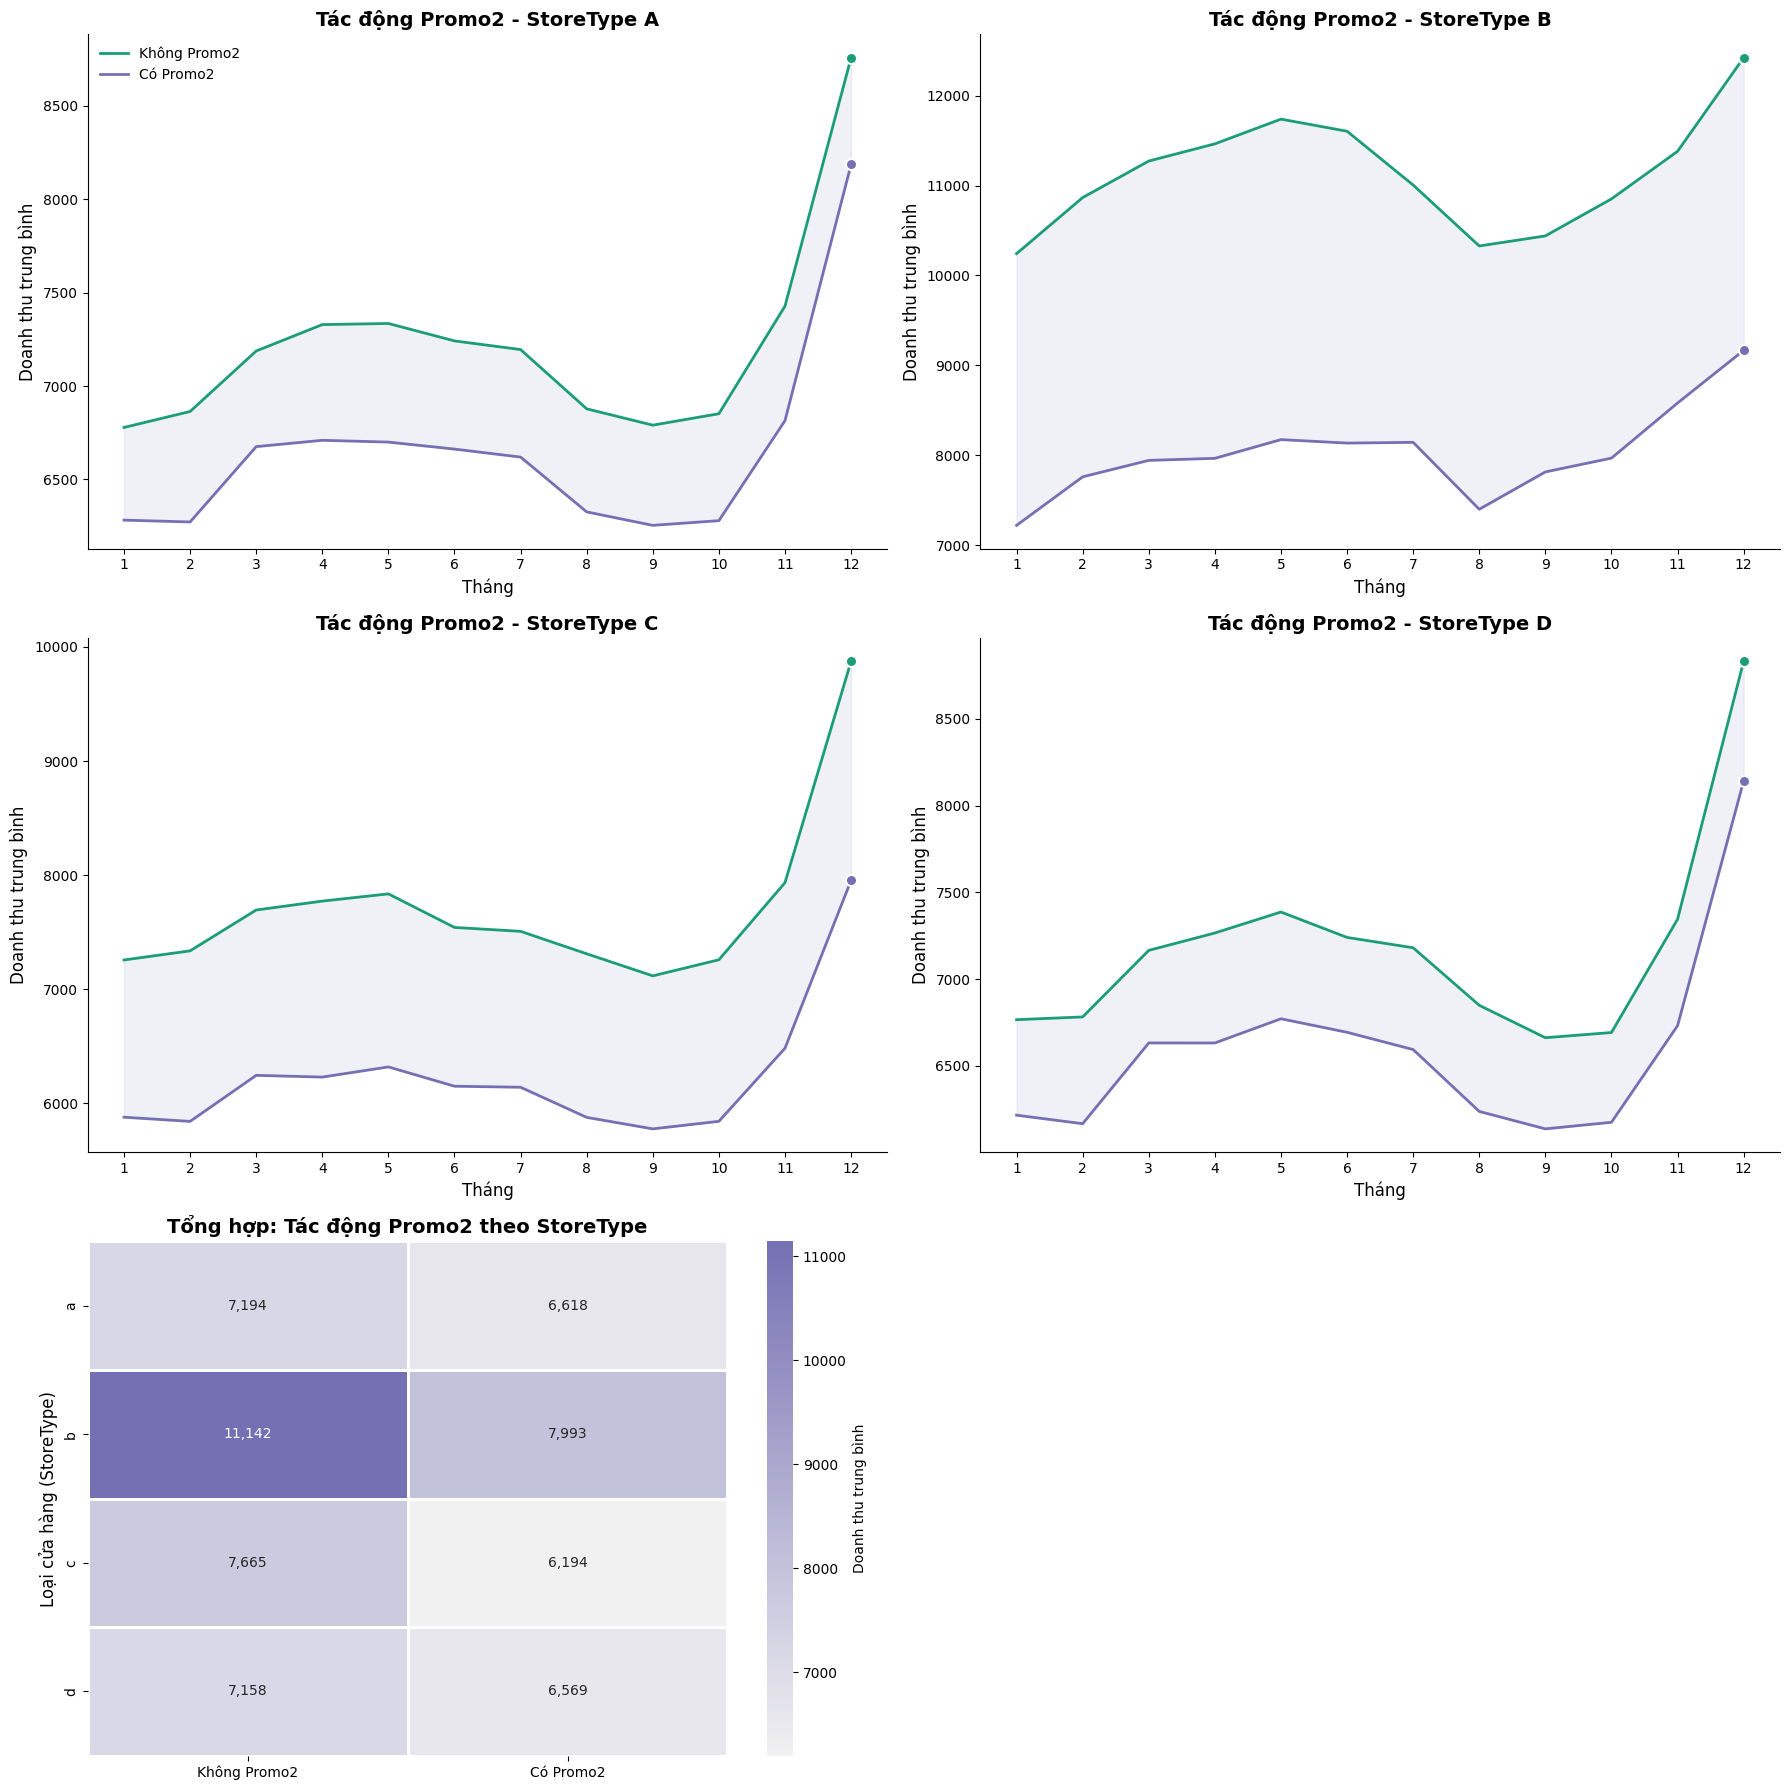

In [67]:
# Cấu hình màu sắc đặc thù cho Promo2
color_no_promo2 = ROSSMANN_COLORS[0] # Teal: Cơ sở
color_promo2 = ROSSMANN_COLORS[2]    # Tím: Bổ trợ/Dài hạn

store_types = ['a', 'b', 'c', 'd']
sales_positive = df_merged[df_merged['Sales'] > 0]

# Khởi tạo figure
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.ravel()

# --- 1. VẼ 4 BIỂU ĐỒ ĐƯỜNG (LINE CHARTS) ---
for idx, store_type in enumerate(store_types):
    ax = axes[idx]
    
    # Lọc dữ liệu
    df_store_type = sales_positive[sales_positive['StoreType'] == store_type]
    
    if df_store_type.empty:
        ax.set_visible(False)
        continue
    
    # Tính toán
    monthly_no = df_store_type[df_store_type['Promo2'] == 0].groupby('Month')['Sales'].mean()
    monthly_yes = df_store_type[df_store_type['Promo2'] == 1].groupby('Month')['Sales'].mean()
    
    # Tìm index chung để tô màu vùng chênh lệch
    common_index = monthly_no.index.intersection(monthly_yes.index)
    
    # --- VẼ LINE NO PROMO2 (TEAL) ---
    if not monthly_no.empty:
        ax.plot(monthly_no.index, monthly_no.values, 
                color=color_no_promo2, linewidth=2, label='Không Promo2')
        # Marker điểm cuối
        ax.plot(monthly_no.index[-1], monthly_no.values[-1], 
                marker='o', markersize=8, color=color_no_promo2, markeredgecolor='white', markeredgewidth=1.5)
            
    # --- VẼ LINE WITH PROMO2 (TÍM) ---
    if not monthly_yes.empty:
        ax.plot(monthly_yes.index, monthly_yes.values, 
                color=color_promo2, linewidth=2, label='Có Promo2')
        # Marker điểm cuối
        ax.plot(monthly_yes.index[-1], monthly_yes.values[-1], 
                marker='o', markersize=8, color=color_promo2, markeredgecolor='white', markeredgewidth=1.5)
            
    # --- TÔ VÙNG CHÊNH LỆCH ---
    if not common_index.empty:
        ax.fill_between(common_index, 
                        monthly_no.loc[common_index], 
                        monthly_yes.loc[common_index], 
                        color=color_promo2, alpha=0.1) # Màu tím nhạt
    
    # --- FORMATTING ---
    ax.set_title(f'Tác động Promo2 - StoreType {store_type.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tháng', fontsize=12)
    ax.set_ylabel('Doanh thu trung bình', fontsize=12)
    ax.set_xticks(range(1, 13))
    
    # Clean Chart
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    if idx == 0:
        ax.legend(frameon=False, loc='best')

# --- 2. VẼ HEATMAP TỔNG HỢP ---
heatmap_ax = axes[4]
heatmap_data = sales_positive.groupby(['StoreType', 'Promo2'])['Sales'].mean().unstack().reindex(index=store_types)
heatmap_data.columns = ['Không Promo2', 'Có Promo2']

# Dùng sns.light_palette với màu Tím (color_promo2) để đồng bộ
sns.heatmap(heatmap_data, annot=True, fmt=',.0f', 
            cmap=sns.light_palette(color_promo2, as_cmap=True), # Gradient Tím
            cbar_kws={'label': 'Doanh thu trung bình'}, 
            linewidths=1, linecolor='white',
            ax=heatmap_ax)

heatmap_ax.set_title('Tổng hợp: Tác động Promo2 theo StoreType', fontsize=14, fontweight='bold')
heatmap_ax.set_ylabel('Loại cửa hàng (StoreType)', fontsize=12)
heatmap_ax.set_xlabel('')

# Ẩn subplot thừa
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

1. Loại cửa hàng `StoreType b` luôn có doanh thu cao nhất khi áp dụng cả 2 loại promotion `promo` và `promo2`

2. Xu hướng biến động doanh thu ở cả 2 biểu đồ của 2 biến `promo` và `promo2` tương đối giống nhau, tuy nhiên ở biểu đồ `promo` thì việc áp dụng mang lại doanh thu cao hơn rõ rệt so với không áp dụng, trong khi ở biểu đồ `promo2` thì doanh thu khi áp dụng `promo2` lại thấp hơn so với không áp dụng. Điều này cho thấy các biến promotion thật sự cần được phân tích sâu hơn để hiểu được nguyên nhân đằng sau.

#### Xem xét mối quan hệ giữa doanh thu và biến `competition distance` theo thời gian và theo loại cửa hàng


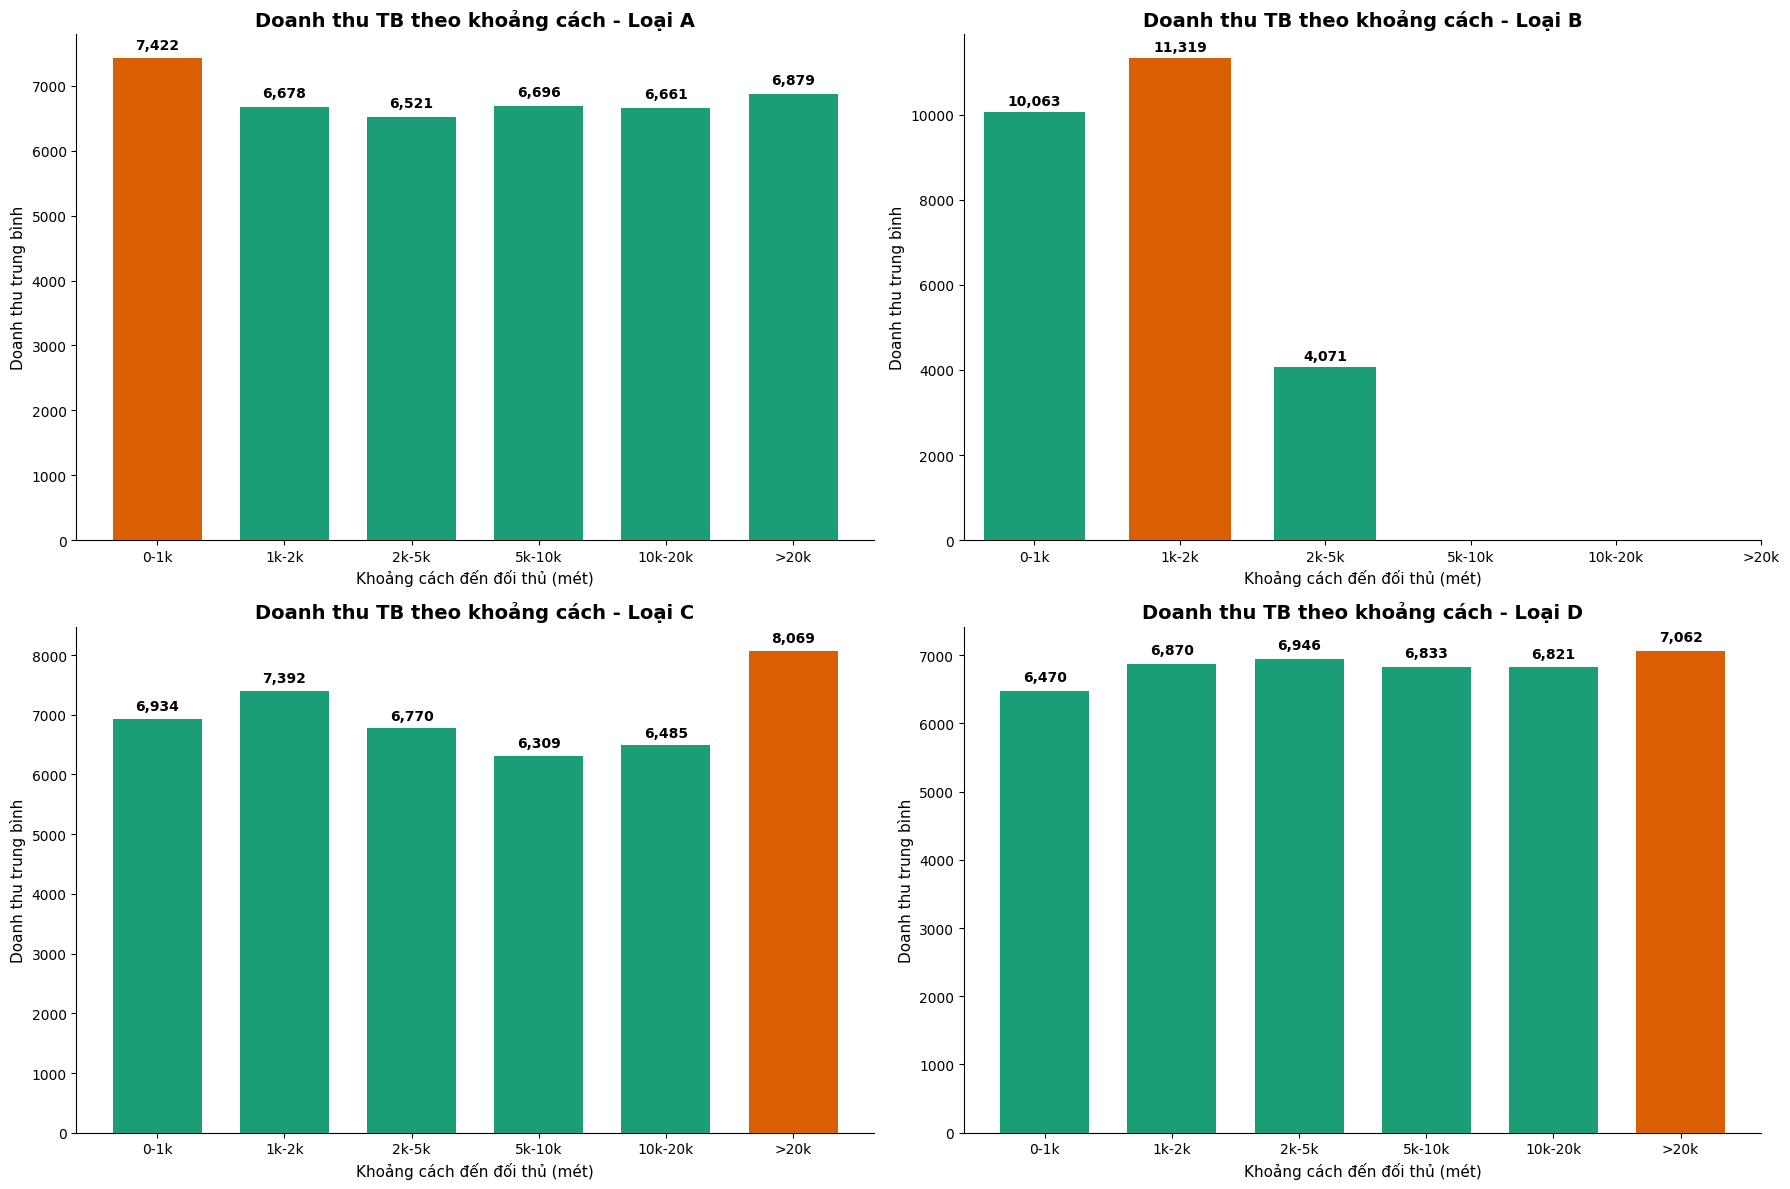

In [68]:
# Khởi tạo figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

store_types = ['a', 'b', 'c', 'd']

# Định nghĩa bins và labels chuẩn
bins_list = [0, 1000, 2000, 5000, 10000, 20000, 80000]
labels_list = ['0-1k', '1k-2k', '2k-5k', '5k-10k', '10k-20k', '>20k']

for idx, store_type in enumerate(store_types):
    ax = axes[idx]
    
    # 1. Lọc dữ liệu & Tạo bản sao để tránh SettingWithCopyWarning
    df_store_type = df_merged[(df_merged['StoreType'] == store_type) & (df_merged['Sales'] > 0)].copy()
    
    if df_store_type.empty:
        ax.set_visible(False)
        continue

    # 2. Phân nhóm khoảng cách (Binning)
    df_store_type['CompDistanceBin'] = pd.cut(
        df_store_type['CompetitionDistance'], 
        bins=bins_list, 
        labels=labels_list
    )
    
    # 3. Tính doanh thu trung bình
    # observed=False để đảm bảo tính toán ngay cả khi bin rỗng (future proof)
    avg_sales_by_distance = df_store_type.groupby('CompDistanceBin', observed=False)['Sales'].mean()
    
    # 4. Logic màu sắc Rossmann: Highlight "Khoảng cách vàng" (Doanh thu cao nhất)
    max_val = avg_sales_by_distance.max()
    colors = []
    for v in avg_sales_by_distance.values:
        if v == max_val:
            colors.append(ROSSMANN_COLORS[1]) # Cam: Sweet Spot (Hiệu quả nhất)
        else:
            colors.append(ROSSMANN_COLORS[0]) # Teal: Các khoảng cách khác
    
    # 5. Vẽ Bar Chart
    ax.bar(range(len(avg_sales_by_distance)), avg_sales_by_distance.values, 
           color=colors, width=0.7, zorder=3)
    
    # 6. Formatting
    ax.set_title(f'Doanh thu TB theo khoảng cách - Loại {store_type.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Khoảng cách đến đối thủ (mét)', fontsize=11)
    ax.set_ylabel('Doanh thu trung bình', fontsize=11)
    
    # Xử lý trục X
    ax.set_xticks(range(len(avg_sales_by_distance)))
    ax.set_xticklabels(avg_sales_by_distance.index, rotation=0, ha='center') # Xoay 0 độ cho dễ đọc vì label ngắn
    
    # Clean Chart
    ax.grid(False) # Tắt grid dọc/ngang để sạch mắt
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # 7. Data Labels
    for i, v in enumerate(avg_sales_by_distance.values):
        # Chỉ hiện số nếu có dữ liệu (>0)
        if pd.notna(v) and v > 0:
            ax.text(i, v + 100, f'{v:,.0f}', 
                    ha='center', va='bottom', 
                    fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

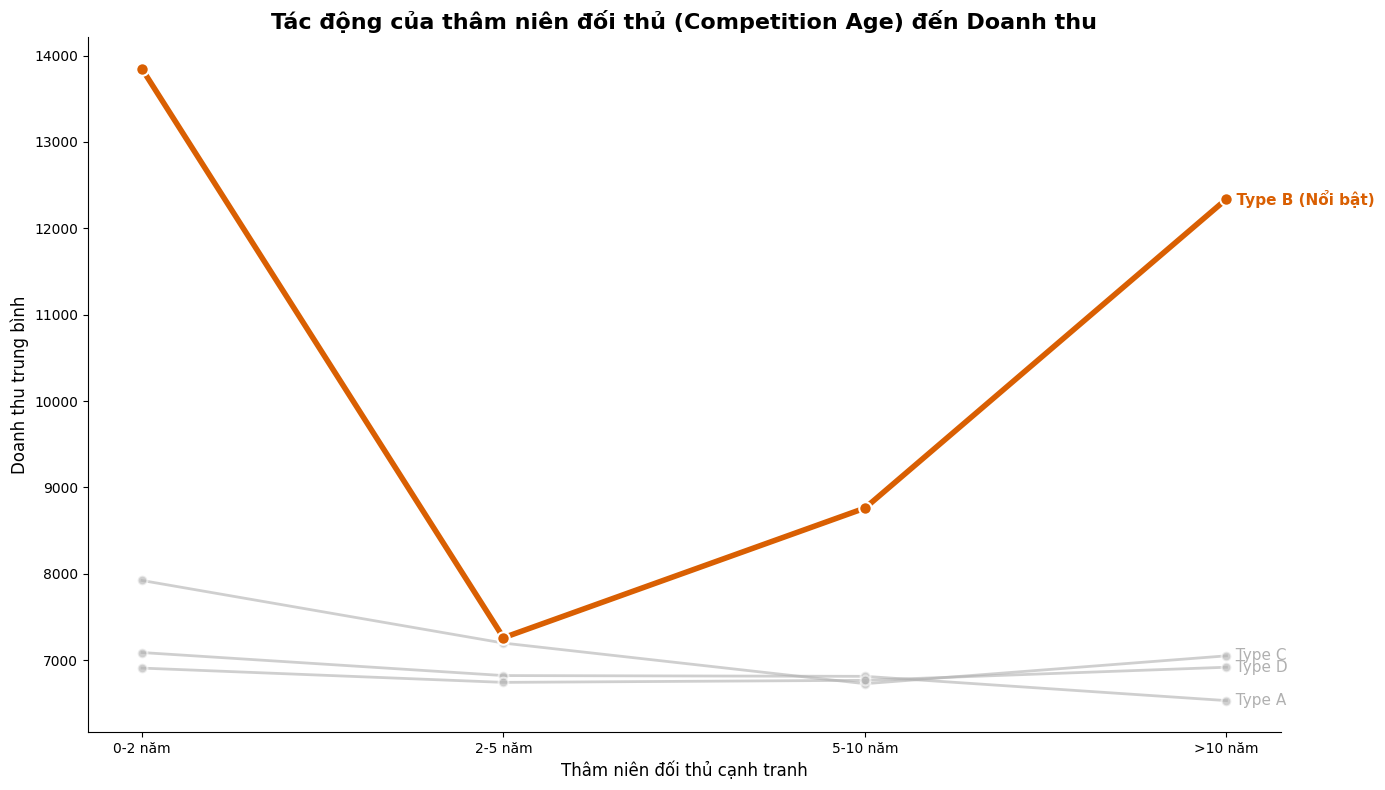

In [69]:
# 1. Chuẩn bị dữ liệu
df_comp = df_merged[df_merged['Sales'] > 0].copy()

df_comp['CompetitionAge'] = df_comp['Year'] - df_comp['CompetitionOpenSinceYear']
df_comp.loc[df_comp['CompetitionAge'] < 0, 'CompetitionAge'] = -1
df_comp['CompetitionAge'] = df_comp['CompetitionAge'].fillna(-1)

# Tạo bins
df_comp['CompAgeGroup'] = pd.cut(df_comp['CompetitionAge'], 
                                 bins=[0, 2, 5, 10, 100], 
                                 labels=['0-2 năm', '2-5 năm', '5-10 năm', '>10 năm'],
                                 include_lowest=True)

# Tính toán
avg_sales_by_comp_age = df_comp.groupby(['StoreType', 'CompAgeGroup'], observed=False)['Sales'].mean().reset_index()

# 2. Vẽ biểu đồ theo phong cách Spotlight 'b'
fig, ax = plt.subplots(figsize=(14, 8))

store_types = sorted(df_comp['StoreType'].unique())
# Đưa 'b' xuống cuối danh sách để vẽ sau cùng (nằm đè lên các đường khác)
if 'b' in store_types:
    store_types.remove('b')
    store_types.append('b')

for store_type in store_types:
    data = avg_sales_by_comp_age[avg_sales_by_comp_age['StoreType'] == store_type]
    
    # Bỏ qua nếu không có dữ liệu
    if data['Sales'].isna().all():
        continue
    
    # --- LOGIC HIGHLIGHT 'b' ---
    if store_type == 'b':
        # Highlight: Màu Cam (#D95F02), đậm, nổi bật
        color = ROSSMANN_COLORS[1] 
        linewidth = 4
        alpha = 1.0
        zorder = 10
        label_text = f"Type B (Nổi bật)"
        marker_size = 9
    else:
        # Background: Màu Xám (#B0B0B0), mờ, làm nền
        color = '#B0B0B0'
        linewidth = 2
        alpha = 0.6
        zorder = 1
        label_text = f"Type {store_type.upper()}"
        marker_size = 7
    
    # Vẽ Line + Marker
    ax.plot(data['CompAgeGroup'], data['Sales'], 
            marker='o', linewidth=linewidth, markersize=marker_size,
            color=color, alpha=alpha, zorder=zorder,
            markeredgecolor='white', markeredgewidth=1.5)

    # Label trực tiếp tại điểm cuối cùng
    last_point = data.dropna().iloc[-1]
    
    # Nếu là 'b' thì in đậm chữ
    fontweight = 'bold' if store_type == 'b' else 'normal'
    
    ax.text(last_point['CompAgeGroup'], last_point['Sales'], 
            f"  {label_text}", 
            color=color, va='center', fontweight=fontweight, fontsize=11)

# 3. Formatting
ax.set_title('Tác động của thâm niên đối thủ (Competition Age) đến Doanh thu', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Thâm niên đối thủ cạnh tranh', fontsize=12)
ax.set_ylabel('Doanh thu trung bình', fontsize=12)

# Clean Chart
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()

1. Ảnh hưởng của khoảng cách cửa hàng đối thủ đến doanh thu của các loại cửa hàng theo thời gian khá đồng đều, chưa rút ra được nhiều kết luận tuy nhiên việc các cửa hàng có đối thủ ở gần có doanh thu cao hơn so với đối thủ ở xa đã phân tích ở bước phân tích 2 biến cần được làm rõ hơn
2. Thâm niên đối thủ thể hiện ảnh hưởng rõ rệt nhất đến cửa hàng loại b, cần khám phá sâu hơn câu chuyện đằng sau 

#### Ảnh hưởng của `StateHoliday` và `SchoolHoliday` với doanh thu theo từng loại cửa hàng


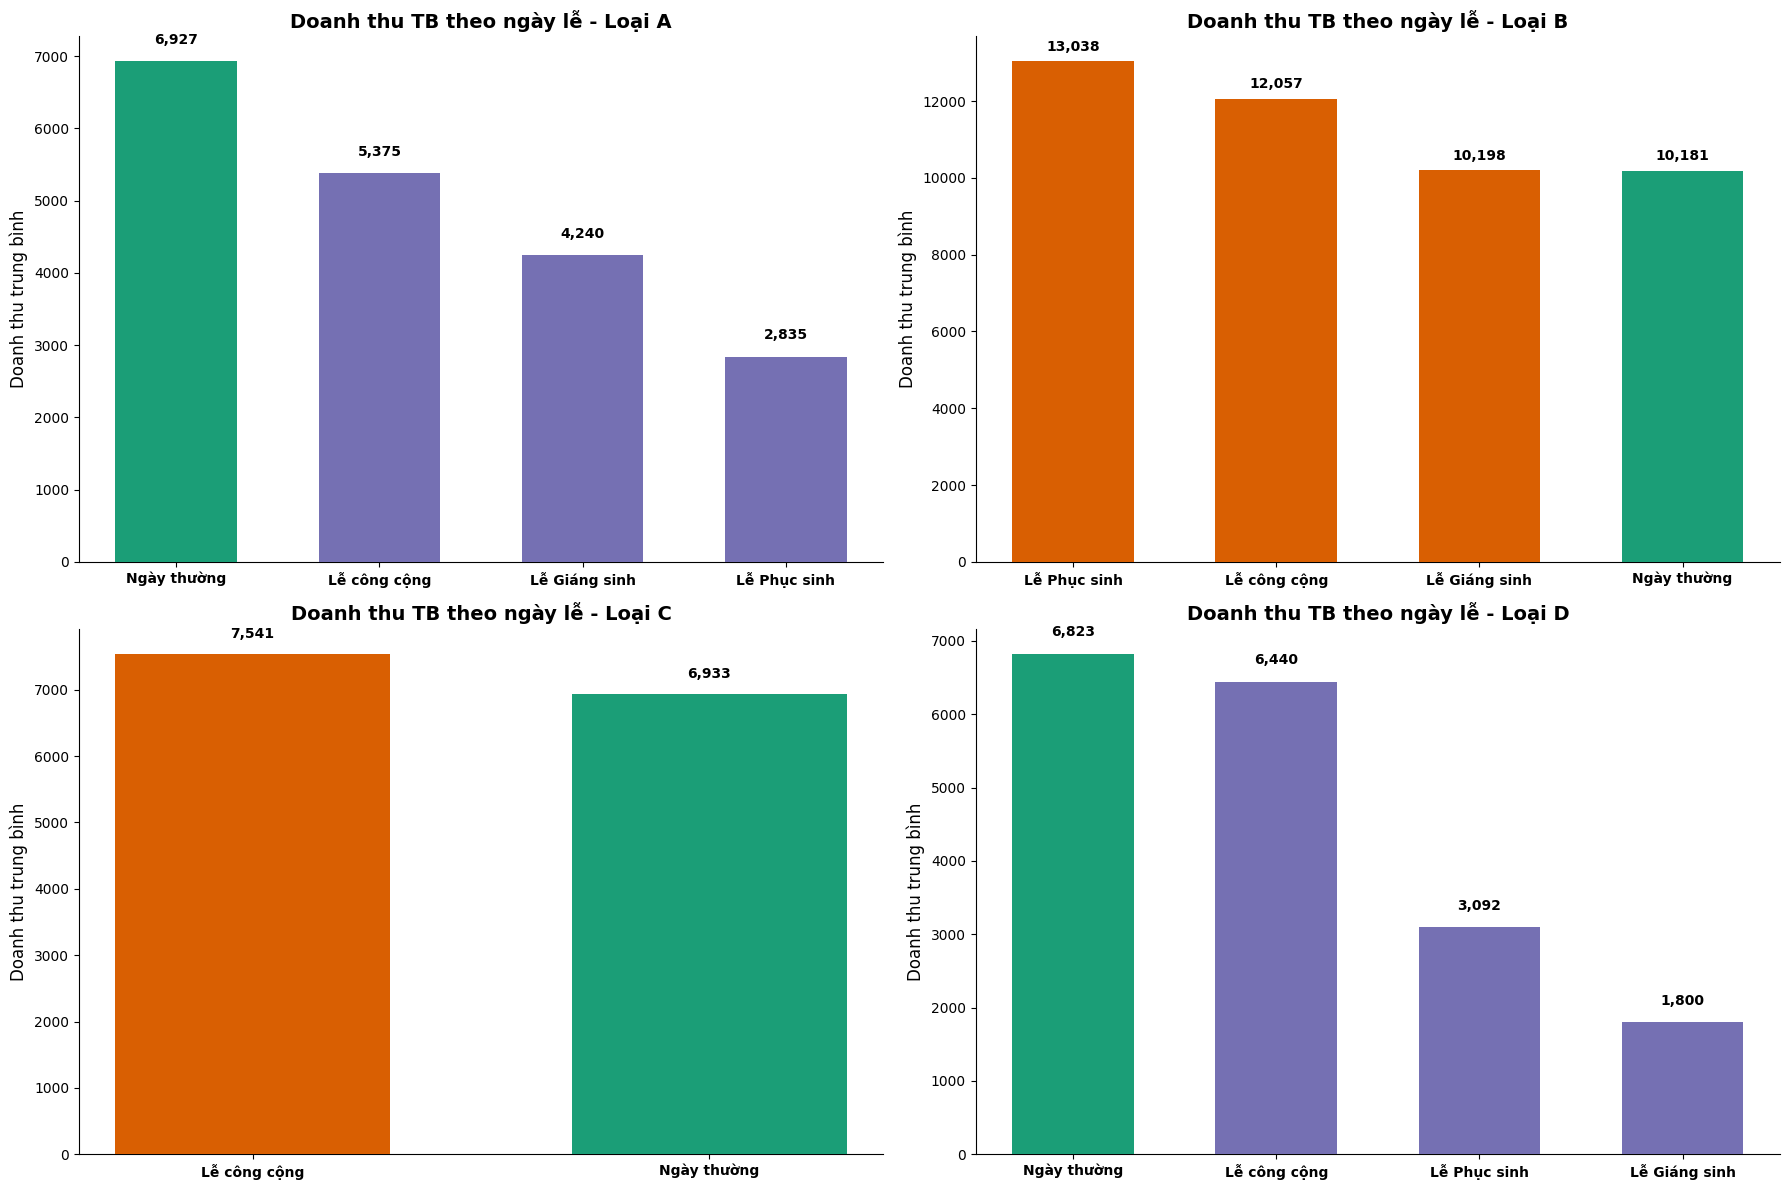

In [70]:
# Mapping nhãn cho dễ đọc
holiday_mapping = {
    '0': 'Ngày thường', 0: 'Ngày thường',
    'a': 'Lễ công cộng',
    'b': 'Lễ Phục sinh',
    'c': 'Lễ Giáng sinh'
}

# Khởi tạo figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

store_types = ['a', 'b', 'c', 'd']

for idx, store_type in enumerate(store_types):
    ax = axes[idx]
    
    # 1. Lọc dữ liệu (chỉ lấy sales > 0 để xem hiệu suất khi mở cửa)
    df_store_type = sales_positive[sales_positive['StoreType'] == store_type].copy()
    
    if df_store_type.empty:
        ax.set_visible(False)
        continue
    
    # 2. Tính toán & Mapping
    # Convert sang string để mapping không bị lỗi giữa 0 và '0'
    df_store_type['StateHoliday'] = df_store_type['StateHoliday'].astype(str)
    
    # Groupby
    avg_sales = df_store_type.groupby('StateHoliday', observed=False)['Sales'].mean()
    
    # Đổi tên index theo mapping
    avg_sales.index = avg_sales.index.map(lambda x: holiday_mapping.get(x, x))
    
    # Sắp xếp giảm dần
    avg_sales = avg_sales.sort_values(ascending=False)
    
    # 3. Logic màu sắc Rossmann
    # Tìm giá trị của 'Ngày thường' để làm chuẩn so sánh
    try:
        normal_day_sales = avg_sales['Ngày thường']
    except KeyError:
        normal_day_sales = 0

    colors = []
    for label, value in avg_sales.items():
        if label == 'Ngày thường':
            colors.append(ROSSMANN_COLORS[0]) # Teal: Baseline
        elif value > normal_day_sales:
            colors.append(ROSSMANN_COLORS[1]) # Cam: High Performance (Lễ bán tốt hơn ngày thường)
        else:
            colors.append(ROSSMANN_COLORS[2]) # Tím: Low Performance/Neutral (Lễ bán kém hơn)

    # 4. Vẽ Barplot
    ax.bar(range(len(avg_sales)), avg_sales.values, 
           color=colors, width=0.6, zorder=3)
    
    # 5. Formatting
    ax.set_title(f'Doanh thu TB theo ngày lễ - Loại {store_type.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('') # Bỏ label trục X cho đỡ rối vì đã có text tick
    ax.set_ylabel('Doanh thu trung bình', fontsize=12)
    
    # Xử lý trục X
    ax.set_xticks(range(len(avg_sales)))
    ax.set_xticklabels(avg_sales.index, rotation=0, fontweight='bold')
    
    # Clean Chart (Bỏ Grid & Spines)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # 6. Data Labels
    for i, v in enumerate(avg_sales.values):
        ax.text(i, v + 200, f'{v:,.0f}', 
                ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [71]:
print(f'Số ngày cửa hàng c mở cửa vào dịp giáng sinh: {df_merged[(df_merged["Open"] > 0) & (df_merged["StateHoliday"]=="c") & (df_merged["StoreType"]=="c")].shape[0]}')
print(f'Số ngày cửa hàng c mở cửa vào dịp lễ phục sinh: {df_merged[(df_merged["Open"] > 0) & (df_merged["StateHoliday"]=="b") & (df_merged["StoreType"]=="c")].shape[0]}')


Số ngày cửa hàng c mở cửa vào dịp giáng sinh: 0
Số ngày cửa hàng c mở cửa vào dịp lễ phục sinh: 0


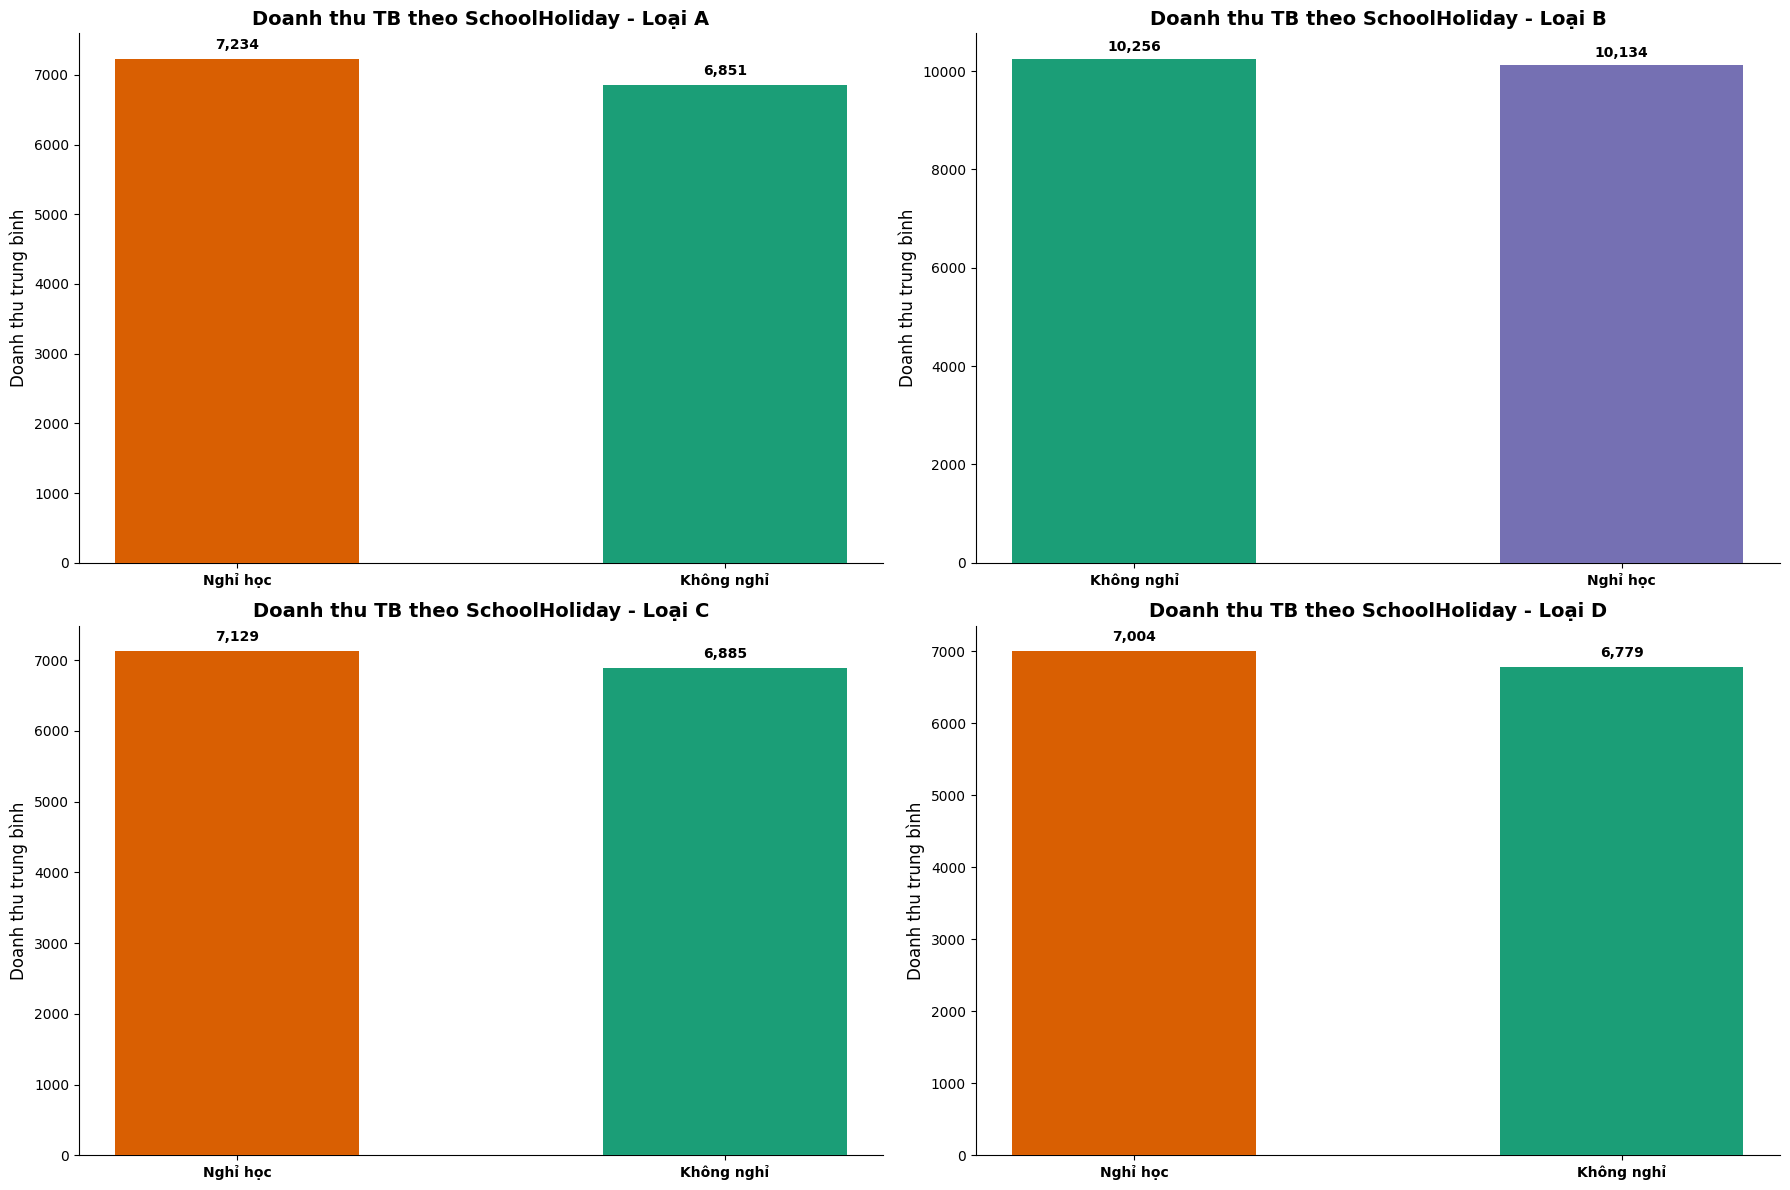

In [72]:
# Mapping nhãn
school_holiday_mapping = {0: 'Không nghỉ', 1: 'Nghỉ học'}

# Khởi tạo figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

store_types = ['a', 'b', 'c', 'd']

for idx, store_type in enumerate(store_types):
    ax = axes[idx]
    
    # 1. Lọc dữ liệu (Sales > 0)
    df_store_type = sales_positive[sales_positive['StoreType'] == store_type]
    
    if df_store_type.empty:
        ax.set_visible(False)
        continue
    
    # 2. Tính toán
    avg_sales = df_store_type.groupby('SchoolHoliday')['Sales'].mean()
    
    # Sắp xếp giảm dần để cột cao nhất đứng trước
    avg_sales_sorted = avg_sales.sort_values(ascending=False)
    
    # 3. Logic màu sắc Rossmann
    # Lấy giá trị ngày thường để làm chuẩn so sánh
    try:
        normal_sales = avg_sales[0]
    except KeyError:
        normal_sales = 0
        
    colors = []
    for x in avg_sales_sorted.index:
        if x == 0: # Ngày thường
            colors.append(ROSSMANN_COLORS[0]) # Teal (Base)
        else: # Ngày nghỉ (x == 1)
            if avg_sales[1] > avg_sales[0]:
                colors.append(ROSSMANN_COLORS[1]) # Cam (Highlight - Tác động Tốt)
            else:
                colors.append(ROSSMANN_COLORS[2]) # Tím (Neutral - Tác động Xấu/Không đổi)

    # 4. Vẽ Barplot
    ax.bar(range(len(avg_sales_sorted)), avg_sales_sorted.values, 
           color=colors, width=0.5, zorder=3)
    
    # 5. Xử lý Nhãn trục X
    labels = [school_holiday_mapping.get(x, x) for x in avg_sales_sorted.index]
    ax.set_xticks(range(len(avg_sales_sorted)))
    ax.set_xticklabels(labels, rotation=0, fontweight='bold')
    
    # 6. Formatting
    ax.set_title(f'Doanh thu TB theo SchoolHoliday - Loại {store_type.upper()}', 
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Doanh thu trung bình', fontsize=12)
    
    # Clean Chart
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # 7. Data Labels
    for i, v in enumerate(avg_sales_sorted.values):
        ax.text(i, v + 100, f'{v:,.0f}', 
                ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

1. Doanh thu trung bình tại cửa hàng `StoreType b` luôn vượt trội so với các loại cửa hàng khác dù là dịp lễ hay không phải dịp lễ

2. Cửa hàng `StoreType b` có doanh thu trung bình cao nhất vào ngày lễ phục sinh, trong khi các cửa hàng khác thu được doanh thu trung bình cao nhất vào các ngày lễ thường và không phải ngày lễ

3. Cửa hàng `StoreType c` không mở cửa vào ngày lễ giáng sinh và lễ phục sinh

4. Các ngày nghỉ lễ ở trường (`SchoolHoliday`) có vẻ như không có quá nhiều tác động đến doanh thu của các loại cửa hàng

#### Xem xét mối quan hệ giữa doanh thu và `assortment` theo thời gian và theo loại cửa hàng


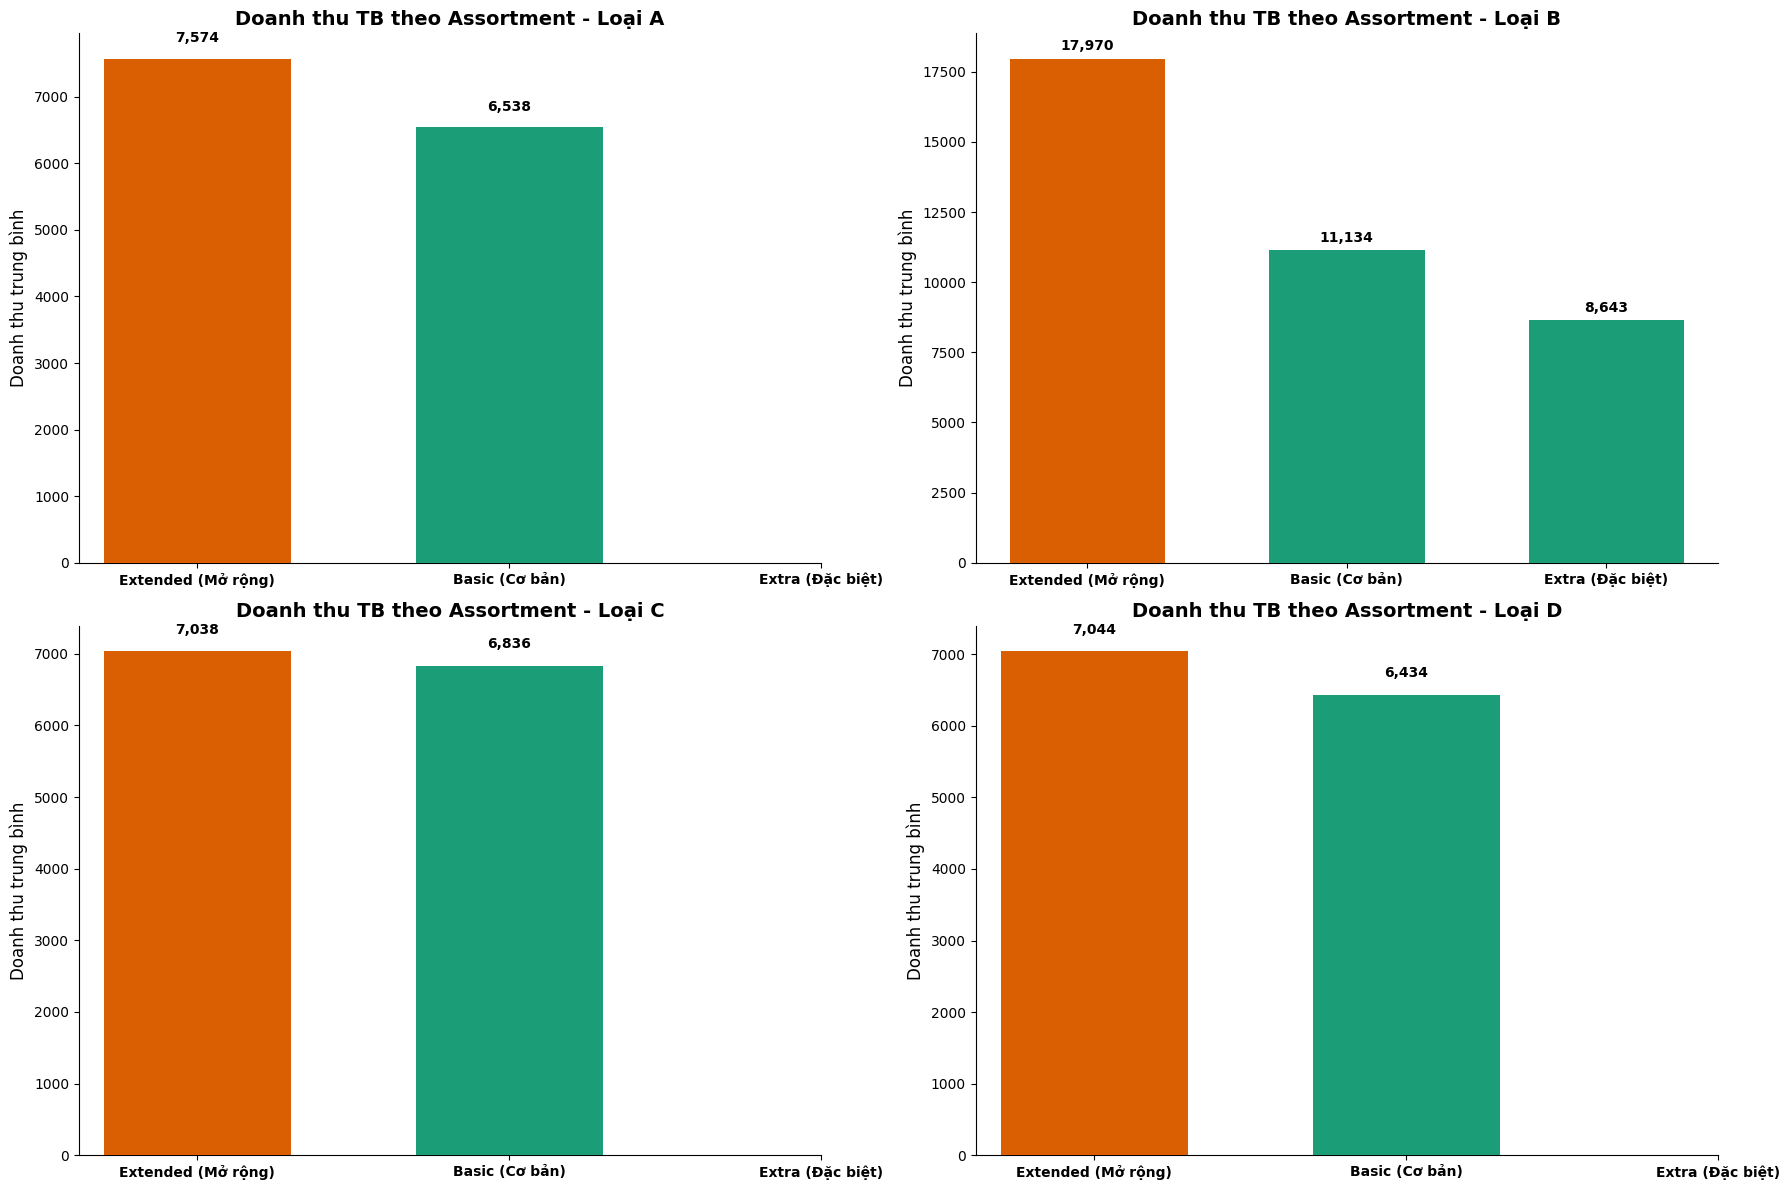

In [73]:
# Mapping nhãn cho dễ hiểu
assortment_mapping = {
    'a': 'Basic (Cơ bản)', 
    'b': 'Extra (Đặc biệt)', 
    'c': 'Extended (Mở rộng)'
}

# Khởi tạo figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

store_types = ['a', 'b', 'c', 'd']

for idx, store_type in enumerate(store_types):
    ax = axes[idx]
    
    # 1. Lọc dữ liệu (Sales > 0)
    df_store_type = sales_positive[sales_positive['StoreType'] == store_type]
    
    if df_store_type.empty:
        ax.set_visible(False)
        continue
    
    # 2. Tính toán doanh thu trung bình
    avg_sales = df_store_type.groupby('Assortment', observed=False)['Sales'].mean().sort_values(ascending=False)
    
    # 3. Logic màu sắc Rossmann: Highlight "Best Strategy"
    max_val = avg_sales.max()
    colors = []
    for v in avg_sales.values:
        if v == max_val:
            colors.append(ROSSMANN_COLORS[1]) # Cam: Chiến lược hiệu quả nhất
        else:
            colors.append(ROSSMANN_COLORS[0]) # Teal: Các chiến lược khác
            
    # 4. Vẽ Barplot
    ax.bar(range(len(avg_sales)), avg_sales.values, 
           color=colors, width=0.6, zorder=3)
    
    # 5. Xử lý Nhãn trục X (Mapping sang tên đầy đủ)
    labels = [assortment_mapping.get(x, x) for x in avg_sales.index]
    ax.set_xticks(range(len(avg_sales)))
    ax.set_xticklabels(labels, rotation=0, fontweight='bold')
    
    # 6. Formatting
    ax.set_title(f'Doanh thu TB theo Assortment - Loại {store_type.upper()}', 
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Doanh thu trung bình', fontsize=12)
    
    # Clean Chart (Bỏ Grid & Spines)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # 7. Data Labels
    for i, v in enumerate(avg_sales.values):
        ax.text(i, v + 200, f'{v:,.0f}', 
                ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Khó để đi sâu vào phân tích về `assortment` khi dữ liệu rất mất cân bằng, theo quan sát biểu đồ trên thì chỉ có các cửa hàng `StoreType b` mới có `Assortment b` và doanh thu trung bình của `Assortment c` luôn cao hơn  `Assortment a`

#### Correlation Matrix

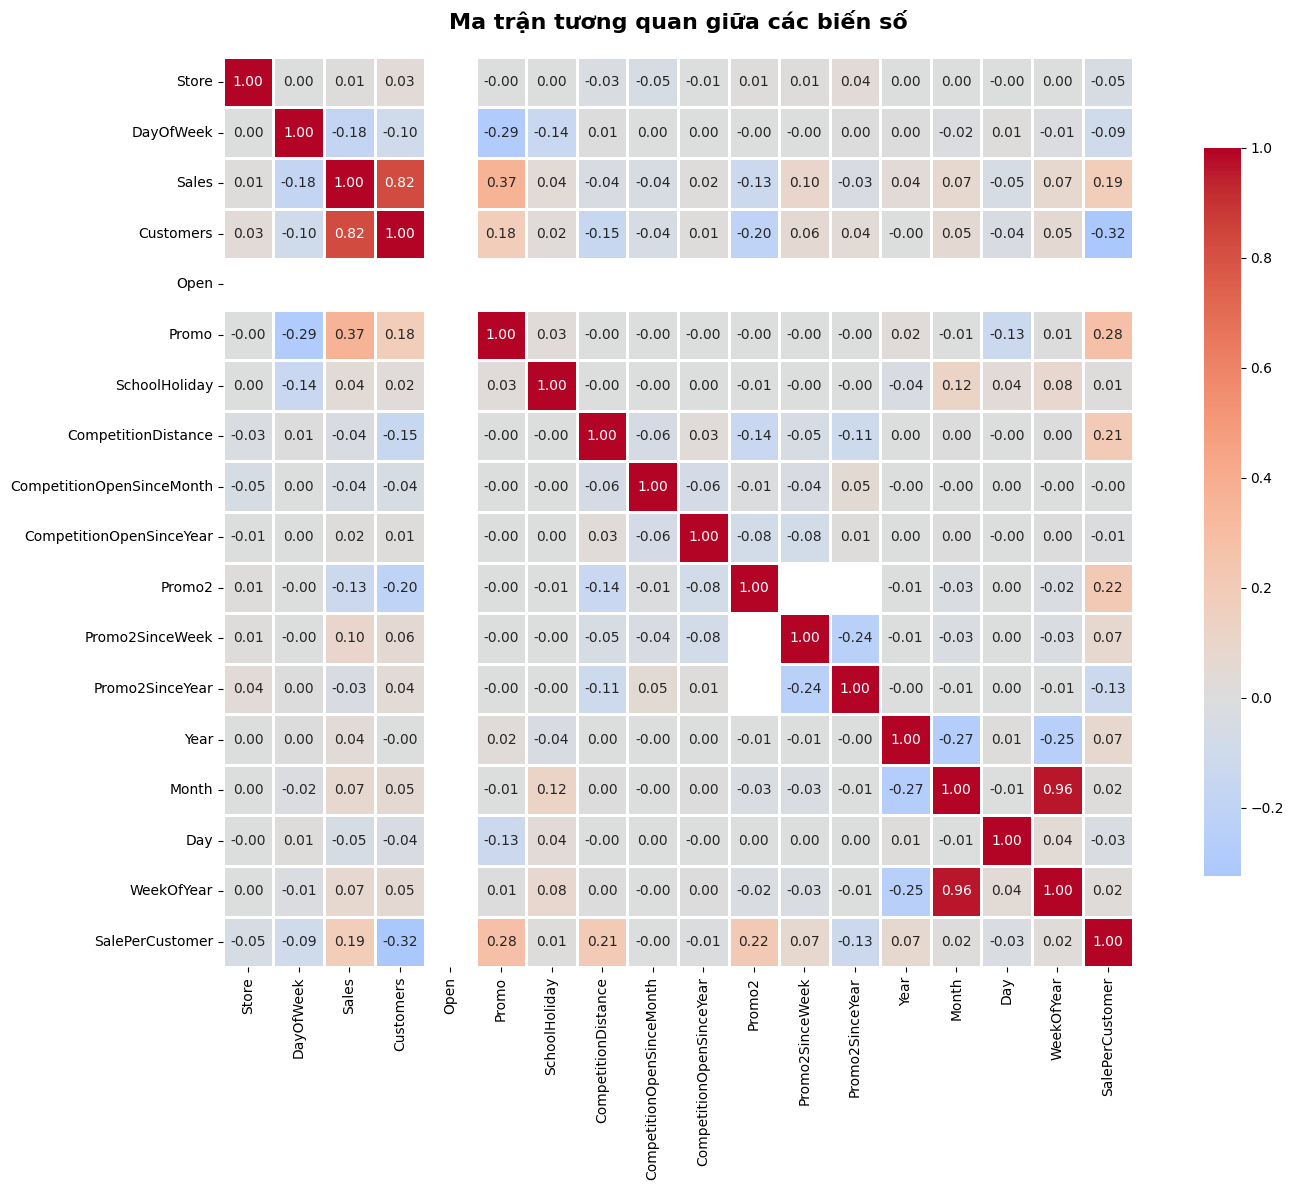

In [74]:

numerical_features = df_merged.select_dtypes(include=[np.number]).columns.tolist()

# Tính ma trận tương quan
correlation_matrix = df_merged[numerical_features].corr()

# Vẽ heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến số', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Các biến `Dayofweek`, `Sales`, `Customers`, `Open`, `Promo` có tương quan với nhau khá rõ rệt, trong khi các biến còn lại hầu như không có tương quan với nhau.

#### Kết luận phân tích đa biến


<b> 1. Về thời gian, mùa vụ </b>
- Các cửa hàng thường tăng doanh thu rất mạnh vào cuối năm khoảng tháng 11 và 12, đối với các ngày trong tuần các cửa hàng loại a,c,d đều sụt giảm doanh thu trầm trọng vào ngày chủ nhật còn cửa hàng `StoreType b` lại tăng doanh thu vào ngày chủ nhật nhưng lại sụt giảm sâu vào ngày thứ 7

- Cửa hàng `StoreType b` có doanh thu trung bình cao nhất vào ngày lễ phục sinh, trong khi các cửa hàng khác thu được doanh thu trung bình cao nhất vào các ngày lễ thường và không phải ngày lễ

- Cửa hàng `StoreType c` không có doanh thu vào dịp lễ phục sinh

- Các ngày nghỉ lễ ở trường (`SchoolHoliday`) có vẻ như không có quá nhiều tác động đến doanh thu của các loại cửa hàng

<b> 2. Về doanh thu </b>
- Cửa hàng `StoreType b` đúng là có số lượng khách trung bình ngày doanh thu trung bình ngày nhiều nhất nhưng số lượng store lại ít nhất nên tổng doanh thu sẽ ít nhất nhưng performance rất tốt, đây là loại cửa hàng hiếm vì số lượng store ít và khách hàng vào mua đông nhưng mua với giá trị ít

- Cửa hàng `StoreType d` ngược lại có doanh thu và số khách trung bình ngày ít nhất nhưng `SalePerCustomer` lại vượt trội nhất, đây là loại cửa hàng có lẽ là bán hàng hóa có giá trị cao nhất nên mới ít khách và `SalePerCustomer` cao

- Doanh thu trung bình tại cửa hàng `StoreType b` luôn vượt trội so với các loại cửa hàng khác dù là dịp lễ hay không phải dịp lễ

<b> 3. Ảnh hưởng của promotion </b>
- Loại cửa hàng `StoreType b` luôn có doanh thu cao nhất khi áp dụng cả 2 loại promotion `promo` và `promo2` 

- Xu hướng biến động doanh thu ở cả 2 biểu đồ của 2 biến `promo` và `promo2` tương đối giống nhau, tuy nhiên ở biểu đồ `promo` thì việc áp dụng mang lại doanh thu cao hơn rõ rệt so với không áp dụng, trong khi ở biểu đồ 
`promo2` thì doanh thu khi áp dụng `promo2` lại thấp hơn so với không áp dụng. Điều này cho thấy các biến promotion thật sự cần được phân tích sâu hơn để hiểu được nguyên nhân đằng sau.

<b> 4. Về đối thủ </b>
- Thâm niên đối thủ thể hiện ảnh hưởng rõ rệt nhất đến cửa hàng loại b, cần khám phá sâu hơn câu chuyện đằng sau


### <b>Kết luận cuối cùng cho phần EDA</b>


<b>Khám phá dữ liệu cho thấy rất nhiều các insight thú vị, trong đó có thể trích ra được 1 số insight hay nhất và còn nhiều thắc mắc nhất sẽ được khai thác trong phần tiếp theo:</b>
1. Doanh thu trung bình tại cửa hàng `StoreType b` luôn vượt trội so với doanh thu trung bình của các loại cửa hàng còn lại bất kể yếu tố thời gian, hay dịp lễ nhưng lại có doanh thu trung bình mỗi khách hàng là thấp nhất do cửa hàng rất đông khách nhưng mỗi khách hàng chỉ mua với giá trị nhỏ.

2. Doanh thu trung bình mỗi khách hàng của cửa hàng `StoreType d` là cao nhất nhưng doanh thu trung bình ngày và số khách hàng trung bình theo ngày lại thấp nhất cho thấy đây là cửa hàng tập trung vào việc bán các dòng sản phẩm cao cấp với giá cả mặt hàng cao hơn các loại cửa hàng khác.

3. Doanh thu trung bình ghi nhận trong năm 2015 tính đến tháng 7 theo tập dataset này cao hơn so với doanh thu trung bình các năm trước dù chưa trải qua sự bùng nổ doanh thu vào cuối năm, cho thấy rõ nét về hiệu quả trong tăng trưởng kinh doanh của Rossmann store.

4. Yếu tố `promotion` dài hạn và ngắn hạn đều ảnh hưởng rõ rệt đến doanh số của tất cả các loại cửa hàng nhưng cần làm rõ hơn ở mửc độ ảnh hưởng và các vấn đề liên quan sẽ được tìm hiểu trong phần phân tích sâu tiếp theo.

5. Yếu tố về `thời gian mùa vụ` ảnh hưởng đến doanh thu đã được thể hiện rõ, hầu như các cửa hàng đều tăng doanh thu mạnh vào tháng cuối năm, hay vào các ngày nghỉ lễ một số loại cửa hàng tăng còn 1 số loại thì không, đây cũng là 1 vấn đề sẽ được đào sâu hơn trong phần phân tích sâu tiếp theo.

6. Yếu tố `đối thủ cạnh tranh` cũng đưa ra được 1 insight thú vị , thâm niên của cửa hàng đối thủ ảnh hưởng lớn đến loại cửa hàng, nhất là cửa hàng loại b. Đây là một yếu tố cần đào sâu làm rõ hơn để trả lời cho các câu hỏi tại sao và sự thật đằng sau các insight kể trên cũng như khám phá ra được các câu chuyện mới liên quan đến đối thủ cạnh tranh, yếu tố về đối thủ cạnh tranh cũng sẽ được phân tích sâu hơn trong phần tiếp theo.
